# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of four synthetic data generation models:
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


## Data Loading and Setup


In [1]:
import pandas as pd

file_path = r'C:\Users\Gopi.Battineni\OneDrive - University of Limerick\Desktop\FORGE\Synthetic-data_Audit-main\Synthetic_Data_Audit\Datasets\e-shop.csv'

data = pd.read_csv(file_path, sep=';')

data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

n_samples = min(5000, len(data))
data = data.sample(n=n_samples, random_state=42).reset_index(drop=True)

display(data.head())
data.info()


,year,month,day,order,country,session_id,page_1_main_category,page_2_clothing_model,colour,location,model_photography,price,price_2,page
0,2008,4,22,4,29,5279,4,P48,9,4,2,33,2,3
1,2008,5,19,1,29,10059,1,A15,14,5,2,33,2,1
2,2008,4,11,10,29,2919,4,P23,6,2,2,28,2,2
3,2008,4,28,3,27,6304,2,B24,11,2,1,57,1,2
4,2008,5,26,1,29,11266,1,A2,3,1,1,43,2,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   year                   5000 non-null   int64 
 1   month                  5000 non-null   int64 
 2   day                    5000 non-null   int64 
 3   order                  5000 non-null   int64 
 4   country                5000 non-null   int64 
 5   session_id             5000 non-null   int64 
 6   page_1_main_category   5000 non-null   int64 
 7   page_2_clothing_model  5000 non-null   object
 8   colour                 5000 non-null   int64 
 9   location               5000 non-null   int64 
 10  model_photography      5000 non-null   int64 
 11  price                  5000 non-null   int64 
 12  price_2                5000 non-null   int64 
 13  page                   5000 non-null   int64 
dtypes: int64(13), object(1)
memory usage: 547.0+ KB


# Generating synthetic data

In [2]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import sdv
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

data.columns = data.columns.str.strip().str.lower()
target_col = 'price'

data[target_col] = pd.to_numeric(data[target_col], errors='coerce')
if 'session_id' in data.columns:
    data = data.drop(columns=['session_id'])
data = data.dropna(subset=[target_col]).reset_index(drop=True)

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)
metadata.update_column(column_name=target_col, sdtype='numerical')
for col in data.columns:
    if data[col].dtype == 'object':
        metadata.update_column(column_name=col, sdtype='categorical')

n_samples = len(data)

models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata, epochs=50, verbose=False),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata, epochs=50, verbose=False),
    "TVAE": TVAESynthesizer(metadata=metadata, epochs=50, verbose=False),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata)
}

synthetic_datasets = {}
diagnostic_reports = {}
quality_reports = {}
summary = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(data)

    synthetic_data = model.sample(n_samples)

    synthetic_data = synthetic_data[data.columns]

    if target_col in synthetic_data.columns:
        synthetic_data[target_col] = pd.to_numeric(synthetic_data[target_col], errors='coerce')
        synthetic_data = synthetic_data.dropna(subset=[target_col])

    synthetic_datasets[name] = synthetic_data

    diagnostic_report = run_diagnostic(real_data=data, synthetic_data=synthetic_data, metadata=metadata)
    quality_report = evaluate_quality(real_data=data, synthetic_data=synthetic_data, metadata=metadata)

    diagnostic_reports[name] = diagnostic_report
    quality_reports[name] = quality_report

    summary.append((name, diagnostic_report.get_score(), quality_report.get_score()))

summary_df = pd.DataFrame(summary, columns=["Model", "Diagnostic Score", "Quality Score"])
summary_df = summary_df.sort_values("Quality Score", ascending=False).reset_index(drop=True)

print("\nModel comparison:")
display(summary_df)

best_model_name = summary_df.loc[0, "Model"]
best_synthetic_data = synthetic_datasets[best_model_name]
print(f"\nBest model by quality score: {best_model_name}")
display(best_synthetic_data.head())


Training CTGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 13/13 [00:00<00:00, 641.79it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 271.51it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 13/13 [00:00<00:00, 316.59it/s]|
Column Shapes Score: 90.79%

(2/2) Evaluating Column Pair Trends: |██████████| 78/78 [00:00<00:00, 201.10it/s]|
Column Pair Trends Score: 43.69%

Overall Score (Average): 67.24%


Training CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 13/13 [00:00<00:00, 1099.42it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 166.72it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 13/13 [00:00<00:00, 260.35it/s]|
Column Shapes Score: 90.64%

(2/2) E

,Model,Diagnostic Score,Quality Score
0,GaussianCopula,1.0,0.704185
1,CopulaGAN,1.0,0.682000
2,CTGAN,1.0,0.672431
3,TVAE,1.0,0.608031



Best model by quality score: GaussianCopula


,year,month,day,order,country,page_1_main_category,page_2_clothing_model,colour,location,model_photography,price,price_2,page
0,2008,5,5,6,24,2,A4,1,1,2,68,1,1
1,2008,7,18,5,20,4,A33,13,3,1,42,1,2
2,2008,8,28,5,34,4,A10,8,1,1,36,2,2
3,2008,6,28,2,30,1,C34,1,1,1,53,1,1
4,2008,4,21,2,20,1,C12,14,6,1,34,1,1


# 1. Univariate Analysis

### 1.1.  Kolmogorov-Smirnov (K-S) test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 474.69it/s]|
Column Shapes Score: 90.88%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 278.12it/s]|
Column Pair Trends Score: 46.43%

Overall Score (Average): 68.65%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 591.39it/s]|
Column Shapes Score: 90.86%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 319.12it/s]|
Column Pair Trends Score: 47.48%

Overall Score (Average): 69.17%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 424.05it/s]|
Column Shapes Score: 75.61%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 293.74it/s]|
Column Pair Trends Score: 45.56%

Overall Score (Average): 60.59%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 470.01it/s]|
Column Shapes Score: 91.98%

(2/2) Evaluating Column Pair T

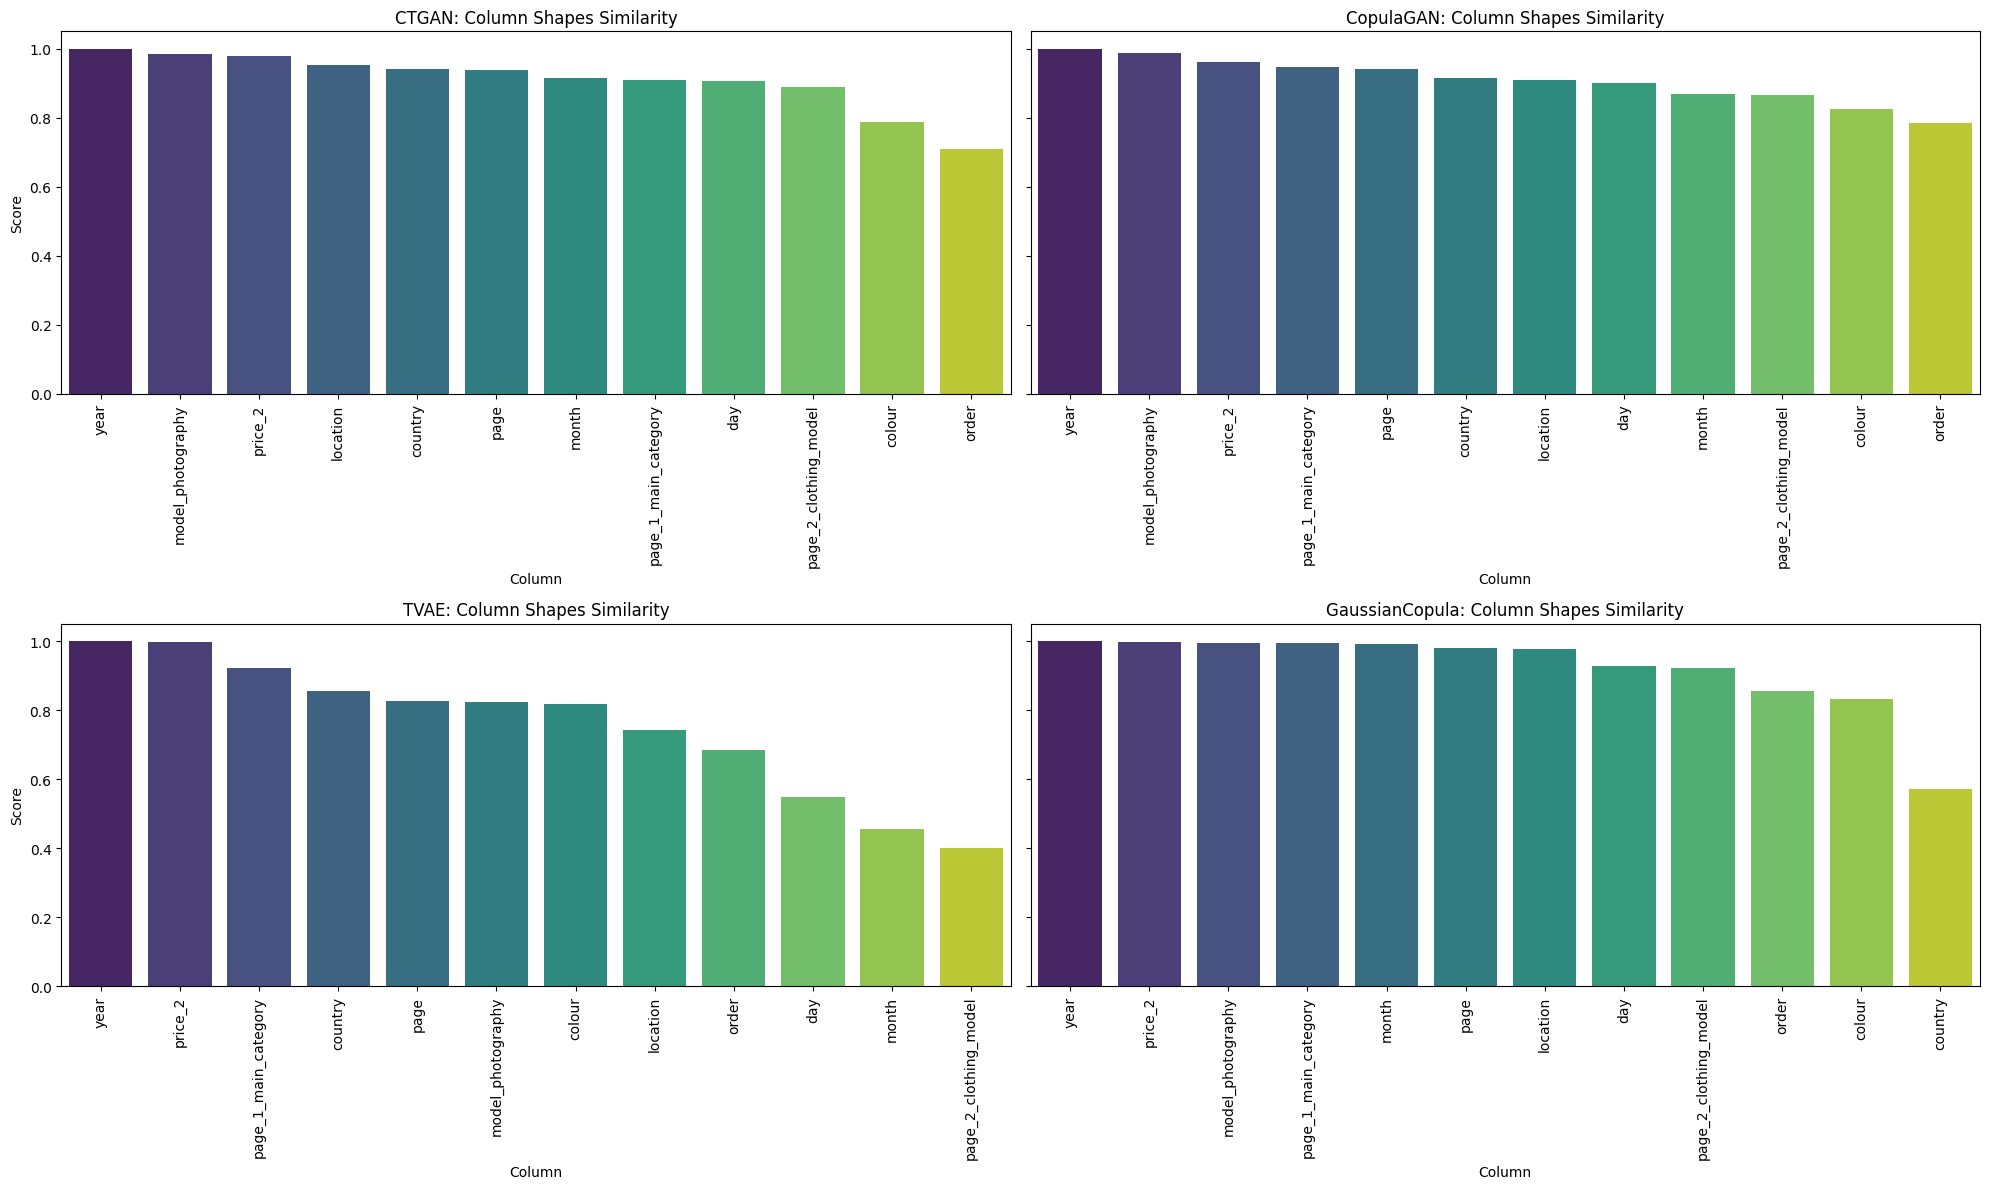

,Column,Metric,Score,Model
0,year,TVComplement,1.0000,CTGAN
1,model_photography,TVComplement,0.9830,CTGAN
2,price_2,TVComplement,0.9784,CTGAN
3,location,TVComplement,0.9510,CTGAN
4,country,KSComplement,0.9416,CTGAN
5,page,TVComplement,0.9368,CTGAN
6,month,TVComplement,0.9150,CTGAN
7,page_1_main_category,TVComplement,0.9086,CTGAN
8,day,KSComplement,0.9060,CTGAN
9,page_2_clothing_model,TVComplement,0.8884,CTGAN


In [3]:
import warnings
warnings.filterwarnings("ignore")

from sdv.evaluation.single_table import QualityReport
from sdv.metadata import SingleTableMetadata
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "price"

real_eval = data.drop(columns=[target_col], errors="ignore").copy()

metadata_eval = SingleTableMetadata()
metadata_eval.detect_from_dataframe(real_eval)

column_shape_details = {}

for model_name in model_order:
    synth_eval = synthetic_datasets[model_name].drop(columns=[target_col], errors="ignore").copy()
    synth_eval = synth_eval[real_eval.columns]

    qr = QualityReport()
    qr.generate(
        real_data=real_eval,
        synthetic_data=synth_eval,
        metadata=metadata_eval.to_dict()
    )
    details = qr.get_details("Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    sns.barplot(
        x="Column", y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)
display(combined_details.head(20))

### 1.2. Jensen–Shannon divergence

In [4]:
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    real = pd.to_numeric(real, errors="coerce").dropna().to_numpy()
    synth = pd.to_numeric(synth, errors="coerce").dropna().to_numpy()

    if len(real) == 0 or len(synth) == 0:
        return np.array([0.5, 0.5]), np.array([0.5, 0.5])

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)

    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame, synth_df: pd.DataFrame, bins=30, normalize=True) -> pd.DataFrame:
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        if num_cols:
            scaler = MinMaxScaler()
            real[num_cols] = scaler.fit_transform(real[num_cols])
            synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        js_div = jensenshannon(p, q, base=2) ** 2
        results.append({"Feature": col, "JS_Divergence": float(js_div)})

    return pd.DataFrame(results).sort_values("JS_Divergence", ascending=False).reset_index(drop=True)

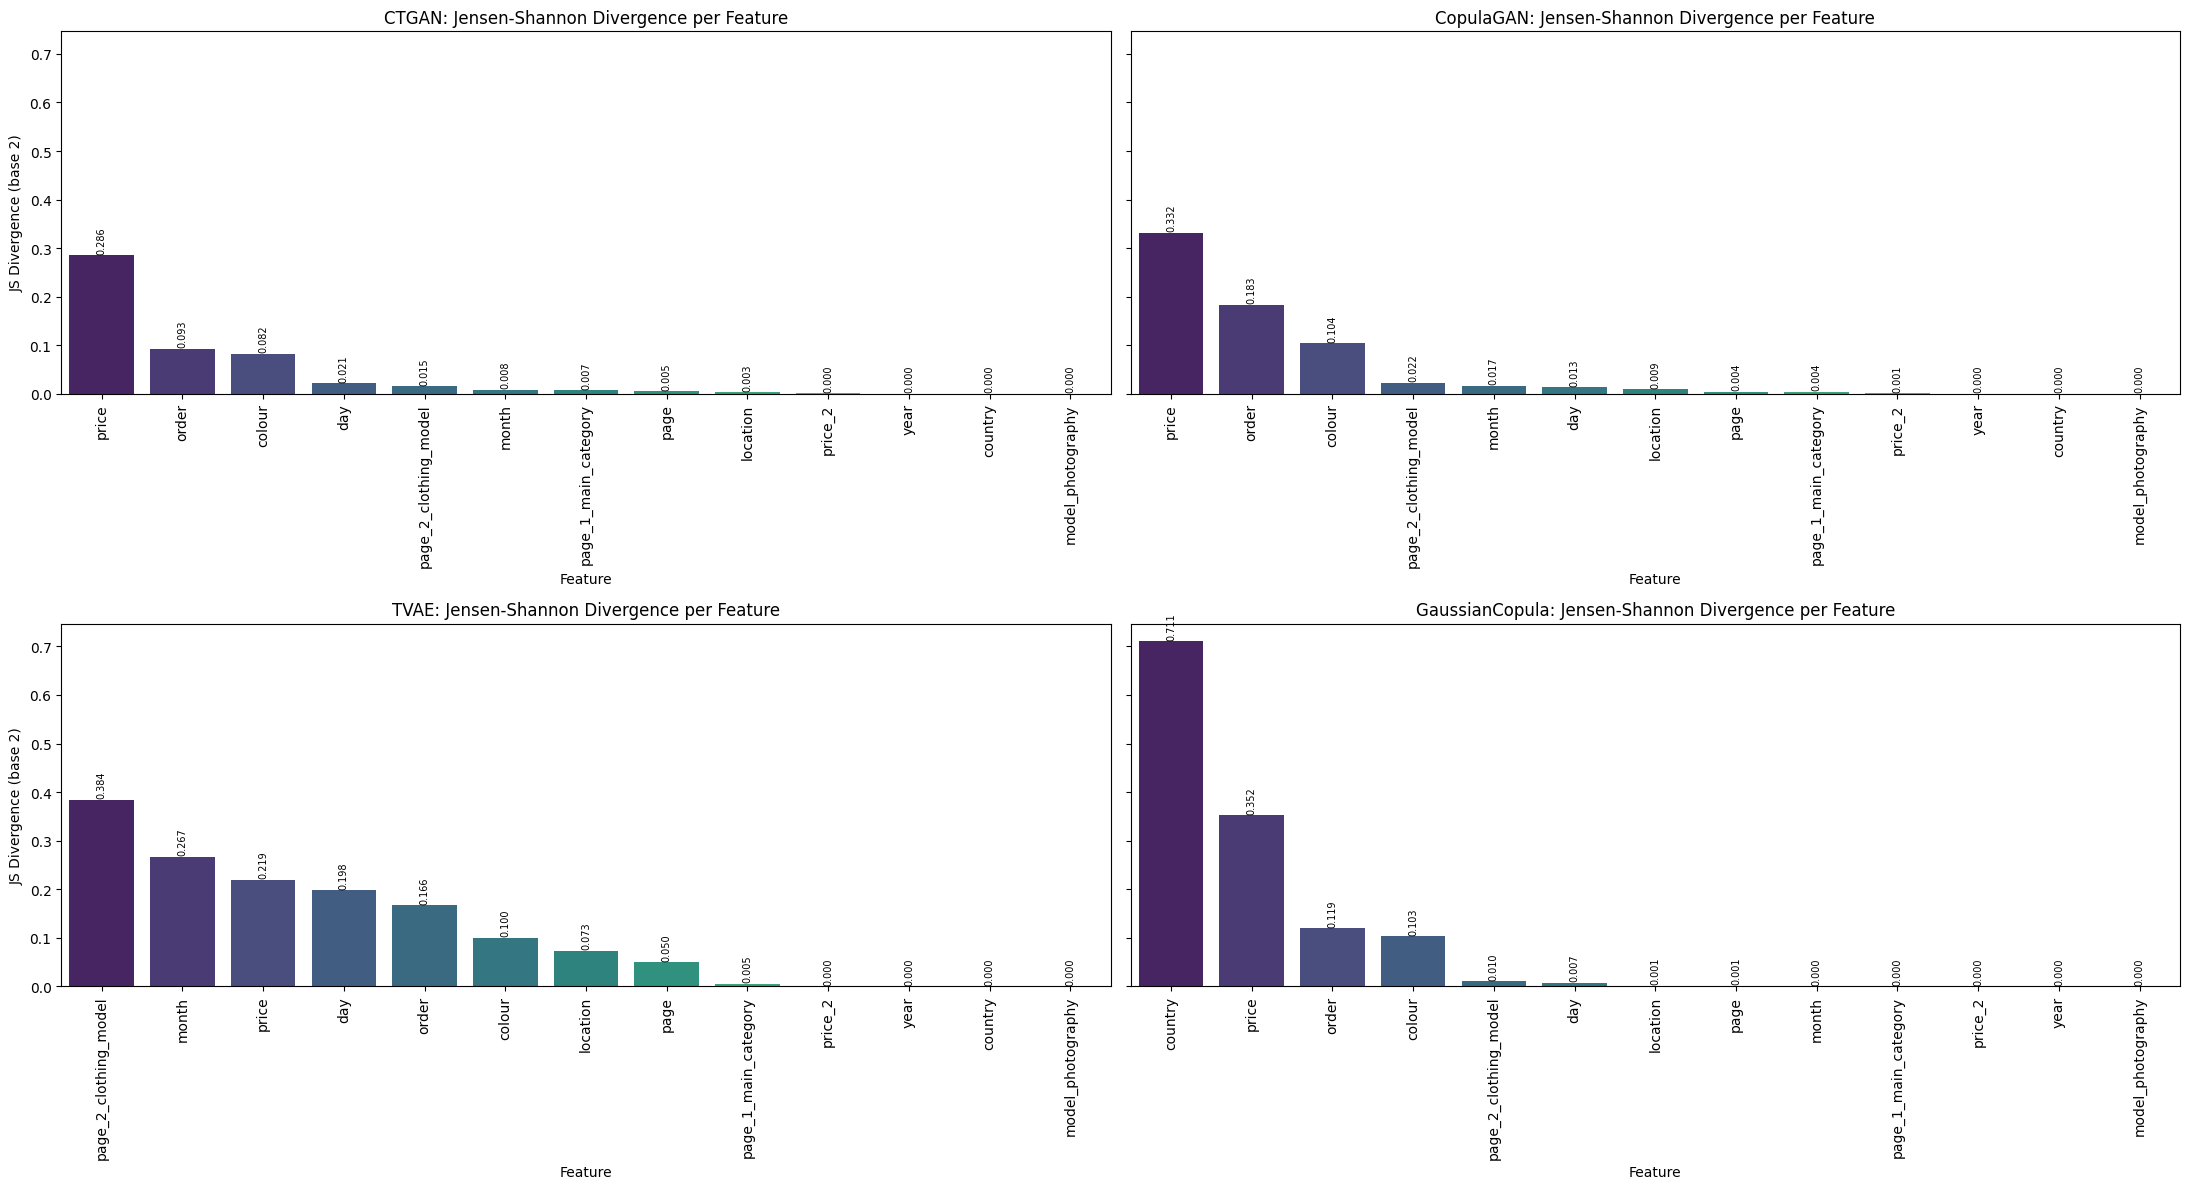

,Feature,JS_Divergence,Model
0,price,0.285609,CTGAN
1,order,0.092683,CTGAN
2,colour,0.082385,CTGAN
3,day,0.020866,CTGAN
4,page_2_clothing_model,0.014990,CTGAN
5,month,0.007803,CTGAN
6,page_1_main_category,0.007062,CTGAN
7,page,0.004619,CTGAN
8,location,0.002811,CTGAN
9,price_2,0.000337,CTGAN


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "traffic_volume"

js_results_by_model = {}

for model_name in model_order:
    real_eval = data.drop(columns=[target_col], errors="ignore").copy()
    synth_eval = synthetic_datasets[model_name].drop(columns=[target_col], errors="ignore").copy()

    common_cols = real_eval.columns.intersection(synth_eval.columns)
    real_eval = real_eval[common_cols]
    synth_eval = synth_eval[common_cols]

    js_df = compute_js_divergence(
        real_eval,
        synth_eval,
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)

    js_results_by_model[model_name] = js_df

fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]

    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df,
        palette="viridis",
        ax=ax
    )

    for bar in bars.patches:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.003,
            f"{yval:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    ax.set_title(f"{model_name}: Jensen-Shannon Divergence per Feature")
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence (base 2)")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)
display(all_js.head(20))

### 1.3 Wasserstein Distance



CTGAN - Wasserstein Distance:
year: 0.0000
month: 0.0331
day: 0.0332
order: 0.0254
country: 0.0321
page_1_main_category: 0.0427
colour: 0.0705
location: 0.0152
model_photography: 0.0170
price: 0.0306
price_2: 0.0216
page: 0.0340

CopulaGAN - Wasserstein Distance:
year: 0.0000
month: 0.0748
day: 0.0549
order: 0.0148
country: 0.0344
page_1_main_category: 0.0335
colour: 0.0858
location: 0.0226
model_photography: 0.0122
price: 0.0402
price_2: 0.0384
page: 0.0181

TVAE - Wasserstein Distance:
year: 0.0000
month: 0.2927
day: 0.2306
order: 0.0310
country: 0.0643
page_1_main_category: 0.0255
colour: 0.0972
location: 0.1200
model_photography: 0.1766
price: 0.0598
price_2: 0.0018
page: 0.0956

GaussianCopula - Wasserstein Distance:
year: 0.0000
month: 0.0028
day: 0.0459
order: 0.0094
country: 0.0996
page_1_main_category: 0.0024
colour: 0.0556
location: 0.0064
model_photography: 0.0062
price: 0.0219
price_2: 0.0036
page: 0.0115

Model summary (lower is better):


,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,GaussianCopula,0.022097,0.007898,0.099591
1,CTGAN,0.029616,0.031326,0.070523
2,CopulaGAN,0.035796,0.033919,0.085785
3,TVAE,0.099596,0.079972,0.292650


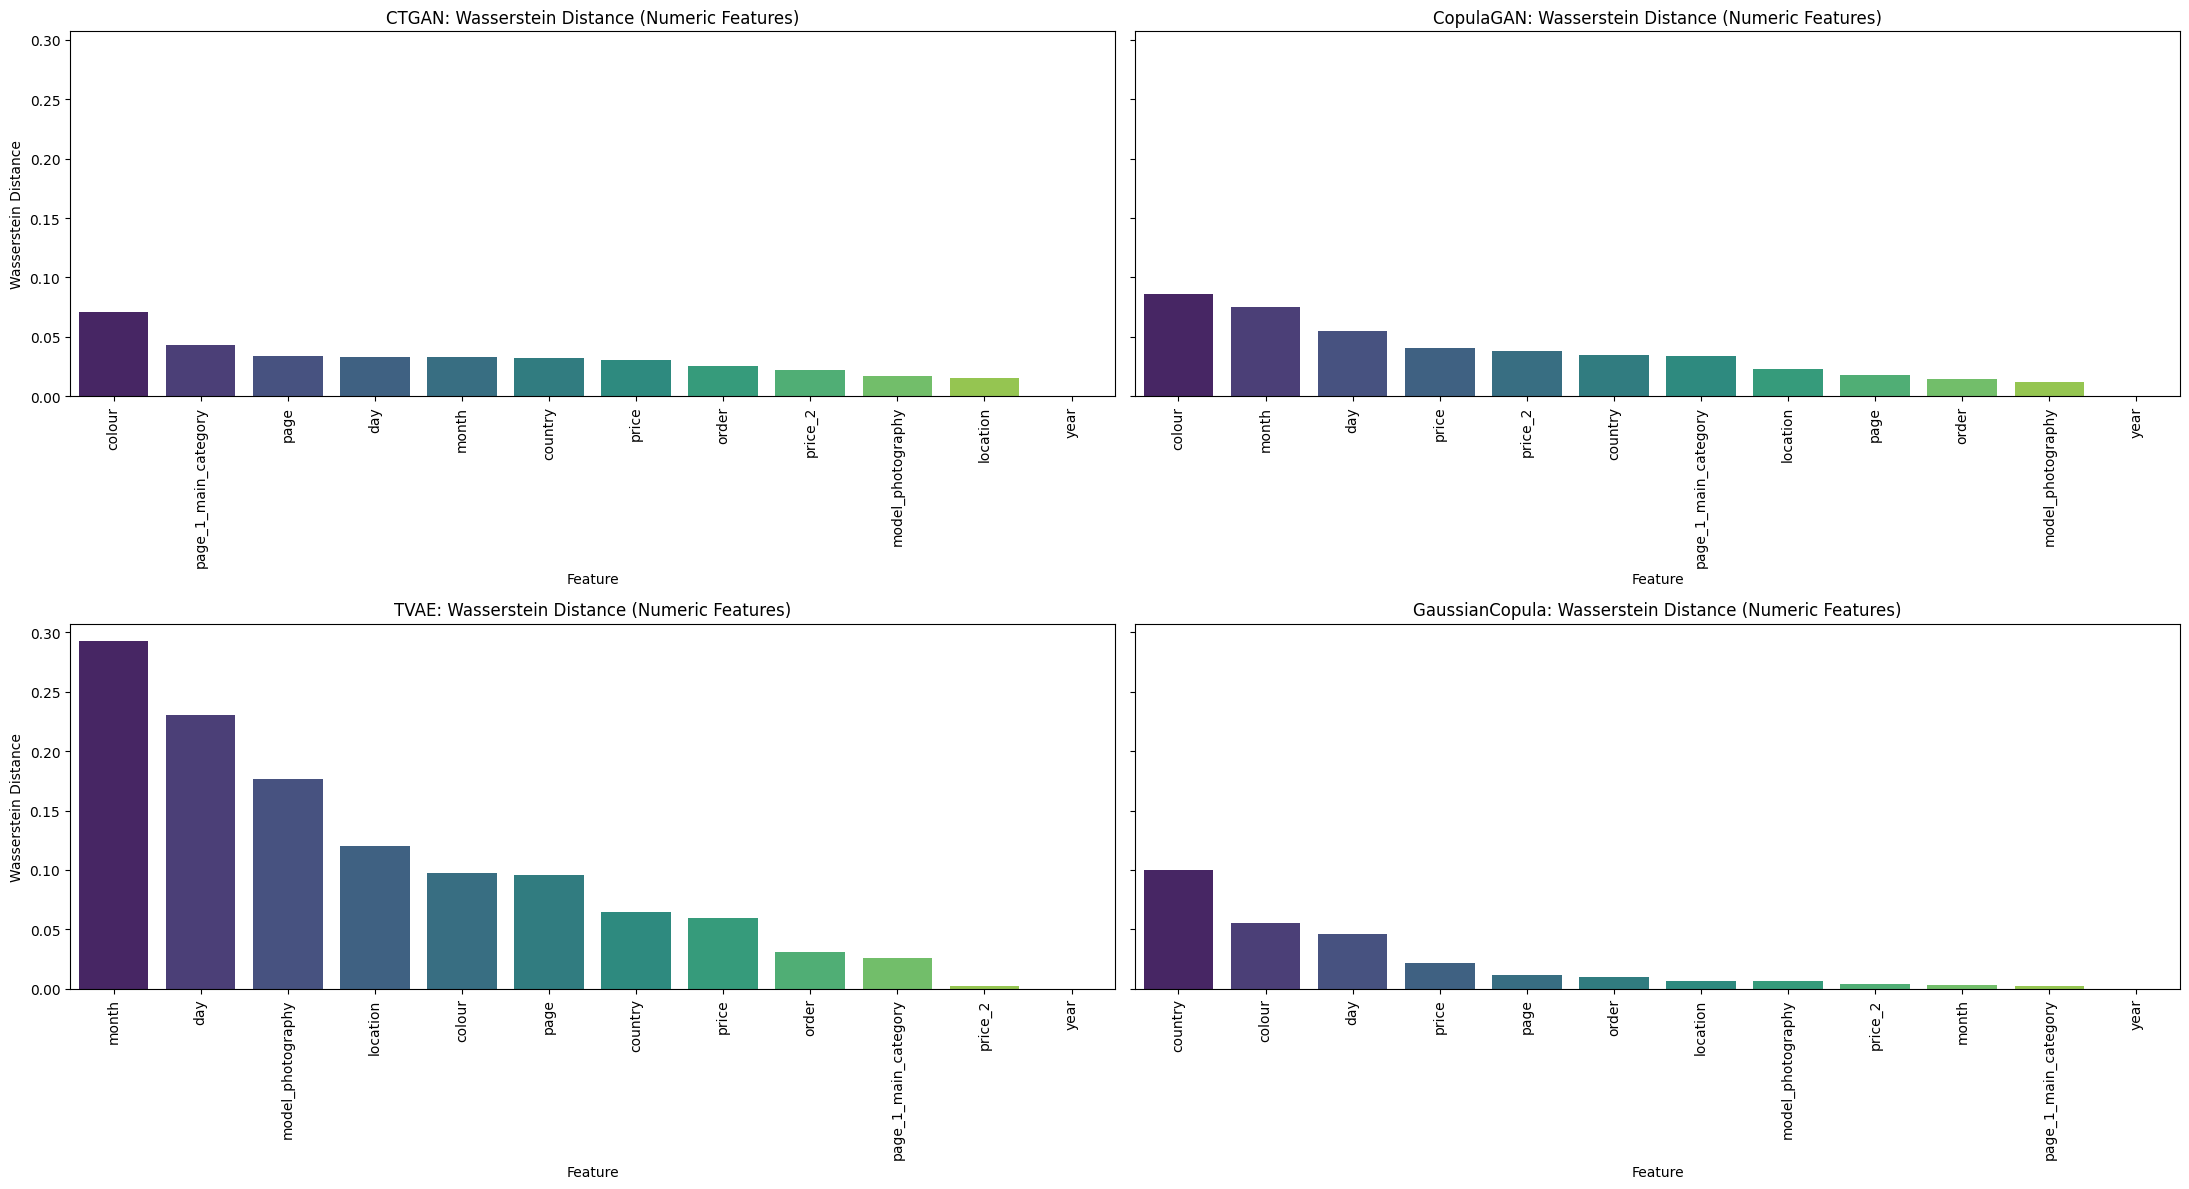

In [6]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "traffic_volume"

# Use numeric features only (Wasserstein here is numeric-distribution based)
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != target_col]

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(data[feature_cols]),
    columns=feature_cols
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name][data.columns].copy()

    # keep same numeric feature set/order
    synth_num = synth_df[feature_cols].copy()

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_num),
        columns=feature_cols
    )

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")
    for col in feature_cols:
        dist = wasserstein_distance(real_scaled[col], synthetic_scaled[col])
        dists.append((col, float(dist)))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(dists, columns=["Feature", "Wasserstein_Distance"]).sort_values(
        "Wasserstein_Distance", ascending=False
    )
    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": float(dist_df["Wasserstein_Distance"].mean()),
        "Median_Wasserstein": float(dist_df["Wasserstein_Distance"].median()),
        "Max_Wasserstein": float(dist_df["Wasserstein_Distance"].max()),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Wasserstein Distance (Numeric Features)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()

### 1.4 Gower Distance

In [7]:
import numpy as np
import pandas as pd
import gower

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "price"
date_col = None
drop_cols = [c for c in [target_col, date_col] if c in data.columns]

X_real = data.drop(columns=drop_cols, errors="ignore").copy()

gower_results = []

for model_name in model_order:
    X_synth = synthetic_datasets[model_name].drop(columns=drop_cols, errors="ignore").copy()

    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = X_real[common_cols].reset_index(drop=True).copy()
    Xs = X_synth[common_cols].reset_index(drop=True).copy()

    num_cols = Xr.select_dtypes(include=[np.number]).columns
    Xr[num_cols] = Xr[num_cols].astype(np.float64)
    Xs[num_cols] = Xs[num_cols].astype(np.float64)

    gower_real = 1.0 - gower.gower_matrix(Xr)
    gower_synth = 1.0 - gower.gower_matrix(Xs)

    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = float(np.max(real_upper))
    avg_intra_real = float(np.mean(real_upper))
    max_intra_synth = float(np.max(synth_upper))
    avg_intra_synth = float(np.mean(synth_upper))

    combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
    gower_combined = 1.0 - gower.gower_matrix(combined)
    n_real = len(Xr)
    cross_block = gower_combined[:n_real, n_real:]

    max_cross = float(np.max(cross_block))
    avg_cross = float(np.mean(cross_block))

    print(f"\n{model_name} - Gower Similarity:")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")
    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")
    print("Cross-set Similarity (Real vs Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross_Real_vs_Synth": max_cross,
        "Avg_Cross_Real_vs_Synth": avg_cross,
    })

gower_summary_df = pd.DataFrame(gower_results)
display(gower_summary_df)


CTGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.6528

Intra-set Similarity (Synthetic):
Max = 0.9936, Avg = 0.6525

Cross-set Similarity (Real vs Synthetic):
Max = 0.9972, Avg = 0.6518

CopulaGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.6528

Intra-set Similarity (Synthetic):
Max = 1.0000, Avg = 0.6569

Cross-set Similarity (Real vs Synthetic):
Max = 0.9955, Avg = 0.6533

TVAE - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.6528

Intra-set Similarity (Synthetic):
Max = 1.0000, Avg = 0.7042

Cross-set Similarity (Real vs Synthetic):
Max = 1.0000, Avg = 0.6664

GaussianCopula - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.6528

Intra-set Similarity (Synthetic):
Max = 0.9933, Avg = 0.6456

Cross-set Similarity (Real vs Synthetic):
Max = 0.9858, Avg = 0.6486


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,CTGAN,1.0,0.65282,0.993590,0.652532,0.997222,0.651777
1,CopulaGAN,1.0,0.65282,1.000000,0.656872,0.995471,0.653286
2,TVAE,1.0,0.65282,1.000000,0.704247,1.000000,0.666402
3,GaussianCopula,1.0,0.65282,0.993346,0.645600,0.985787,0.648611


### 1.5 t-SNE Visualization


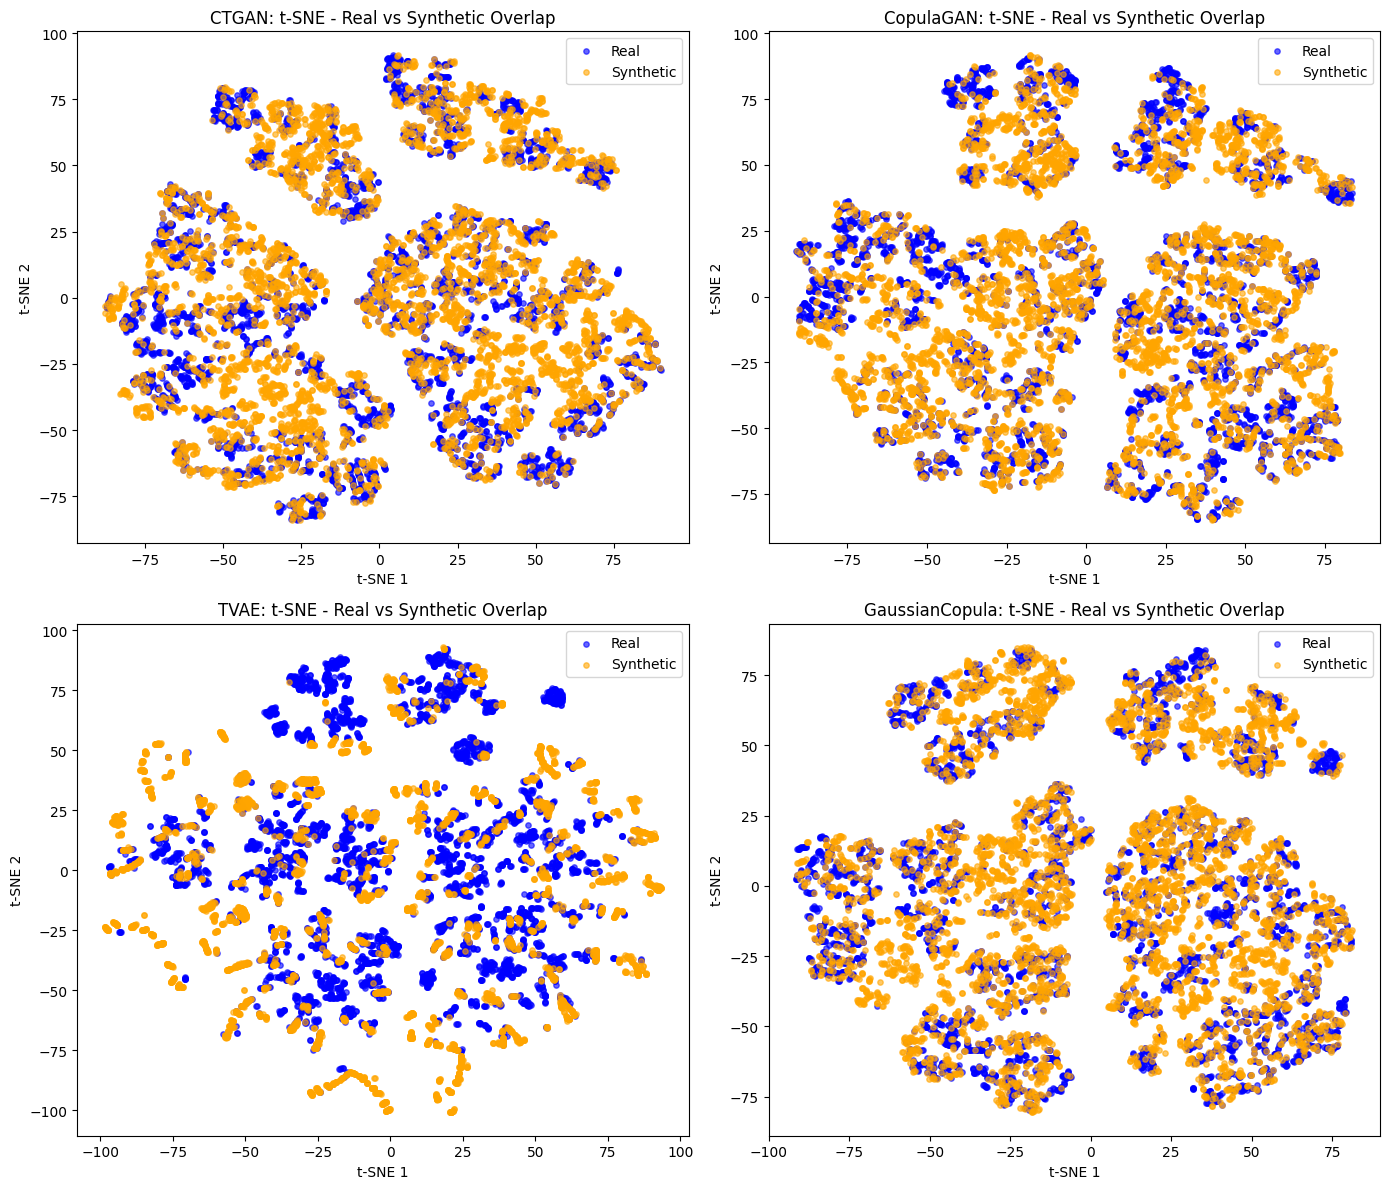

In [8]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "price"

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]

real_num = data[feature_cols].copy()

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(real_num),
    columns=feature_cols
)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_datasets[model_name][data.columns].copy()
    synth_num = synth_df[feature_cols].copy()

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_num),
        columns=feature_cols
    )

    combined = np.vstack([real_scaled.values, synthetic_scaled.values])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto")
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=15, label="Real"
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=15, label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()

### 1.6 MMD (Maximum Mean Discrepancy)


In [9]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel

def _sample_rows(X, max_rows=2000, seed=42):
    if X.shape[0] <= max_rows:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=max_rows, replace=False)
    return X[idx]

def _median_gamma(X, Y):
    Z = np.vstack([X, Y])
    n = Z.shape[0]
    take = min(1200, n)
    idx = np.random.default_rng(42).choice(n, size=take, replace=False)
    Zs = Z[idx]
    d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
    vals = d2[np.triu_indices_from(d2, k=1)]
    med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
    return 1.0 / (2.0 * med)

def compute_mmd_rbf_safe(X, Y, gamma=None):
    if gamma is None:
        gamma = _median_gamma(X, Y)
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    return float(Kxx.mean() + Kyy.mean() - 2.0 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "price"
drop_cols = [c for c in [target_col] if c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
real_features = real_features.select_dtypes(include=[np.number]).copy()

mmd_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    synth_features = synth_features.select_dtypes(include=[np.number]).copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].to_numpy(dtype=np.float64)
    X_synth = synth_features[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    Xr = _sample_rows(X_real_scaled, max_rows=2000, seed=42)
    Xs = _sample_rows(X_synth_scaled, max_rows=2000, seed=42)

    mmd_score = compute_mmd_rbf_safe(Xr, Xs, gamma=None)
    mmd_results.append({"Model": model_name, "MMD_Score": float(mmd_score)})

    print(f"{model_name} - MMD score: {mmd_score:.6f}")

mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")
display(mmd_summary_df)

CTGAN - MMD score: 0.008181
CopulaGAN - MMD score: 0.007746
TVAE - MMD score: 0.085852
GaussianCopula - MMD score: 0.002196

MMD comparison (lower is better):


,Model,MMD_Score
0,GaussianCopula,0.002196
1,CopulaGAN,0.007746
2,CTGAN,0.008181
3,TVAE,0.085852


### 1.7 Cosine Similarity


In [10]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "price"
drop_cols = [c for c in [target_col] if c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
real_features = real_features.select_dtypes(include=[np.number]).copy()

similarity_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    synth_features = synth_features.select_dtypes(include=[np.number]).copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].astype(np.float64)
    X_synth = synth_features[common_cols].astype(np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = float(np.mean(cross_sim))
    max_sim = float(np.max(cross_sim))

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)


CTGAN - Sample-Level Similarity:
Average cosine similarity: 0.0049
Maximum cosine similarity: 1.0000

CopulaGAN - Sample-Level Similarity:
Average cosine similarity: 0.0070
Maximum cosine similarity: 1.0000

TVAE - Sample-Level Similarity:
Average cosine similarity: 0.0171
Maximum cosine similarity: 1.0000

GaussianCopula - Sample-Level Similarity:
Average cosine similarity: 0.0040
Maximum cosine similarity: 0.9982

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,TVAE,0.017064,1.000000
1,CopulaGAN,0.006996,1.000000
2,CTGAN,0.004921,1.000000
3,GaussianCopula,0.004029,0.998188


### 1.8 Nearest Neighbours 


In [11]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "price"
drop_cols = [c for c in [target_col] if c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
real_features = real_features.select_dtypes(include=[np.number]).copy()

privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    synth_features = synth_features.select_dtypes(include=[np.number]).copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].astype(np.float64)
    X_synth = synth_features[common_cols].astype(np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)

    avg_nn_dist = float(np.mean(distances))
    min_nn_dist = float(np.min(distances))
    p5_nn_dist = float(np.percentile(distances, 5))

    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)


CTGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.1284
Minimum NN Distance (Synthetic -> Real): 0.0000
5th Percentile NN Distance: 0.3947

CopulaGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.0902
Minimum NN Distance (Synthetic -> Real): 0.0000
5th Percentile NN Distance: 0.2742

TVAE - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.5688
Minimum NN Distance (Synthetic -> Real): 0.0000
5th Percentile NN Distance: 0.1127

GaussianCopula - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.3041
Minimum NN Distance (Synthetic -> Real): 0.1657
5th Percentile NN Distance: 0.6086

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,GaussianCopula,1.304125,0.165675,0.608573
1,CTGAN,1.128394,0.000000,0.394695
2,CopulaGAN,1.090239,0.000000,0.274227
3,TVAE,0.568803,0.000000,0.112676


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,7.792363,2.029477,11.130659
1,CopulaGAN,6.679559,4.227368,5.983461
2,TVAE,19.159839,18.381722,32.912762
3,GaussianCopula,3.706453,0.495366,3.422963


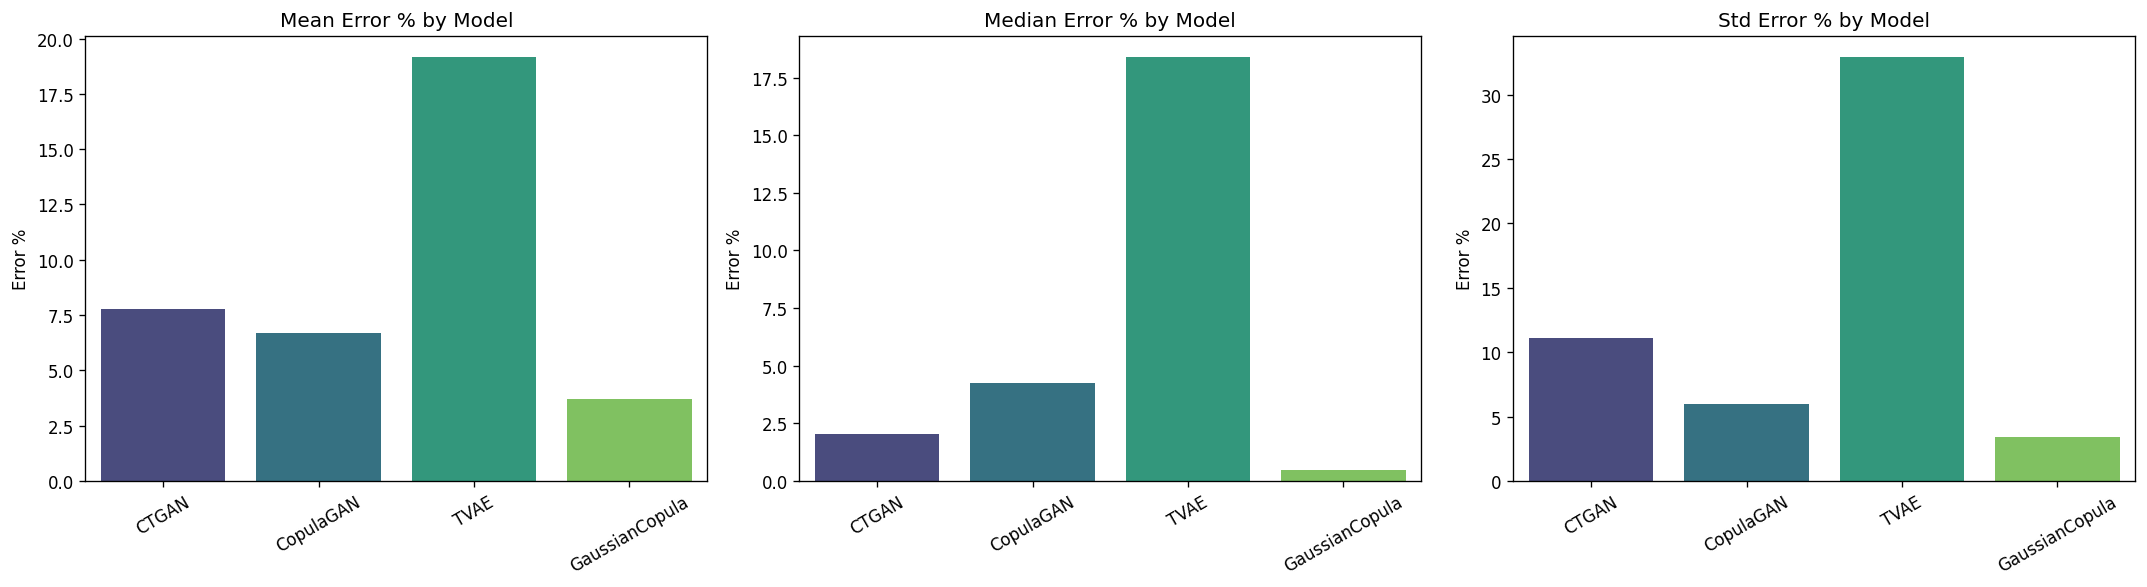

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "price"

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].astype(np.float64).mean()
    synth_means = synth_df[num_cols].astype(np.float64).mean()

    real_stds = real_df[num_cols].astype(np.float64).std(ddof=1)
    synth_stds = synth_df[num_cols].astype(np.float64).std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100.0
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100.0

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


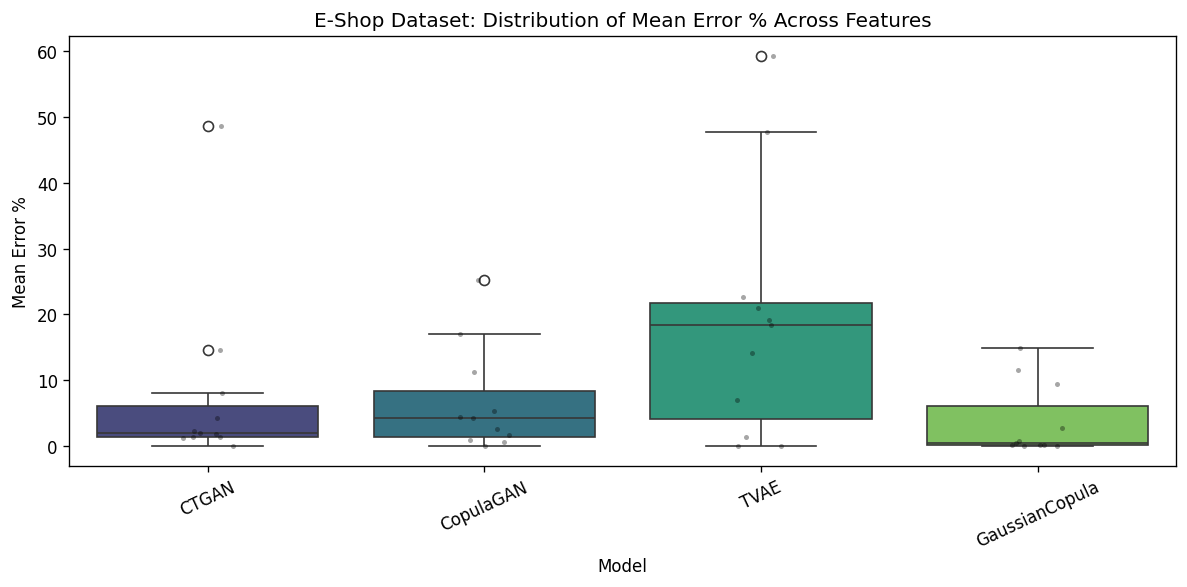

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("E-Shop Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

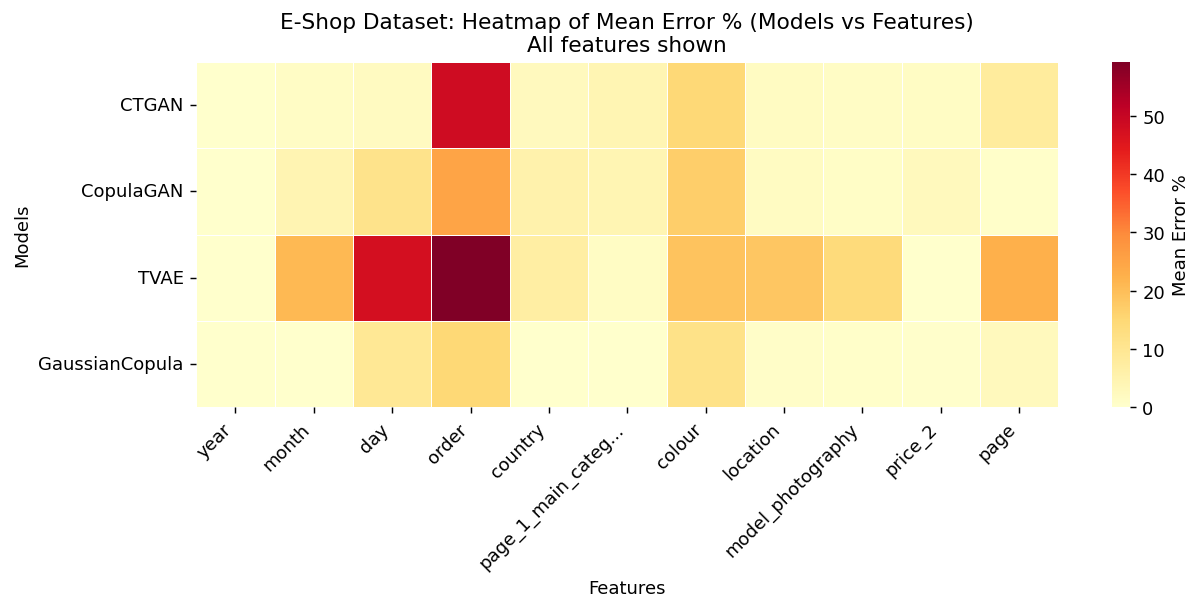

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"E-Shop Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2 Bivariate Analysis


In [15]:
from itertools import combinations
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def bivariate_quality(real_df, synth_df, target="price"):
    num_cols = real_df.select_dtypes(include=["number"]).columns.tolist()
    num_cols = [c for c in num_cols if c != target]

    scaler = MinMaxScaler()

    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()

    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])

    results_corr = []
    results_target = []

    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            "var_a": a,
            "var_b": b,
            "delta_corr": abs(r_corr - s_corr)
        })

    if target in real_scaled.columns and target in synth_scaled.columns:
        for col in num_cols:
            r_rel = real_scaled[[col, target]].corr(method="spearman").iloc[0, 1]
            s_rel = synth_scaled[[col, target]].corr(method="spearman").iloc[0, 1]
            results_target.append({
                "feature": col,
                "delta_target_relation": abs(r_rel - s_rel)
            })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = (
        pd.DataFrame(results_target).sort_values("delta_target_relation", ascending=False)
        if results_target else
        pd.DataFrame(columns=["feature", "delta_target_relation"])
    )

    return corr_df, target_df

In [16]:
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = data.copy()

target_col = "price"
date_col = None

if "bivariate_quality" in globals():
    quality_fn = bivariate_quality
else:
    raise NameError("Define `bivariate_quality` before running this cell.")

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_eval = real_df.copy()
    synth_eval = synth_df.copy()

    corr_results, target_results = quality_fn(
        real_df=real_eval,
        synth_df=synth_eval,
        target=target_col
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))
    print("=" * 60)
    print(f"{model_name} - Features that differ most by relation to {target_col}:")
    display(target_results.head(10))
    print("=" * 60)

    corr_metric_col = next(
        (c for c in ["AbsDiff", "abs_diff", "Difference", "diff", "delta_corr"] if c in corr_results.columns),
        None
    )
    target_metric_col = next(
        (c for c in ["AbsDiff", "abs_diff", "Difference", "diff", "delta_target_relation", "delta_wasserstein"] if c in target_results.columns),
        None
    )

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results[corr_metric_col].iloc[0] if corr_metric_col else None,
        "MeanTop10CorrDiff": corr_results[corr_metric_col].head(10).mean() if corr_metric_col else None,
        "TopTargetDiff": target_results[target_metric_col].iloc[0] if target_metric_col else None,
        "MeanTop10TargetDiff": target_results[target_metric_col].head(10).mean() if target_metric_col else None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)



CTGAN - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
44,page_1_main_category,page,0.334090
53,model_photography,page,0.283083
48,colour,page,0.232113
40,page_1_main_category,colour,0.221953
33,order,page,0.207403
28,order,page_1_main_category,0.167123
42,page_1_main_category,model_photography,0.159344
51,location,page,0.149226
34,country,page_1_main_category,0.113471
43,page_1_main_category,price_2,0.108258


CTGAN - Features that differ most by relation to price:


,feature,delta_target_relation
9,price_2,0.774381
5,page_1_main_category,0.332077
8,model_photography,0.208269
10,page,0.127493
6,colour,0.073404
7,location,0.070203
4,country,0.053227
3,order,0.029825
1,month,0.016662
2,day,0.008810



CopulaGAN - Largest differences in pairwise correlations:


...


GaussianCopula - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
44,page_1_main_category,page,0.349221
40,page_1_main_category,colour,0.245612
48,colour,page,0.238549
53,model_photography,page,0.213394
33,order,page,0.180876
42,page_1_main_category,model_photography,0.180477
28,order,page_1_main_category,0.137937
43,page_1_main_category,price_2,0.132534
34,country,page_1_main_category,0.095698
51,location,page,0.084153


GaussianCopula - Features that differ most by relation to price:


,feature,delta_target_relation
9,price_2,0.304026
5,page_1_main_category,0.281349
10,page,0.146821
8,model_photography,0.114365
7,location,0.099341
6,colour,0.049600
1,month,0.021044
2,day,0.019576
3,order,0.011109
4,country,0.003697


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,CTGAN,0.334090,0.197606,0.774381,0.169435
1,CopulaGAN,0.329411,0.217371,0.792994,0.177557
2,TVAE,0.484419,0.237321,0.216217,0.111397
3,GaussianCopula,0.349221,0.185845,0.304026,0.105093


### 3 Multivariate Analysis


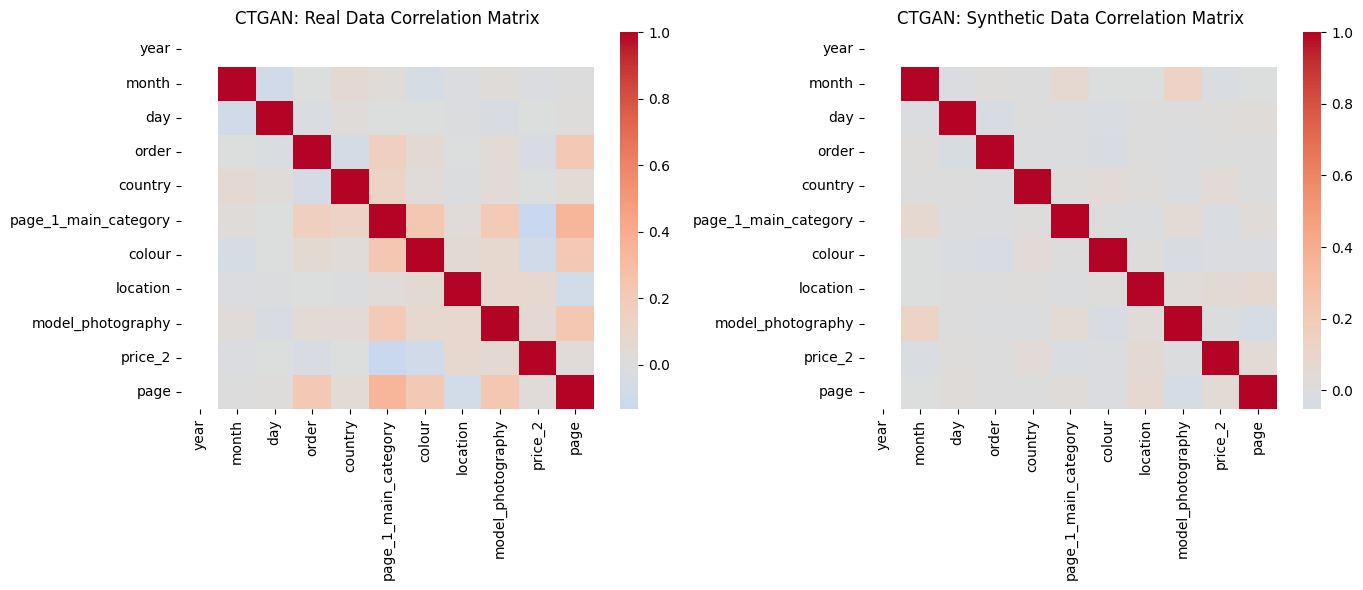

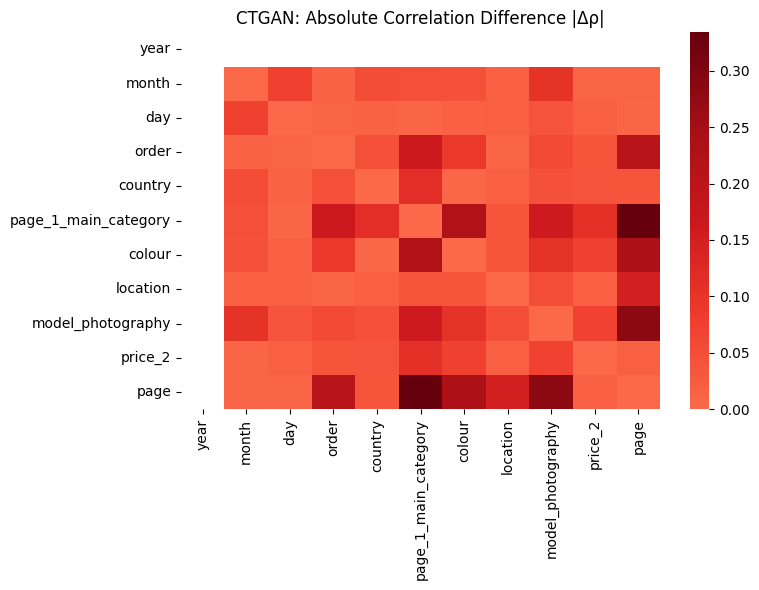

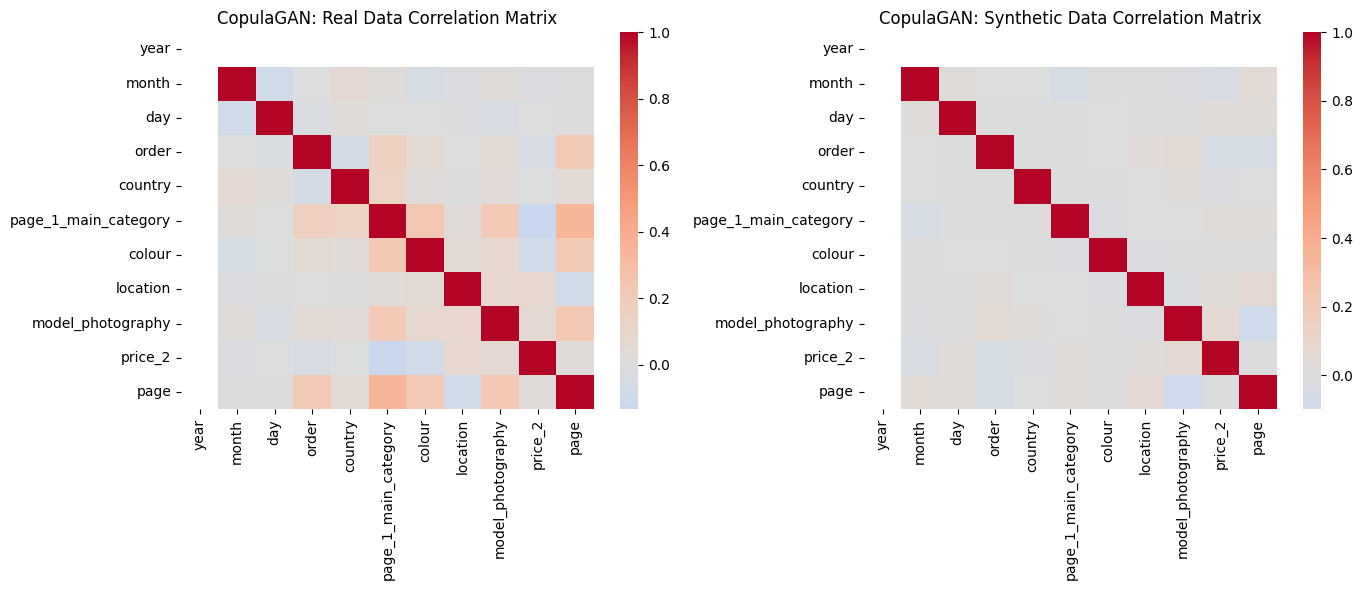

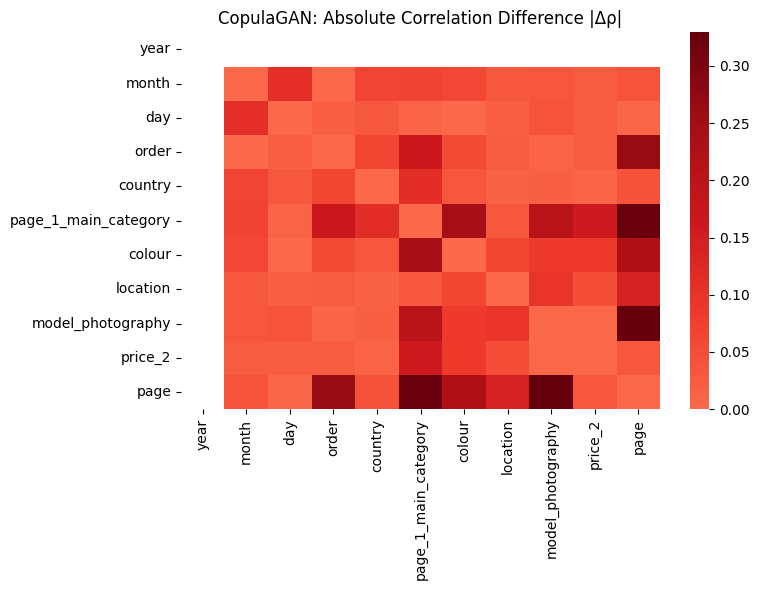

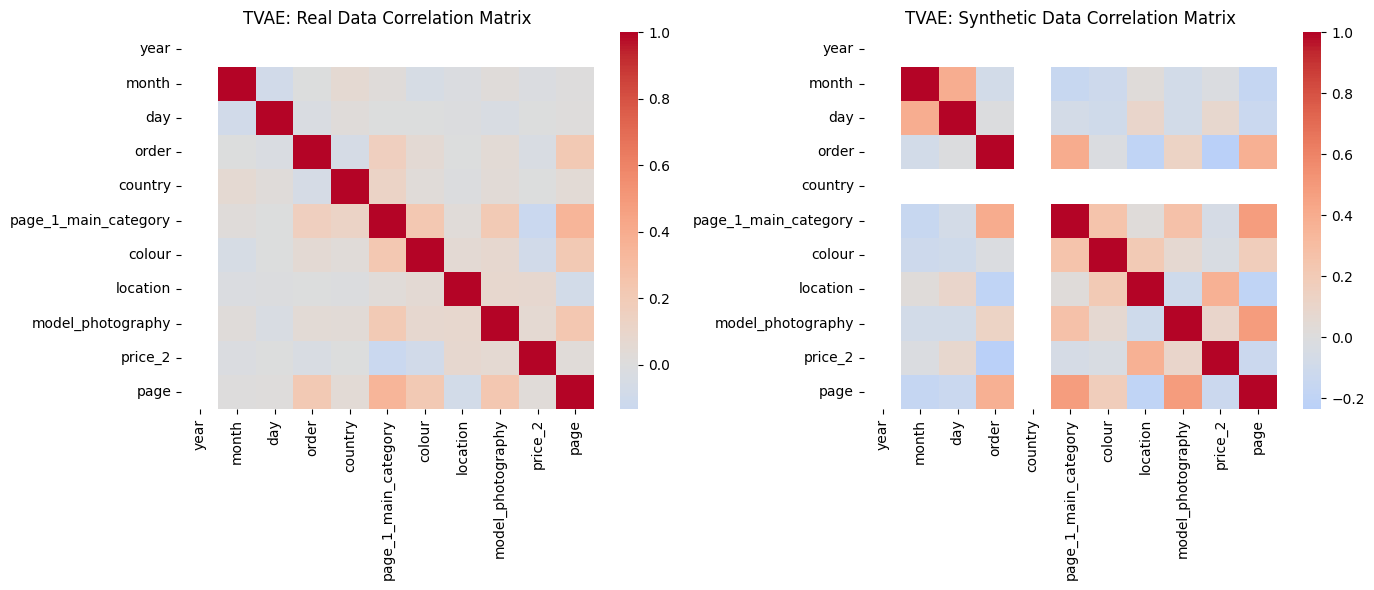

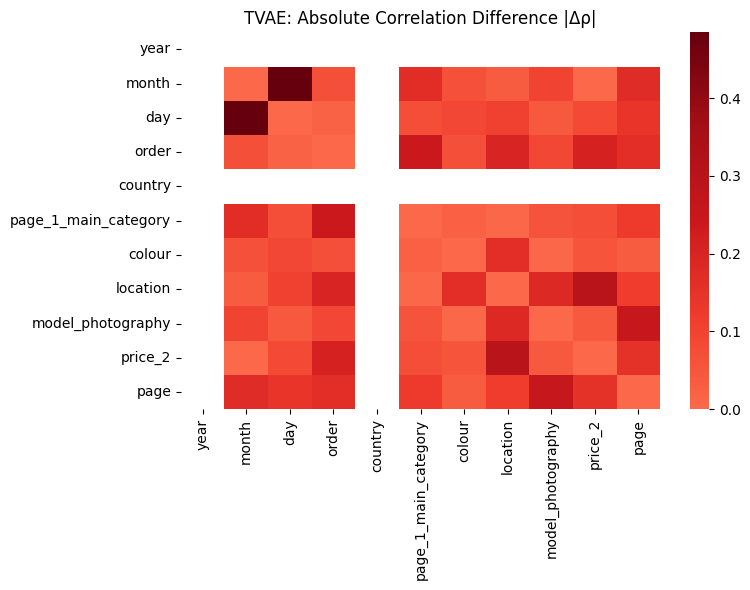

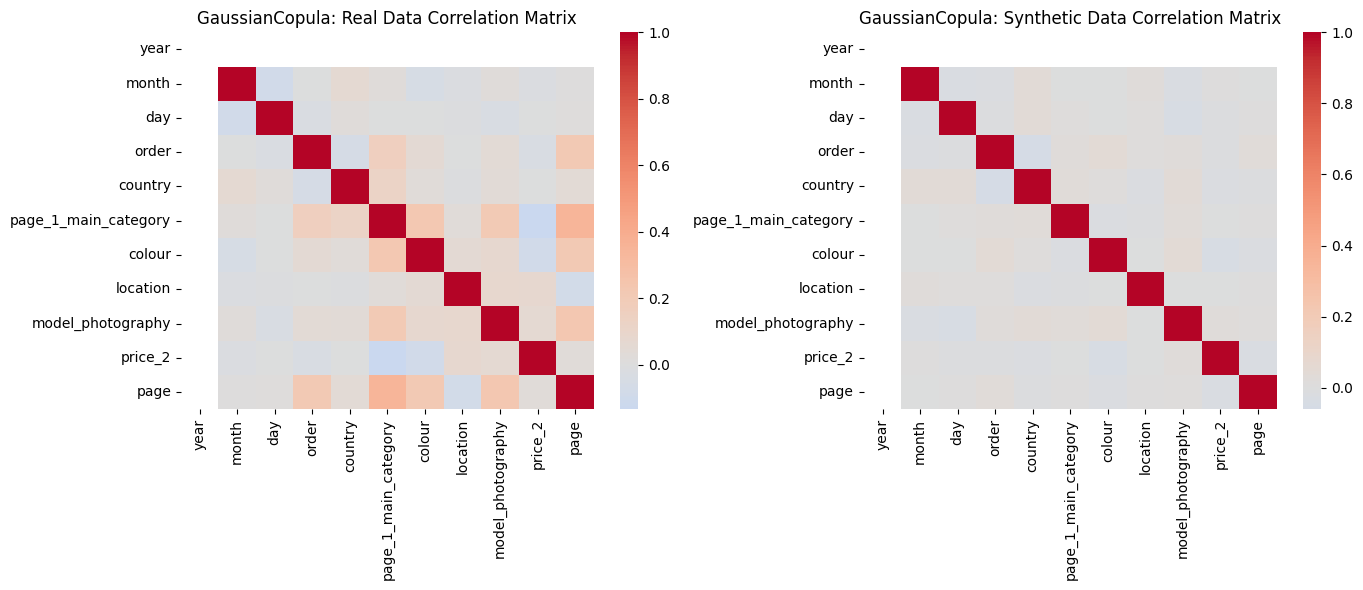

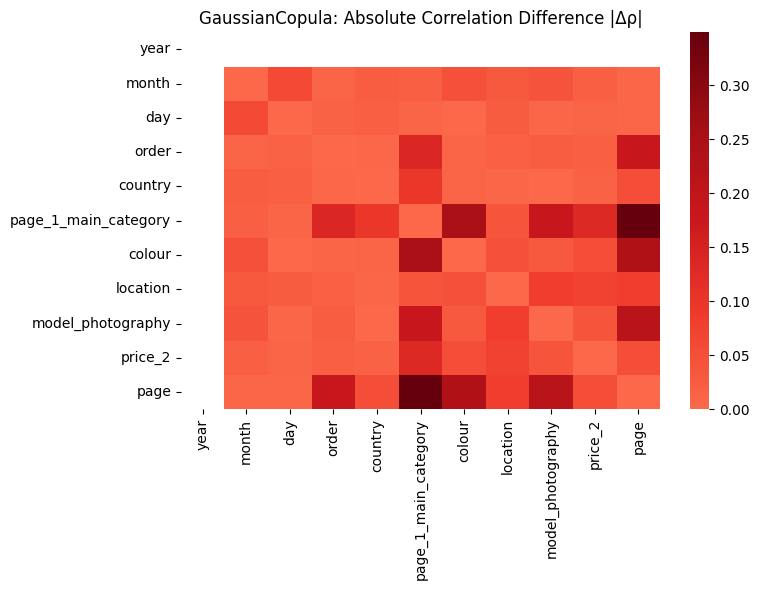

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
target_col = "price"

num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]
    synth_corr = synth_df[num_cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(real_corr, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    diff_corr = (real_corr - synth_corr).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()



CTGAN - Global MMD (RBF): 0.006853


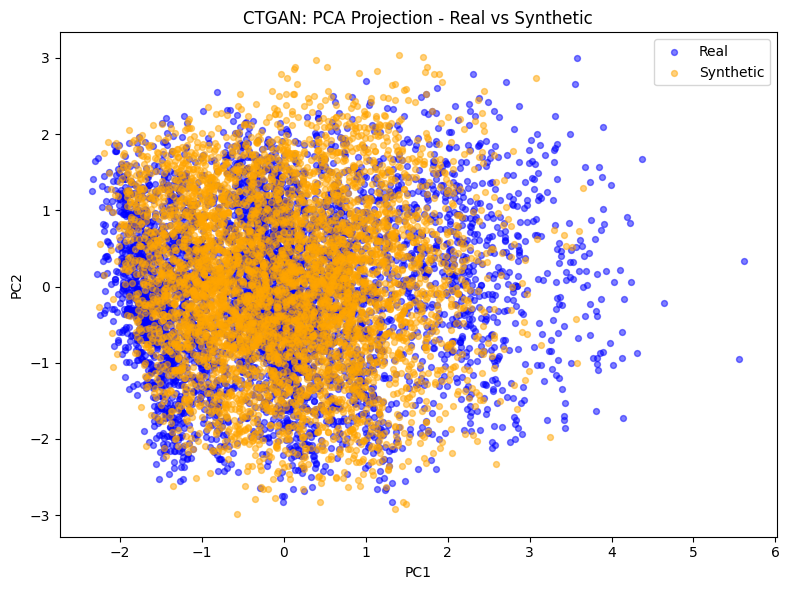

CTGAN - Two-Sample Classifier Accuracy: 0.8857

CopulaGAN - Global MMD (RBF): 0.007664


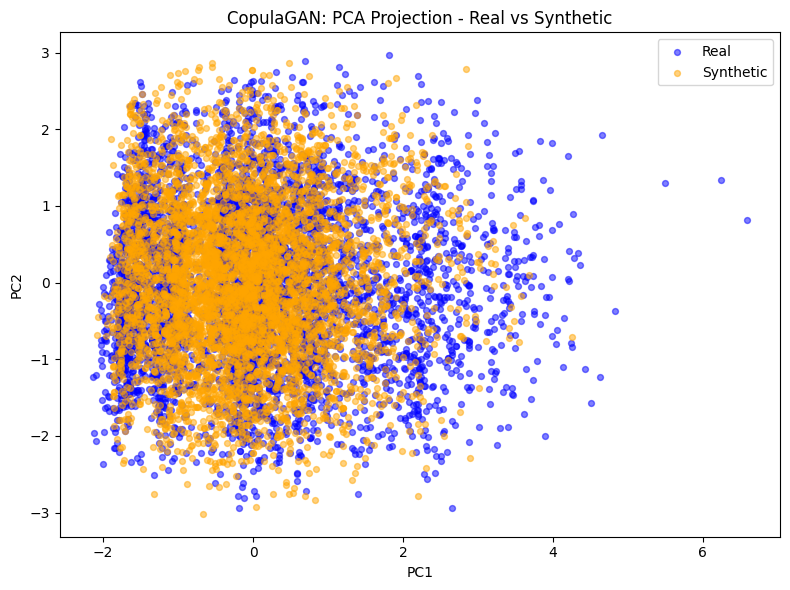

CopulaGAN - Two-Sample Classifier Accuracy: 0.8820

TVAE - Global MMD (RBF): 0.086052


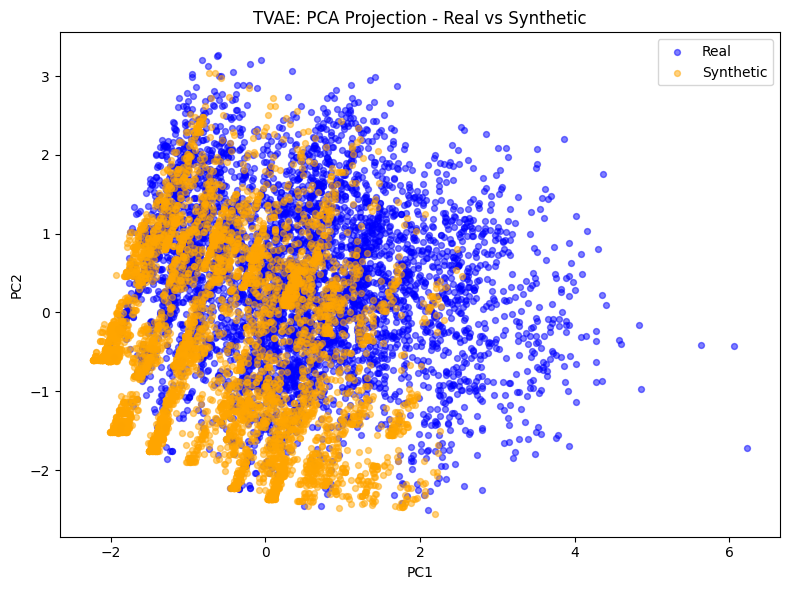

TVAE - Two-Sample Classifier Accuracy: 0.9240

GaussianCopula - Global MMD (RBF): 0.002340


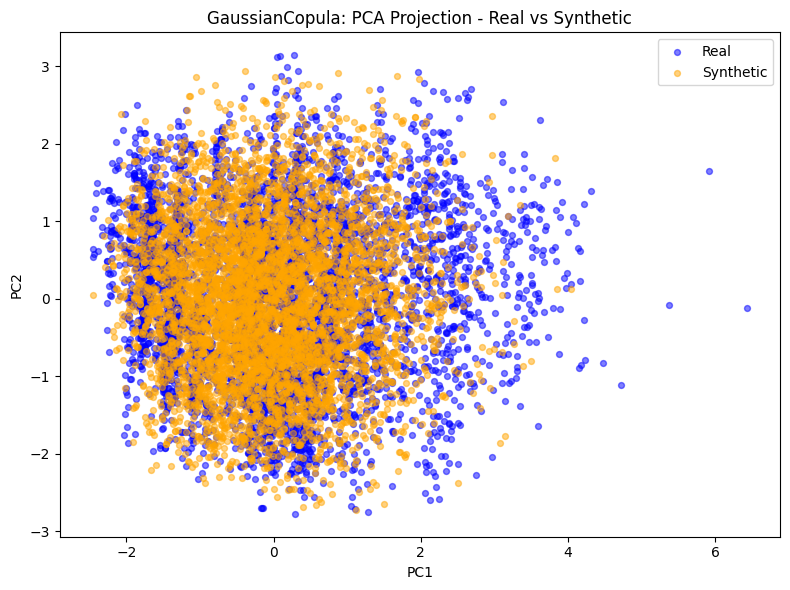

GaussianCopula - Two-Sample Classifier Accuracy: 0.9500

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,GaussianCopula,0.002340,0.950000
1,CTGAN,0.006853,0.885667
2,CopulaGAN,0.007664,0.882000
3,TVAE,0.086052,0.924000


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

def mmd_rbf(X, Y, gamma=None, gamma_sample_size=1500):
    if gamma is None:
        Z = np.vstack([X, Y])
        n = len(Z)
        k = min(gamma_sample_size, n)
        idx = np.random.default_rng(42).choice(n, size=k, replace=False)
        Zs = Z[idx]
        d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
        vals = d2[np.triu_indices_from(d2, k=1)]
        med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
        gamma = 1.0 / (2.0 * med)

    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)

    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "price"

drop_cols = [c for c in [target_col] if c in data.columns]

X_real_df = data.drop(columns=drop_cols, errors="ignore").copy()
X_real_df = X_real_df.select_dtypes(include=[np.number]).copy()

results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    X_synth_df = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    X_synth_df = X_synth_df.select_dtypes(include=[np.number]).copy()

    common_cols = X_real_df.columns.intersection(X_synth_df.columns)
    X_real = X_real_df[common_cols].to_numpy(dtype=np.float64)
    X_synth = X_synth_df[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[labels == "Real", 0], X_pca[labels == "Real", 1],
                color="blue", alpha=0.5, label="Real", s=18)
    plt.scatter(X_pca[labels == "Synthetic", 0], X_pca[labels == "Synthetic", 1],
                color="orange", alpha=0.5, label="Synthetic", s=18)
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestRegressor(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = r2_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": float(mmd_value),
        "C2ST_Accuracy": float(acc)
    })

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)


# 4 Utility with 10 regression models 

In [19]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'ElasticNet': ElasticNet(random_state=42),
    'SVR-RBF': SVR(kernel='rbf'),
    'KNN': KNeighborsRegressor(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'ExtraTrees': ExtraTreesRegressor(random_state=42),
    'GradientBoost': GradientBoostingRegressor(random_state=42),
    'MLP': MLPRegressor(max_iter=2000, random_state=42)
}

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

def evaluate_models_regression(train_df, test_df, label_col, models, test_size=0.2, seed=42):
    X_train = train_df.drop(columns=[label_col]).copy()
    y_train = train_df[label_col].copy()

    X_test = test_df.drop(columns=[label_col]).copy()
    y_test = test_df[label_col].copy()

    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    X_train = X_train[num_cols].astype(np.float64)
    X_test = X_test[num_cols].astype(np.float64)

    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed
    )

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    rows = []
    for name, reg in models.items():
        reg.fit(X_train_s, y_train)
        y_pred = reg.predict(X_test_s)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        rows.append({
            "Model": name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

    return pd.DataFrame(rows).sort_values(by="RMSE", ascending=True).reset_index(drop=True)


CTGAN - TSTR


,Model,MAE,RMSE,R2
0,ElasticNet,10.349560,12.757810,-0.000020
1,Lasso,10.349560,12.757810,-0.000020
2,Ridge,10.429310,12.790083,-0.005086
3,LinearRegression,10.429331,12.790095,-0.005088
4,GradientBoost,10.610750,13.264208,-0.080984
5,MLP,10.700282,13.291082,-0.085369
6,RandomForest,10.932758,13.512098,-0.121766
7,SVR-RBF,10.358543,13.649514,-0.144698
8,ExtraTrees,11.102238,13.744648,-0.160710
9,KNN,11.313840,14.184174,-0.236132


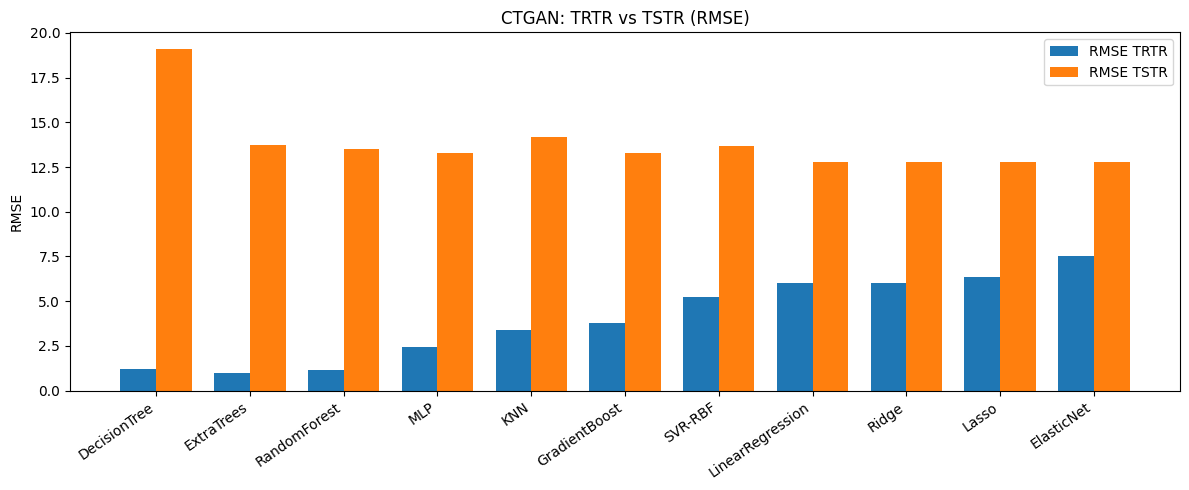

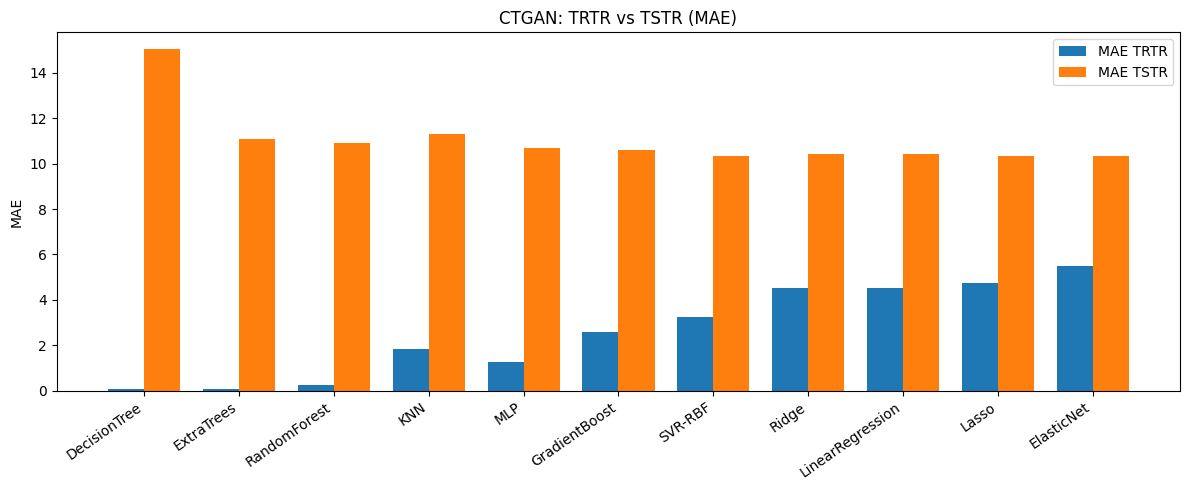

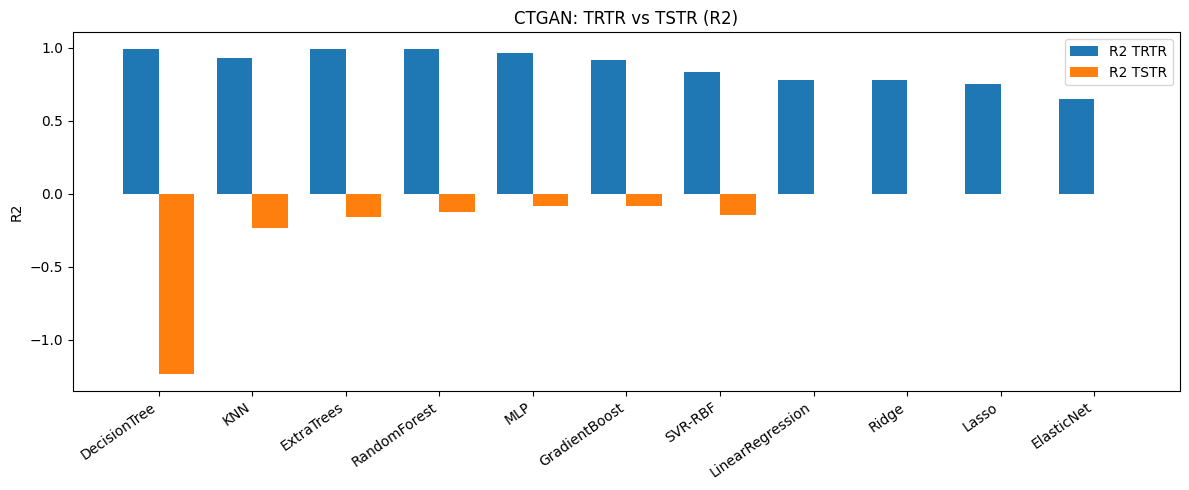

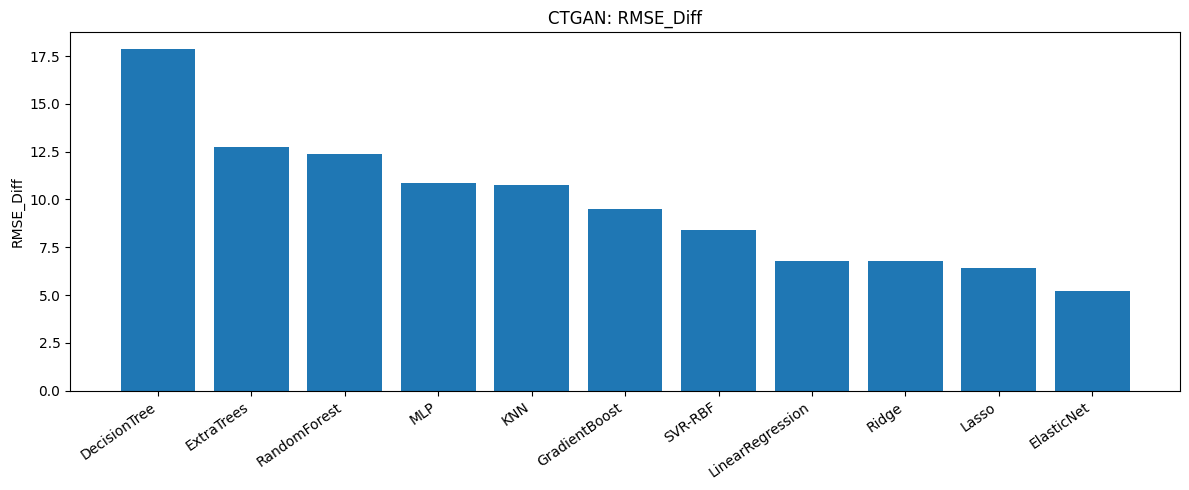

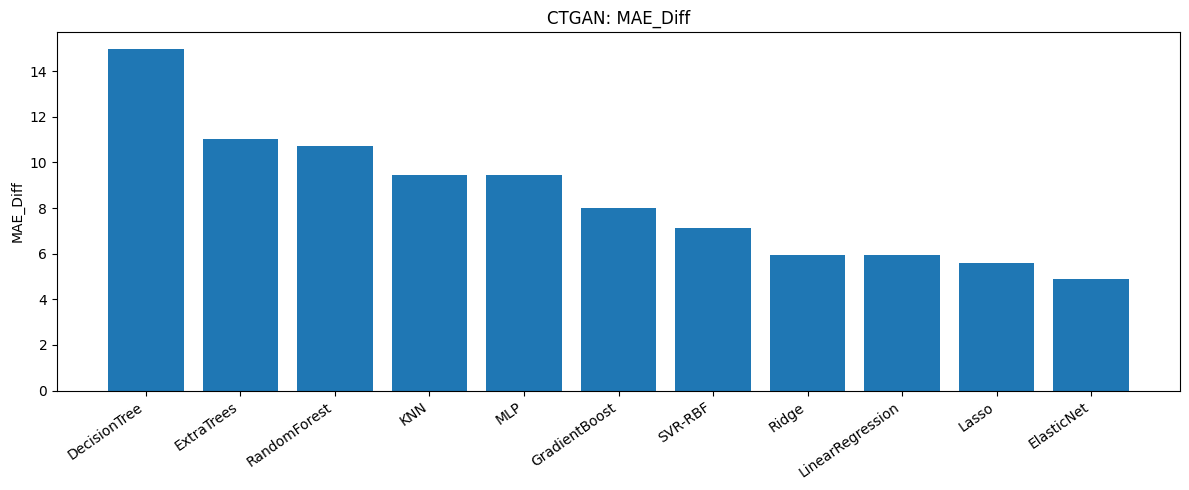

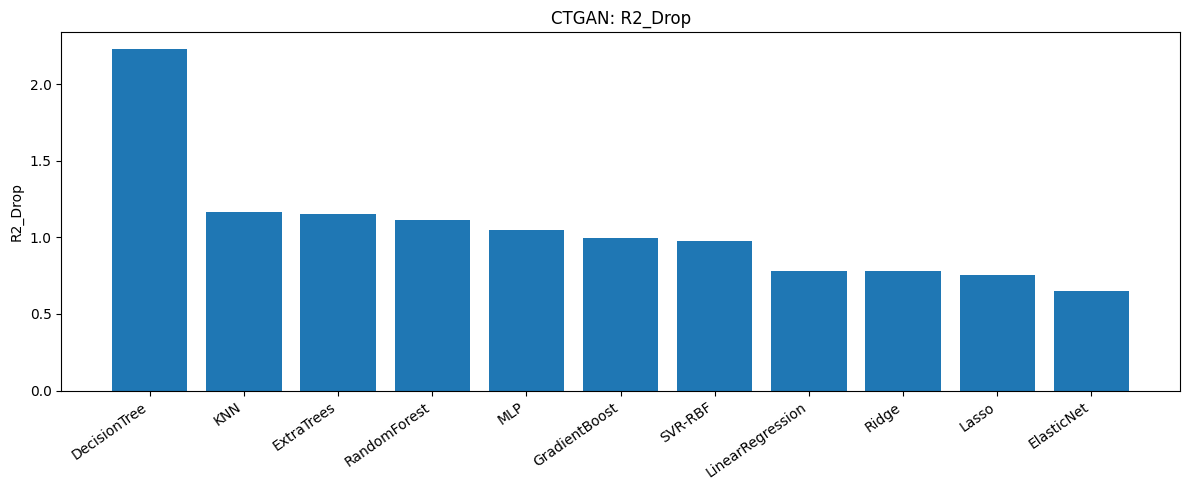


CopulaGAN - TSTR


,Model,MAE,RMSE,R2
0,SVR-RBF,10.035445,12.475683,0.043720
1,LinearRegression,10.135458,12.769187,-0.001805
2,Ridge,10.135455,12.769198,-0.001807
3,MLP,10.246360,12.790133,-0.005094
4,ElasticNet,10.144517,12.825047,-0.010589
5,Lasso,10.144517,12.825047,-0.010589
6,GradientBoost,10.283838,12.861480,-0.016339
7,RandomForest,10.429332,13.090079,-0.052788
8,ExtraTrees,10.728351,13.502595,-0.120188
9,KNN,10.899520,13.845336,-0.177778


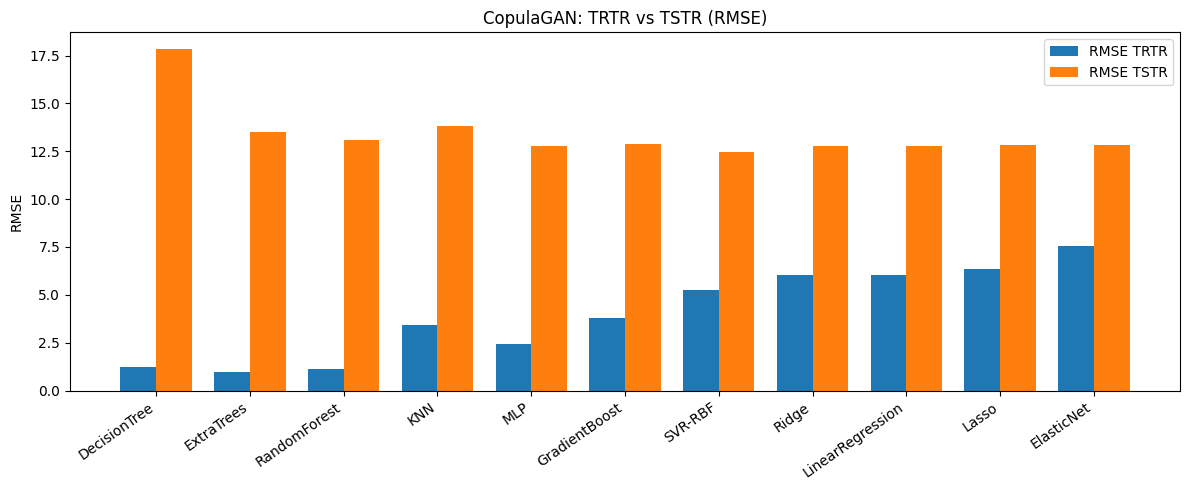

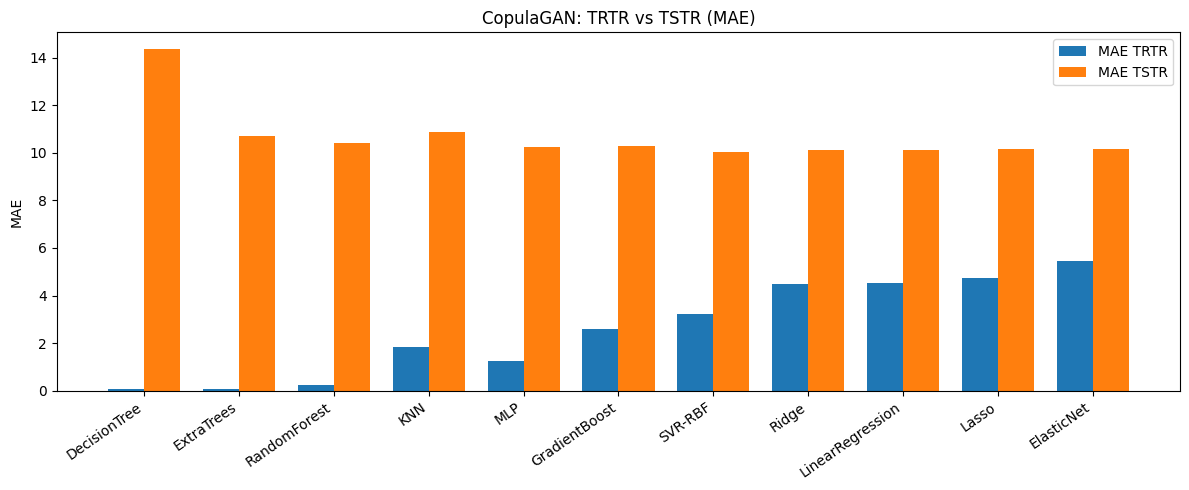

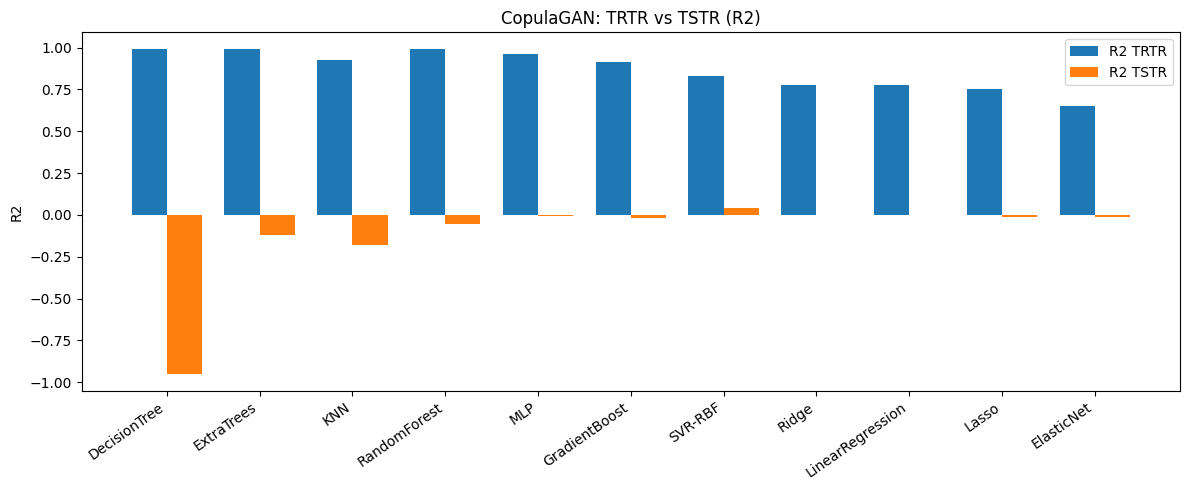

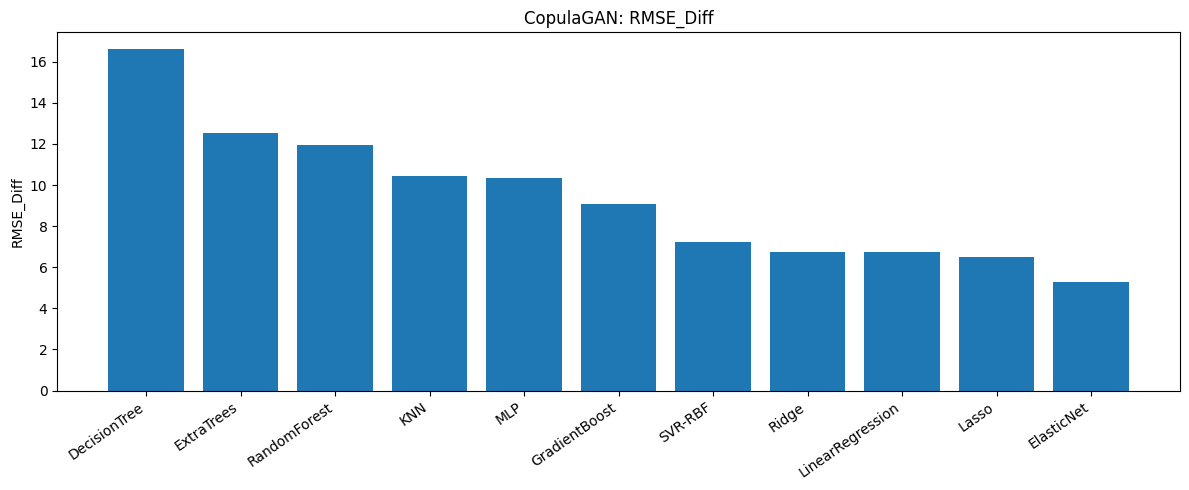

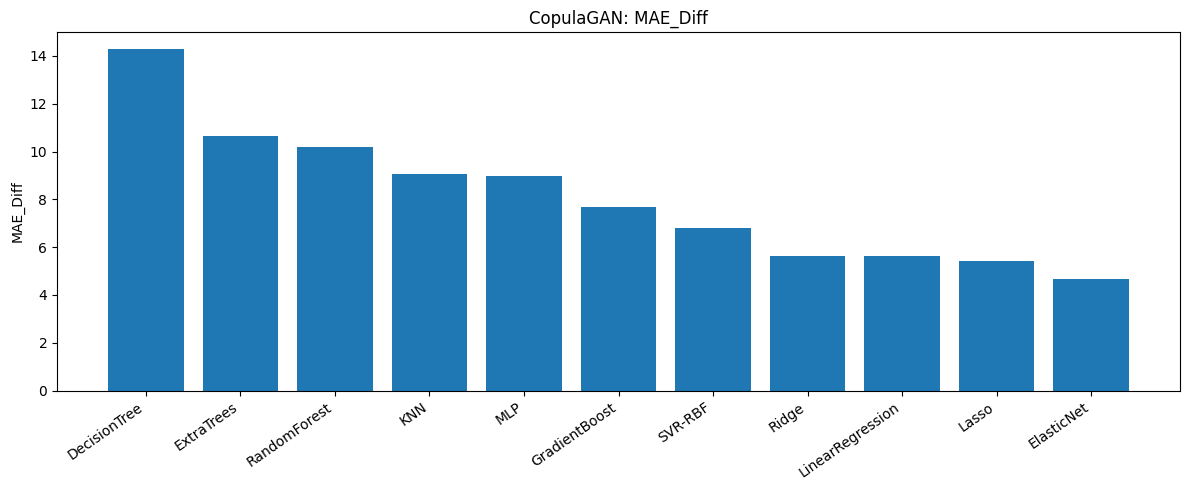

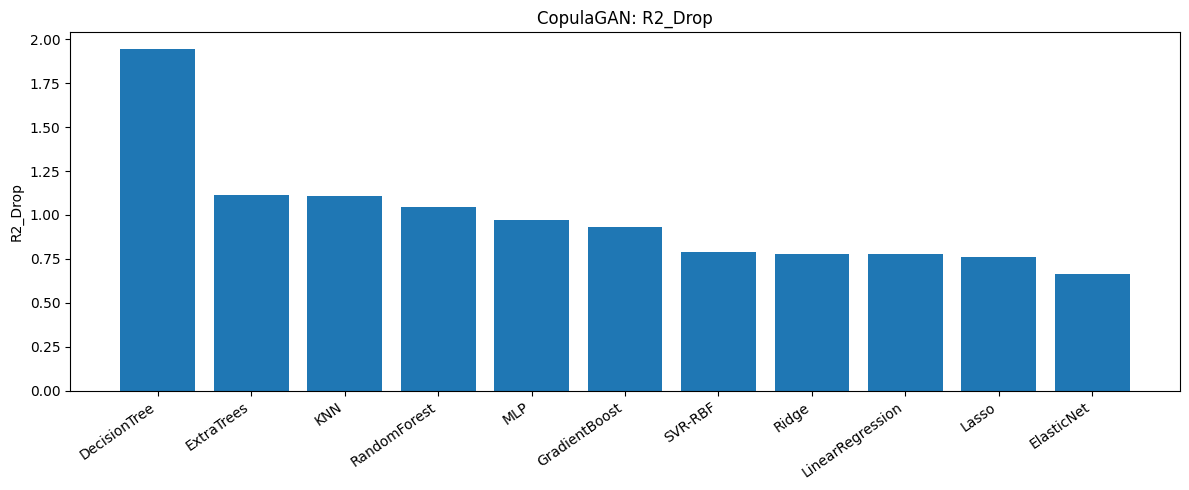


TVAE - TSTR


,Model,MAE,RMSE,R2
0,LinearRegression,6.582532,9.160992,0.484366
1,Ridge,6.583094,9.161764,0.484279
2,RandomForest,6.485730,9.375182,0.459972
3,GradientBoost,6.670014,9.413069,0.455599
4,Lasso,6.870484,9.429814,0.453660
5,ExtraTrees,6.684795,9.713307,0.420317
6,ElasticNet,7.437576,10.328629,0.344546
7,KNN,7.952920,10.927060,0.266393
8,DecisionTree,7.670296,11.102143,0.242696
9,SVR-RBF,8.927084,12.439716,0.049226


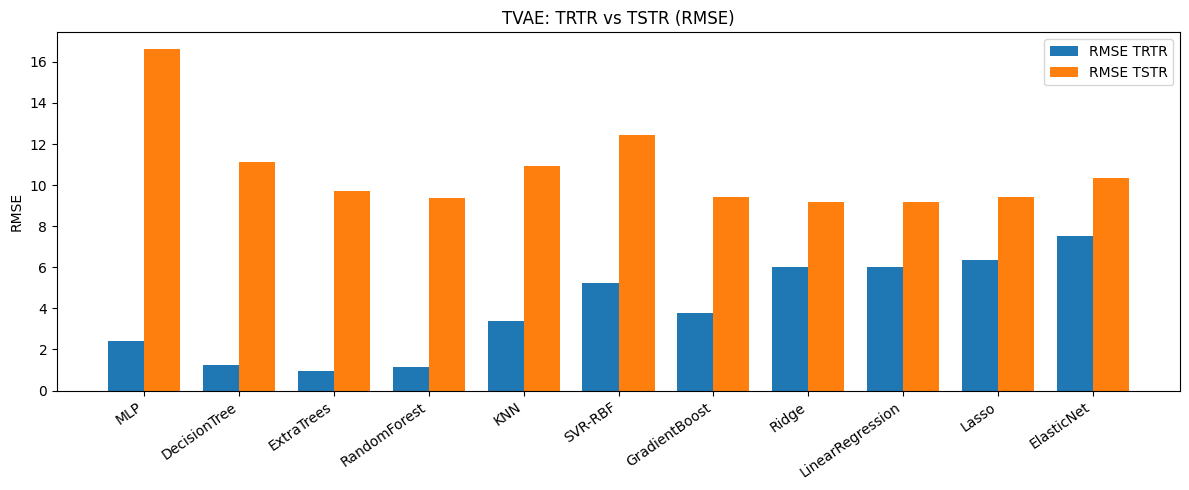

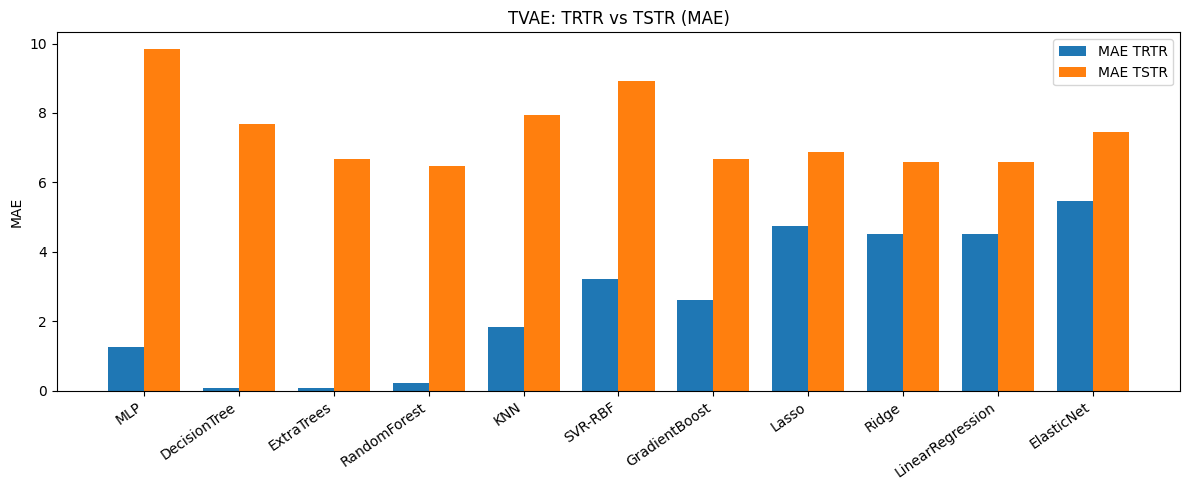

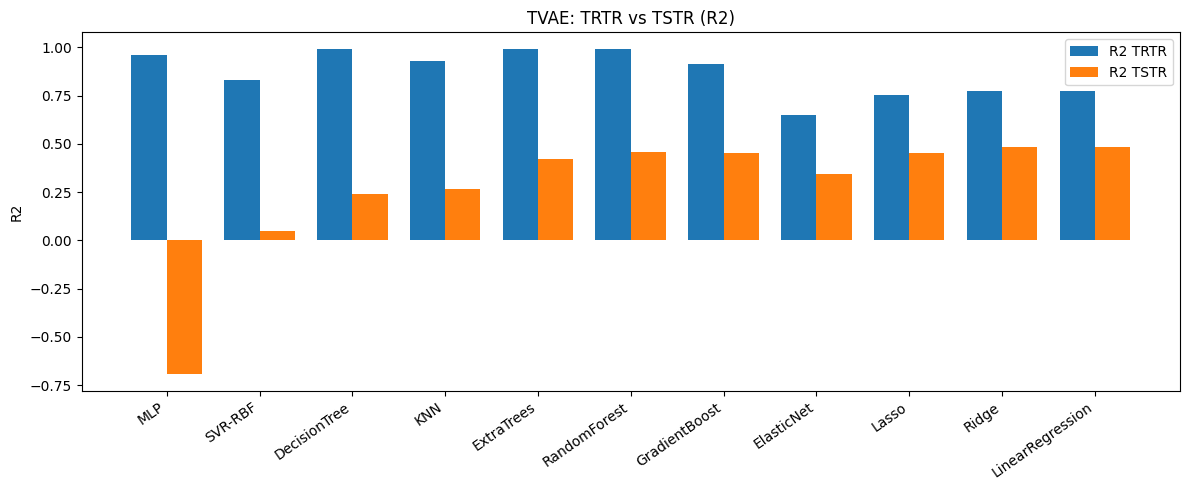

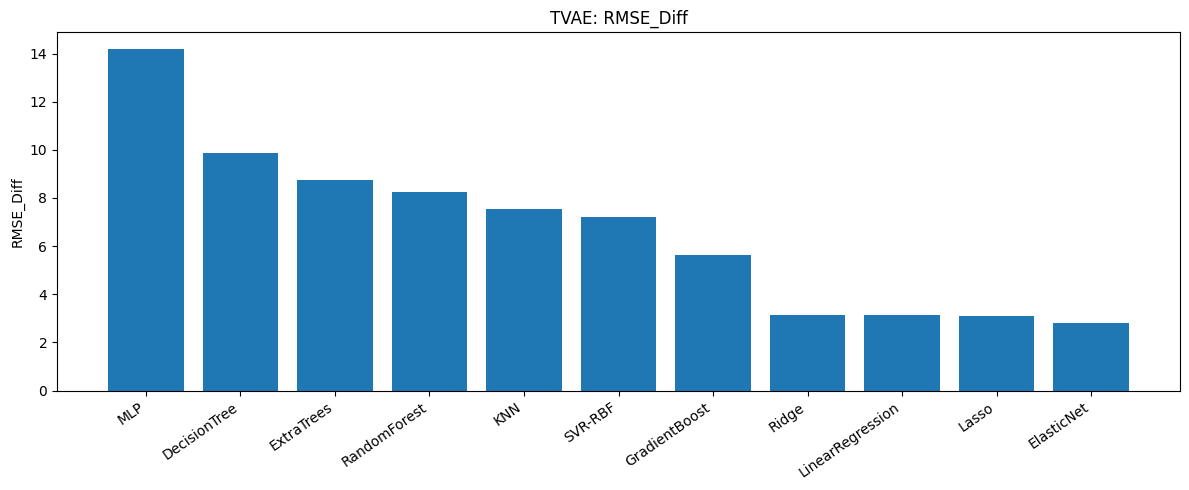

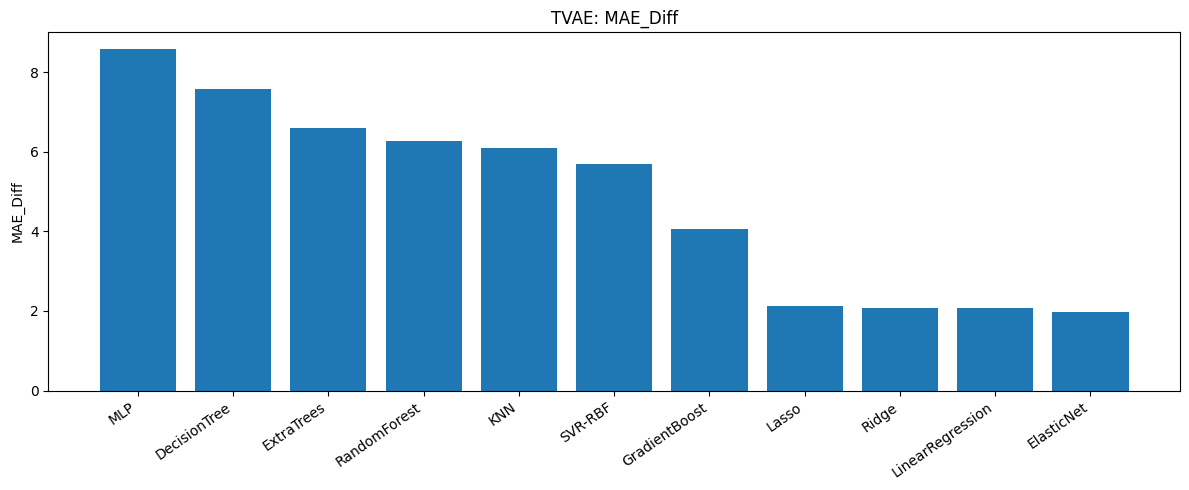

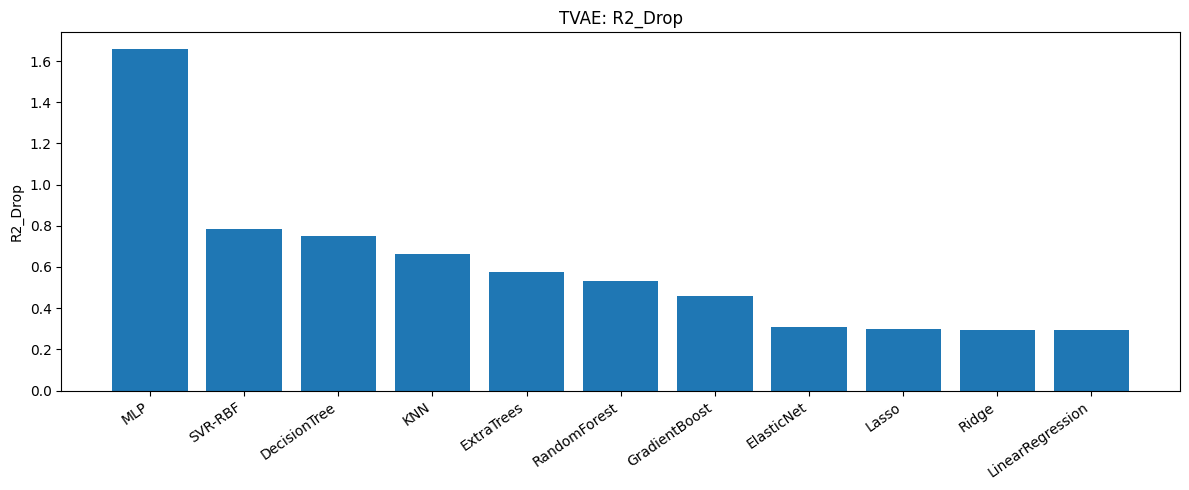


GaussianCopula - TSTR


,Model,MAE,RMSE,R2
0,LinearRegression,6.571977,8.625196,0.542918
1,Ridge,6.572581,8.625927,0.542840
2,GradientBoost,6.645975,8.811919,0.522913
3,MLP,6.782050,8.990859,0.503340
4,SVR-RBF,6.845113,9.120808,0.488880
5,RandomForest,7.082104,9.154624,0.485083
6,ExtraTrees,7.211986,9.232060,0.476335
7,Lasso,7.380289,9.631892,0.429994
8,KNN,7.685880,9.958978,0.390623
9,ElasticNet,7.930725,10.205756,0.360049


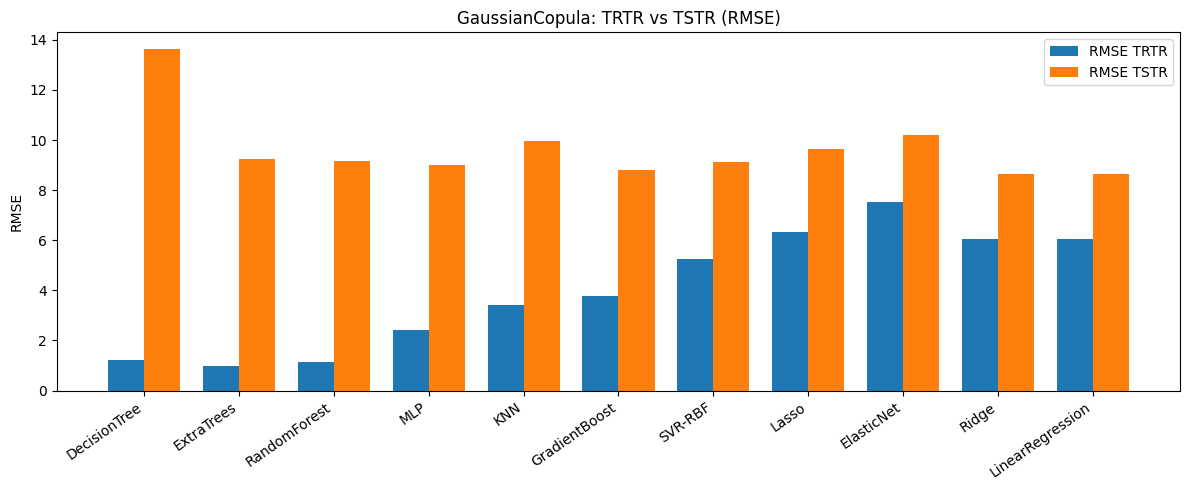

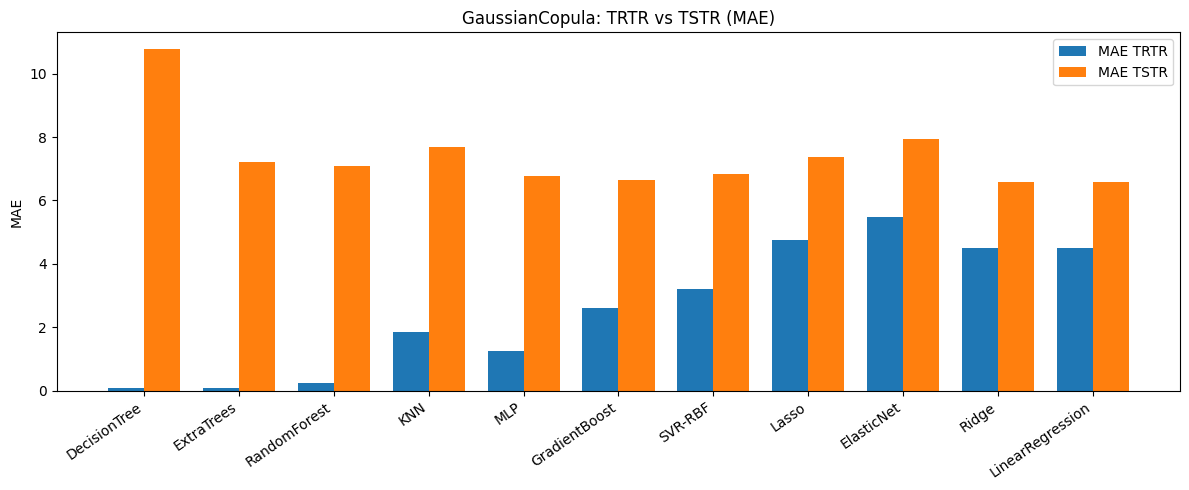

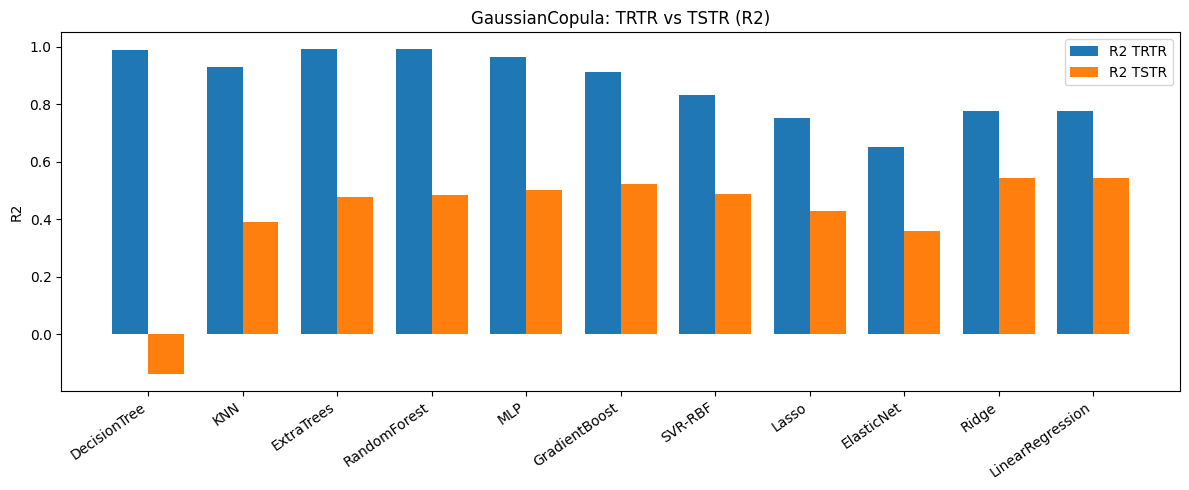

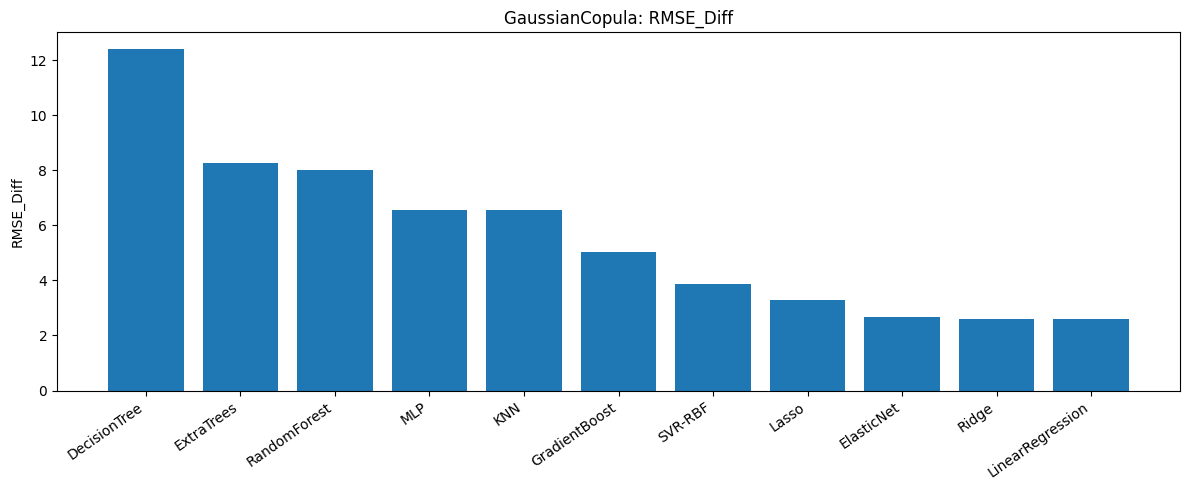

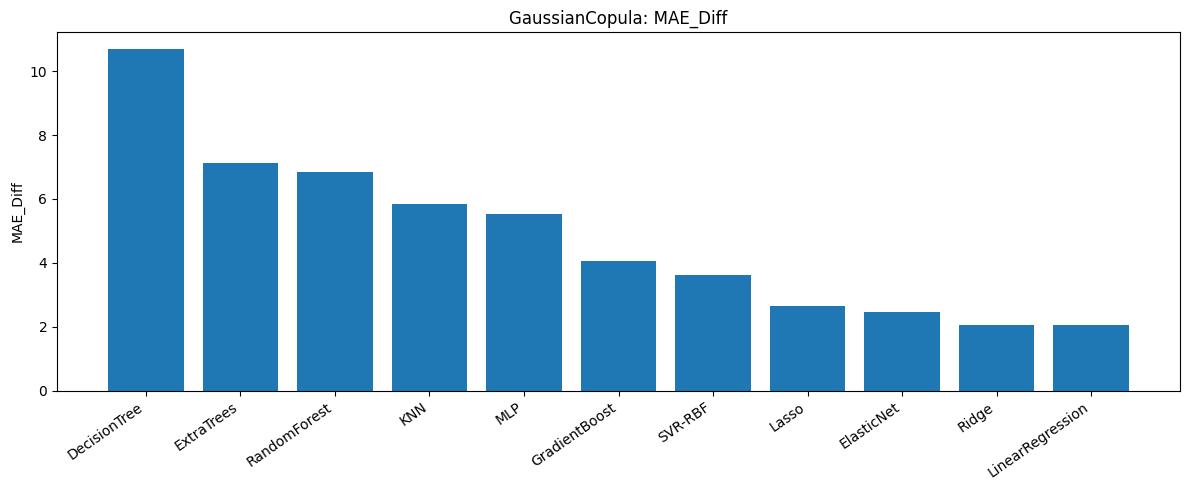

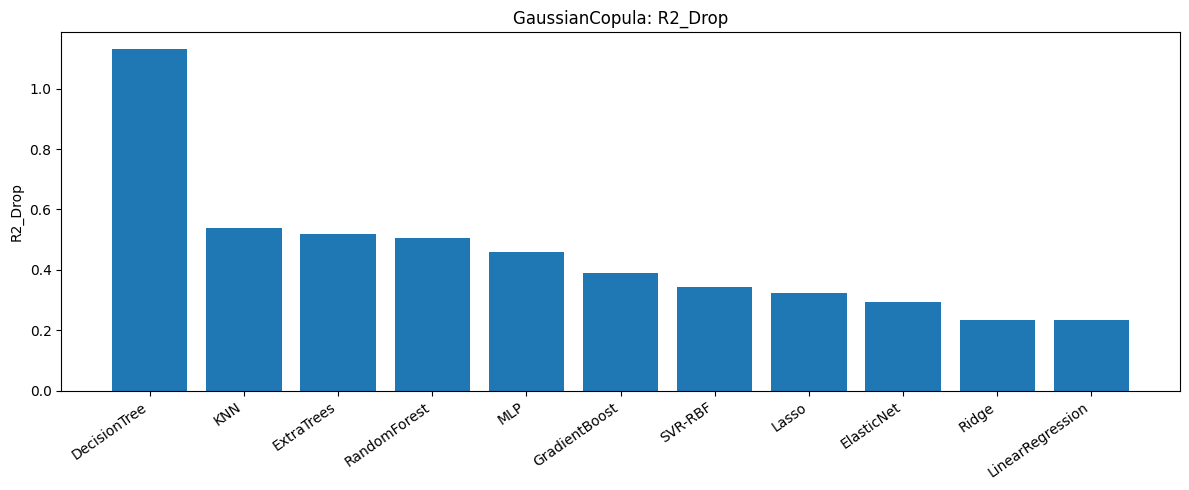


Average metric gap by synthetic generator:


,Synthetic_Model,RMSE_Diff,MAE_Diff,R2_Drop
2,GaussianCopula,5.623407,4.812911,0.451575
3,TVAE,6.685432,4.832911,0.600381
1,CopulaGAN,9.405483,8.091358,0.988749
0,CTGAN,9.791307,8.461911,1.058883


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="RMSE"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )

    if metric in ["MAE", "RMSE"]:
        df["Diff"] = df[f"{metric}_TSTR"] - df[f"{metric}_TRTR"]
    else:
        df["Diff"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]

    df = df.sort_values("Diff", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w/2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w/2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_metric_diff(comparison_df, synth_name, metric="RMSE_Diff"):
    if metric not in comparison_df.columns:
        return

    df = comparison_df.sort_values(metric, ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df[metric])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: {metric}")
    plt.tight_layout()
    plt.show()

label_col = "price"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models_regression(
    train_df=data,
    test_df=data,
    label="price",
    models=models
)

all_comp = []

for synth_name in model_order:
    _common = [c for c in data.columns if c in synthetic_datasets[synth_name].columns]
    synth_train = synthetic_datasets[synth_name][_common].copy()

    tstr_results = evaluate_models_regression(
        train_df=synth_train,
        test_df=data,
        label="price",
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )
    comparison["MAE_Diff"] = comparison["MAE_TSTR"] - comparison["MAE_TRTR"]
    comparison["RMSE_Diff"] = comparison["RMSE_TSTR"] - comparison["RMSE_TRTR"]
    comparison["R2_Drop"] = comparison["R2_TRTR"] - comparison["R2_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR")
    display(tstr_results)

    for metric in ["RMSE", "MAE", "R2"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric=metric)

    for diff_metric in ["RMSE_Diff", "MAE_Diff", "R2_Drop"]:
        plot_metric_diff(comparison, synth_name, metric=diff_metric)

combined_comparison = pd.concat(all_comp, ignore_index=True)

summary_gap = (combined_comparison
               .groupby("Synthetic_Model", as_index=False)[["RMSE_Diff", "MAE_Diff", "R2_Drop"]]
               .mean()
               .sort_values("RMSE_Diff"))

print("\nAverage metric gap by synthetic generator:")
display(summary_gap)


In [22]:
import time
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

label_col = "price"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

def pick_10_models(models_dict):
    keys = list(models_dict.keys())
    if len(keys) < 10:
        raise ValueError(f"`models` has only {len(keys)} models; need at least 10.")
    chosen = keys[:10]
    return {k: clone(models_dict[k]) for k in chosen}

def run_reg_models(X_train, y_train, X_test, y_test, models_dict):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    rows = []
    for name, reg in models_dict.items():
        t0 = time.time()
        m = clone(reg)
        m.fit(X_train_s, y_train)
        y_pred = m.predict(X_test_s)

        rows.append({
            "Model": name,
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "R2": r2_score(y_test, y_pred),
            "FitSec": round(time.time() - t0, 3),
        })
    return pd.DataFrame(rows)

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in num_cols if c != label_col]

real_eval = data.copy()
X_real = real_eval[feature_cols].to_numpy(dtype=np.float32)
y_real = real_eval[label_col].to_numpy(dtype=np.float32)

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42
)

models_used = pick_10_models(models)
print(f"Using {len(models_used)} models: {list(models_used.keys())}")

trtr_results = run_reg_models(X_train_real, y_train_real, X_test_real, y_test_real, models_used)

all_comparisons = []

for synth_name in model_order:
    synth_df = synthetic_datasets[synth_name][data.columns].copy()

    X_synth = synth_df[feature_cols].to_numpy(dtype=np.float32)
    y_synth = synth_df[label_col].to_numpy(dtype=np.float32)

    tstr_results = run_reg_models(X_synth, y_synth, X_test_real, y_test_real, models_used)

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )
    comparison["MAE_Diff"] = comparison["MAE_TSTR"] - comparison["MAE_TRTR"]
    comparison["RMSE_Diff"] = comparison["RMSE_TSTR"] - comparison["RMSE_TRTR"]
    comparison["R2_Drop"] = comparison["R2_TRTR"] - comparison["R2_TSTR"]
    comparison["Synthetic_Model"] = synth_name

    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)

summary = (
    combined_comparison
    .groupby("Synthetic_Model", as_index=False)[["MAE_Diff", "RMSE_Diff", "R2_Drop"]]
    .mean()
    .sort_values("RMSE_Diff")
)

print("Average performance gap by synthetic generator (lower is better):")
display(summary)

print("\nPer-model timing (seconds):")
timing_cols = [c for c in combined_comparison.columns if "FitSec" in c]
display(combined_comparison[["Synthetic_Model", "Model"] + timing_cols].sort_values(timing_cols[-1], ascending=False))

Using 10 models: ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet', 'SVR-RBF', 'KNN', 'DecisionTree', 'RandomForest', 'ExtraTrees', 'GradientBoost']
Average performance gap by synthetic generator (lower is better):


,Synthetic_Model,MAE_Diff,RMSE_Diff,R2_Drop
2,GaussianCopula,4.567482,5.099545,0.458467
3,TVAE,4.175097,5.335586,0.476664
1,CopulaGAN,7.659481,8.701358,0.976512
0,CTGAN,7.973568,8.966530,1.029230



Per-model timing (seconds):


,Synthetic_Model,Model,FitSec_TRTR,FitSec_TSTR
7,CTGAN,RandomForest,0.594,2.120
17,CopulaGAN,RandomForest,0.594,2.051
37,GaussianCopula,RandomForest,0.594,1.864
18,CopulaGAN,ExtraTrees,0.339,1.828
8,CTGAN,ExtraTrees,0.339,1.687
14,CopulaGAN,SVR-RBF,0.702,1.604
4,CTGAN,SVR-RBF,0.702,1.468
24,TVAE,SVR-RBF,0.702,1.336
34,GaussianCopula,SVR-RBF,0.702,1.246
38,GaussianCopula,ExtraTrees,0.339,1.189


In [23]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

label_col = "price"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

def get_preprocessor(df):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in df.columns if c not in num_cols]

    return ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ])

def evaluate(df_train, df_test, models):
    X_train = df_train.drop(columns=[label_col])
    y_train = df_train[label_col].astype(float)

    X_test = df_test.drop(columns=[label_col])
    y_test = df_test[label_col].astype(float)

    pre = get_preprocessor(X_train)

    results = []
    for name, model in models.items():
        pipe = Pipeline([("prep", pre), ("model", clone(model))])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        results.append({
            "Model": name,
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "MAE": mean_absolute_error(y_test, pred),
            "R2": r2_score(y_test, pred)
        })

    return pd.DataFrame(results).sort_values("RMSE")

# TRTR
trtr = evaluate(data, data, models)
print("TRTR Results")
display(trtr)

all_results = []

for synth in model_order:
    synth_df = synthetic_datasets[synth][data.columns]

    tstr = evaluate(synth_df, data, models)
    print(f"\n{synth} - TSTR")
    display(tstr)

    comp = trtr.merge(tstr, on="Model", suffixes=("_TRTR", "_TSTR"))
    comp["RMSE_Diff"] = comp["RMSE_TSTR"] - comp["RMSE_TRTR"]
    comp["R2_Drop"] = comp["R2_TRTR"] - comp["R2_TSTR"]
    comp["Synthetic"] = synth

    all_results.append(comp)

summary = pd.concat(all_results).groupby("Synthetic")[["RMSE_Diff", "R2_Drop"]].mean().sort_values("RMSE_Diff")

print("\nSummary (lower RMSE_Diff better)")
display(summary)

TRTR Results


,Model,RMSE,MAE,R2
6,DecisionTree,0.000000,0.000000,1.000000
8,ExtraTrees,0.000000,0.000000,1.000000
0,LinearRegression,0.000395,0.000244,1.000000
7,RandomForest,0.023909,0.001822,0.999996
10,MLP,0.083046,0.061370,0.999958
1,Ridge,0.291777,0.169486,0.999477
5,KNN,1.714993,0.509520,0.981929
9,GradientBoost,2.527907,2.135011,0.960737
4,SVR-RBF,3.520364,1.765538,0.923857
2,Lasso,6.354362,4.752500,0.751915



CTGAN - TSTR


,Model,RMSE,MAE,R2
1,Ridge,12.704170,10.446971,0.008371
0,LinearRegression,12.717436,10.455131,0.006299
2,Lasso,12.757869,10.352241,-0.000030
3,ElasticNet,12.757869,10.352241,-0.000030
7,RandomForest,12.806744,10.355972,-0.007706
9,GradientBoost,12.820781,10.451731,-0.009917
4,SVR-RBF,13.547624,10.284404,-0.127672
8,ExtraTrees,13.611954,10.891478,-0.138407
5,KNN,13.917935,11.150320,-0.190162
6,DecisionTree,17.233949,13.771400,-0.824846



CopulaGAN - TSTR


...

,Model,RMSE,MAE,R2
9,GradientBoost,8.517859,5.871440,0.554223
0,LinearRegression,8.852872,6.353742,0.518468
1,Ridge,8.926913,6.504500,0.510380
8,ExtraTrees,9.135739,6.087566,0.487205
7,RandomForest,9.241876,6.293933,0.475221
2,Lasso,9.476751,6.915930,0.448208
3,ElasticNet,10.353030,7.461897,0.341446
5,KNN,10.620869,7.623720,0.306931
6,DecisionTree,10.676832,7.066800,0.299608
4,SVR-RBF,11.966385,8.576522,0.120203



GaussianCopula - TSTR


,Model,RMSE,MAE,R2
7,RandomForest,8.647031,6.398576,0.540600
9,GradientBoost,8.921629,6.645382,0.510959
1,Ridge,8.936621,6.783563,0.509314
0,LinearRegression,9.023759,6.849953,0.499699
4,SVR-RBF,9.098164,6.781964,0.491414
2,Lasso,9.676842,7.432985,0.424661
8,ExtraTrees,9.745966,7.088692,0.416412
5,KNN,10.044387,7.760040,0.380126
3,ElasticNet,10.233222,7.970652,0.356599
6,DecisionTree,13.765362,10.543600,-0.164212



Summary (lower RMSE_Diff better)


,RMSE_Diff,R2_Drop
Synthetic,,
TVAE,8.125230,0.577686
GaussianCopula,8.313894,0.614906
CTGAN,12.086665,1.185855
CopulaGAN,12.104742,1.186794


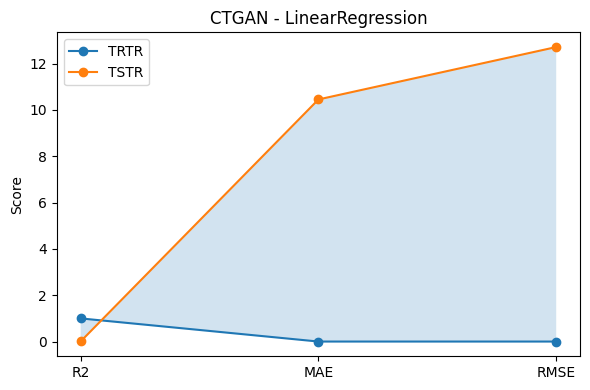

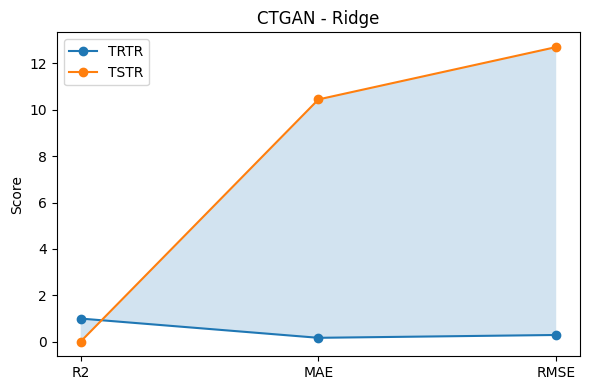

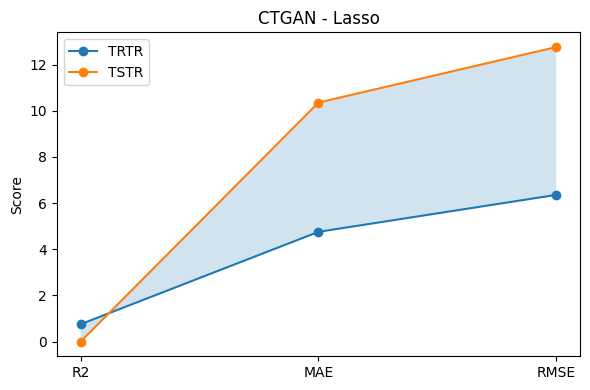

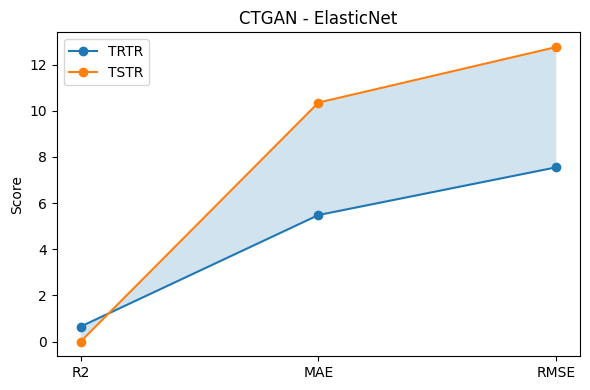

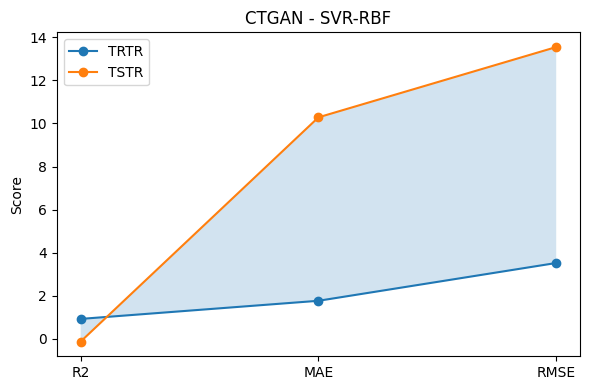

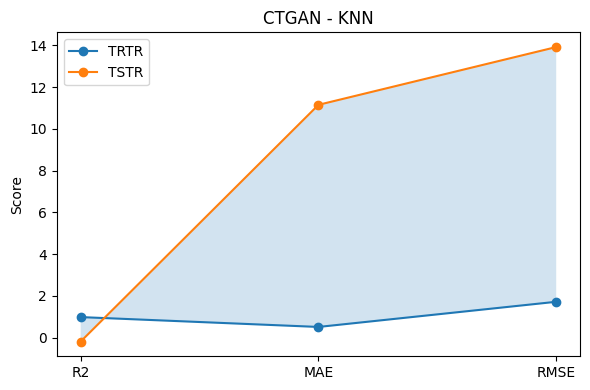

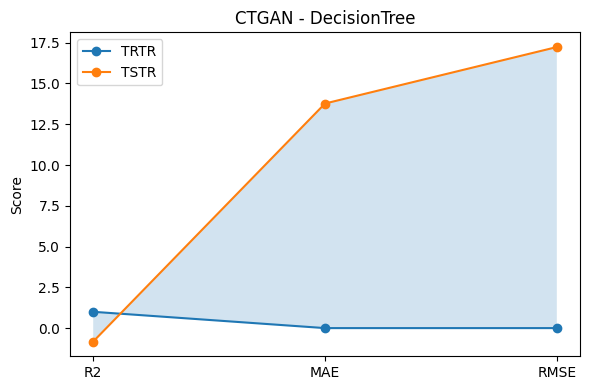

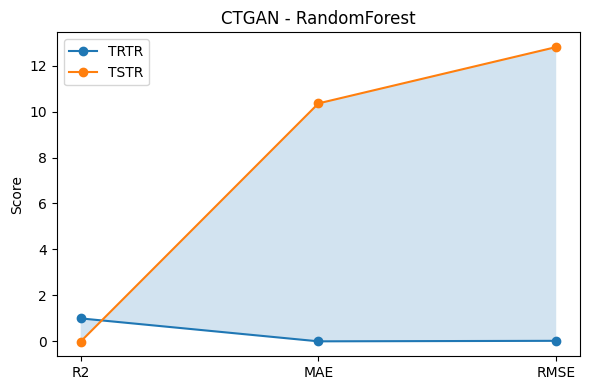

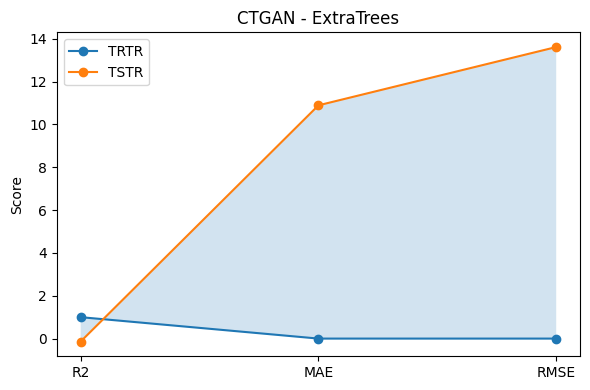

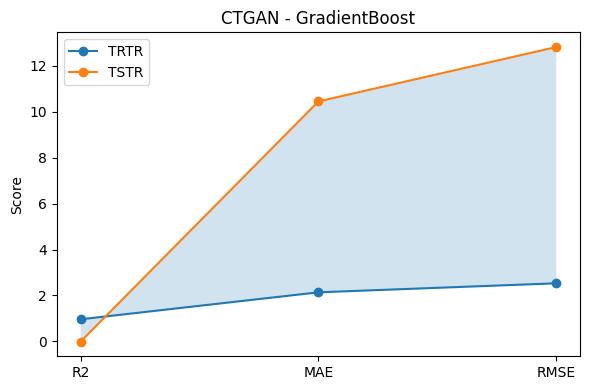

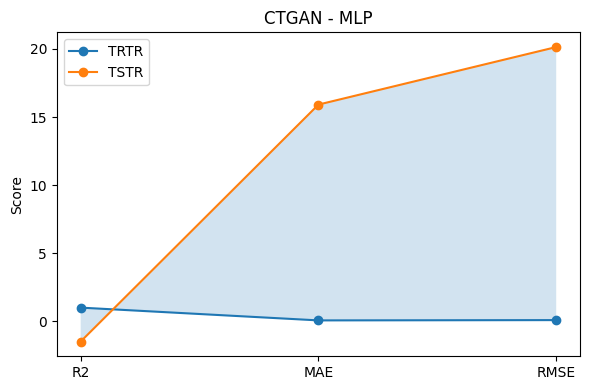

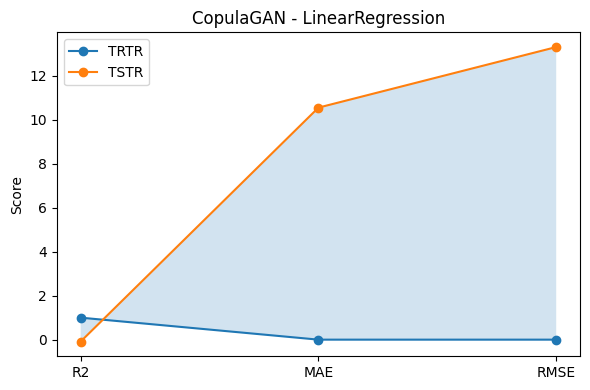

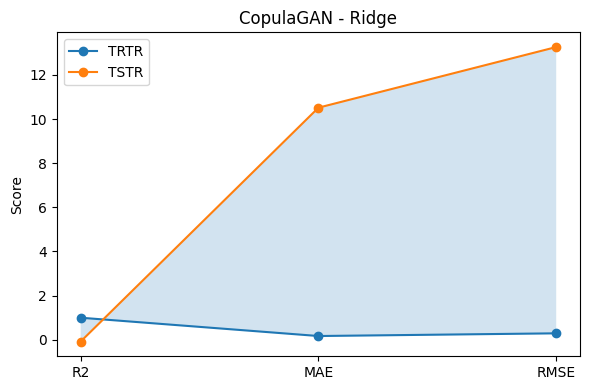

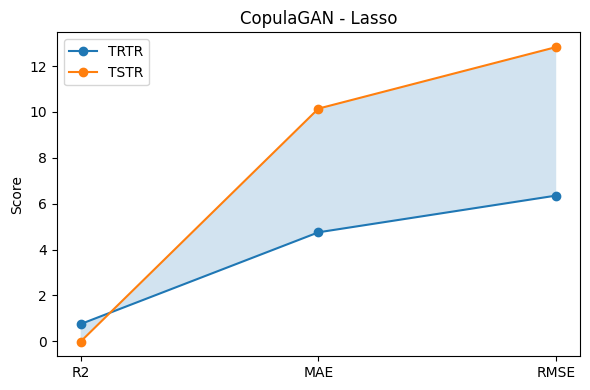

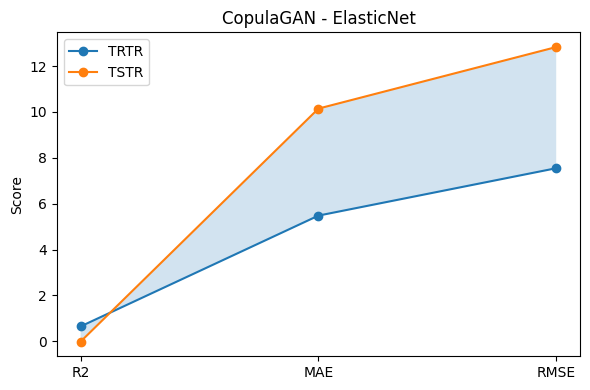

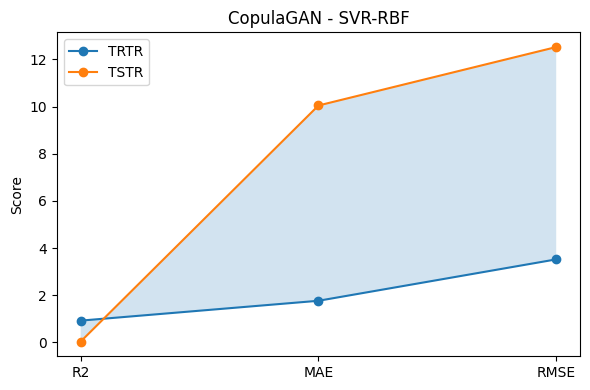

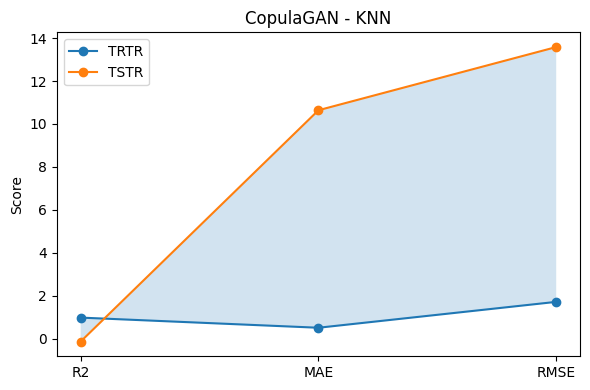

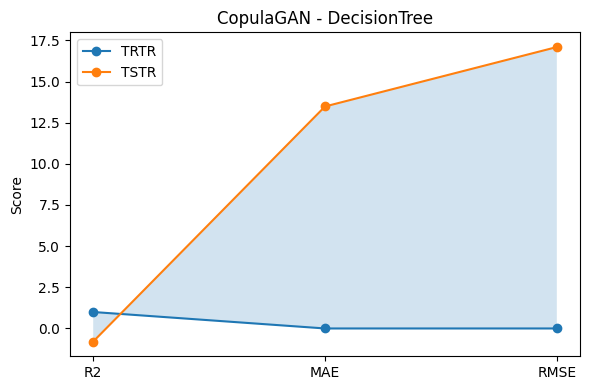

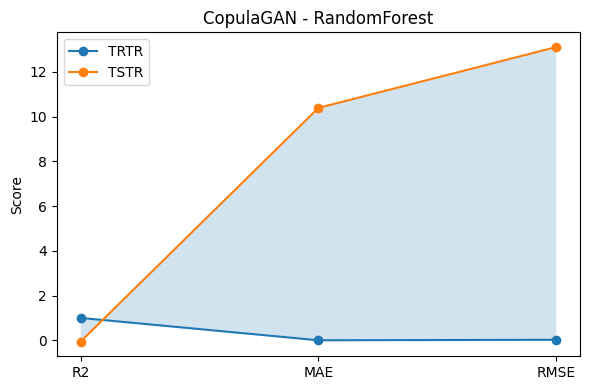

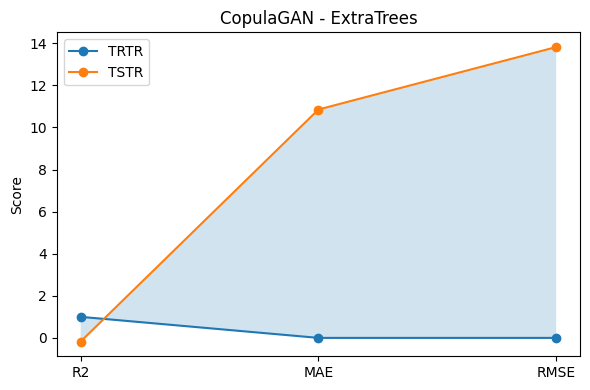

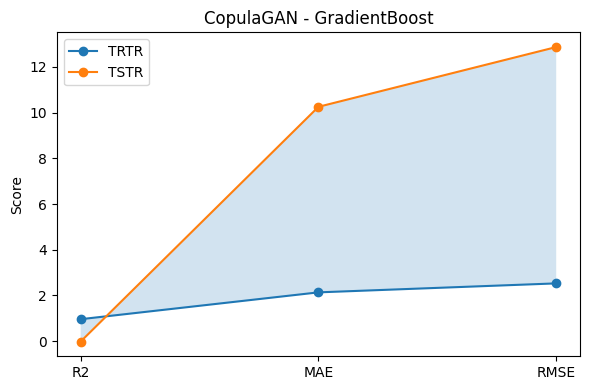

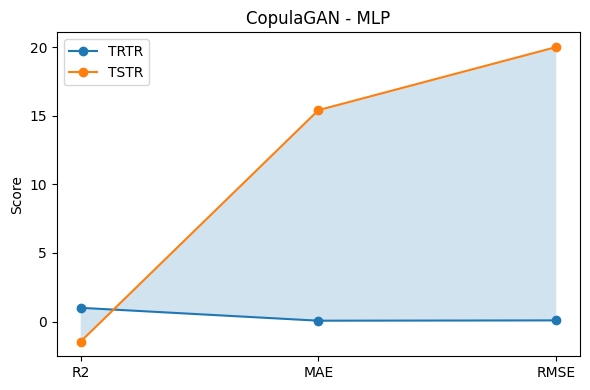

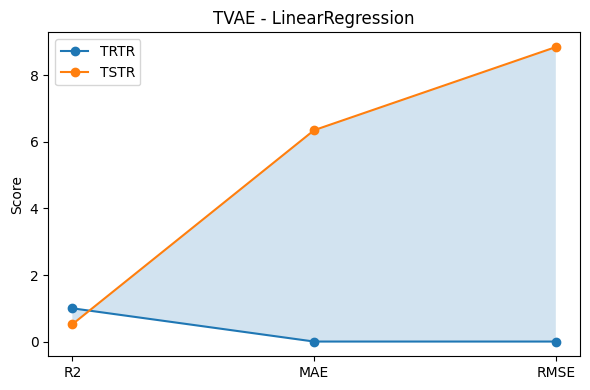

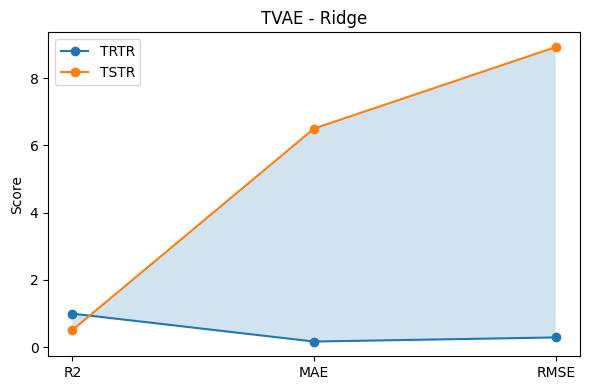

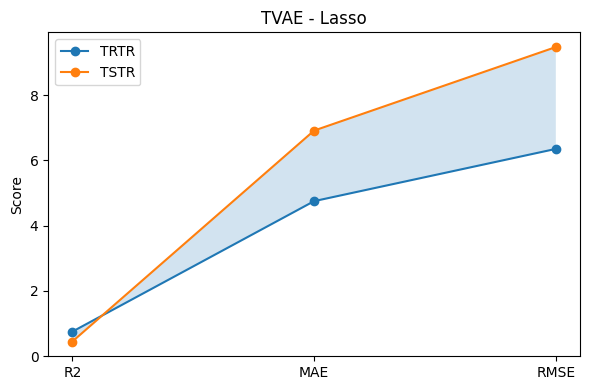

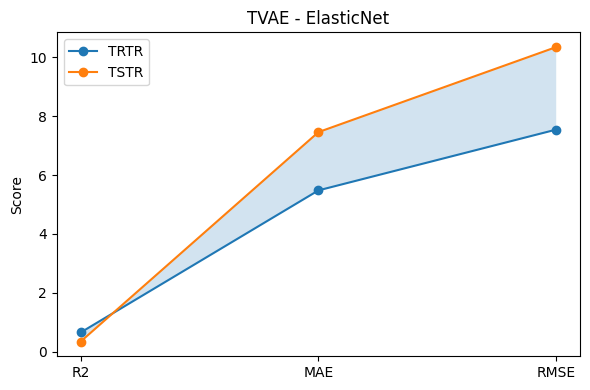

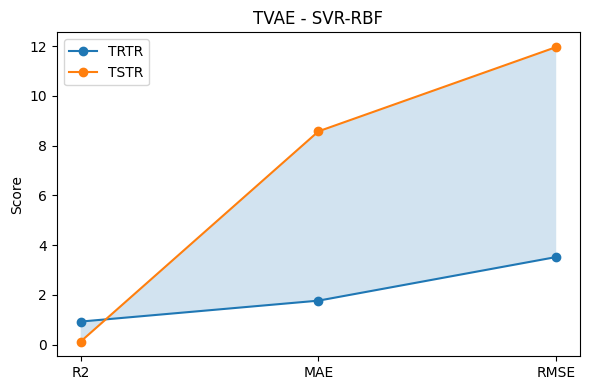

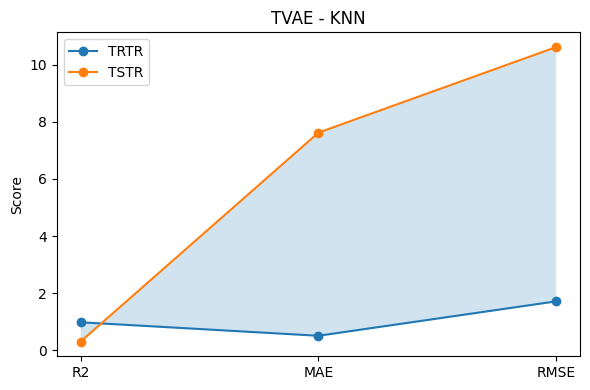

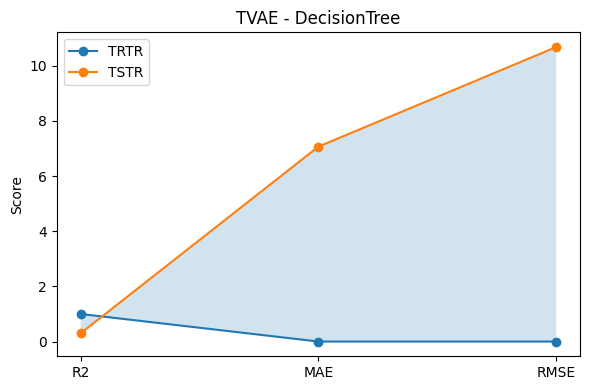

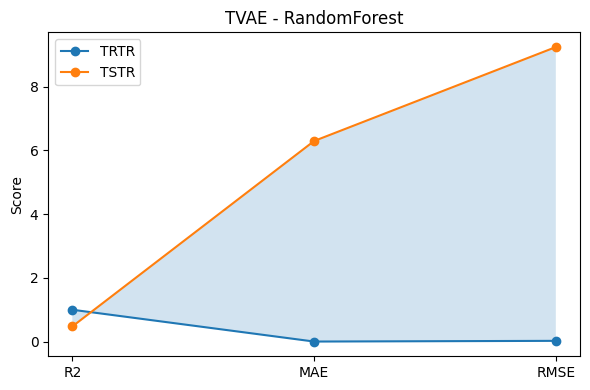

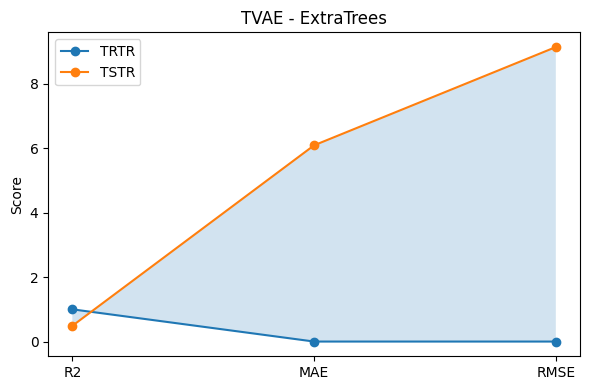

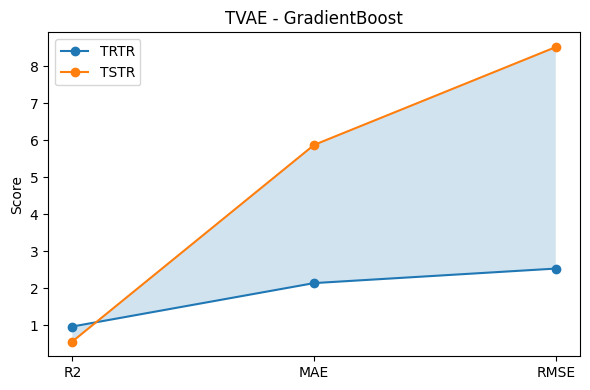

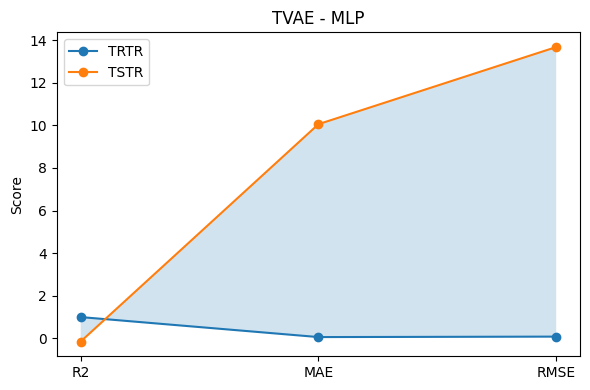

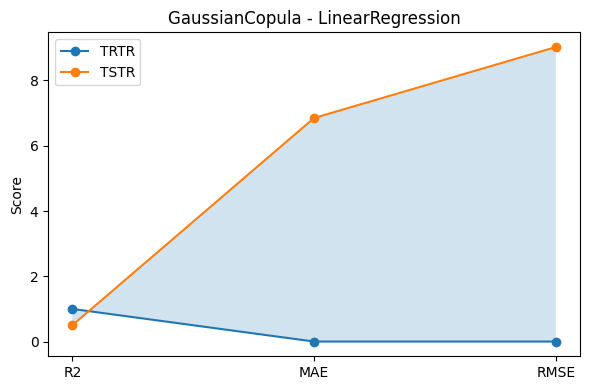

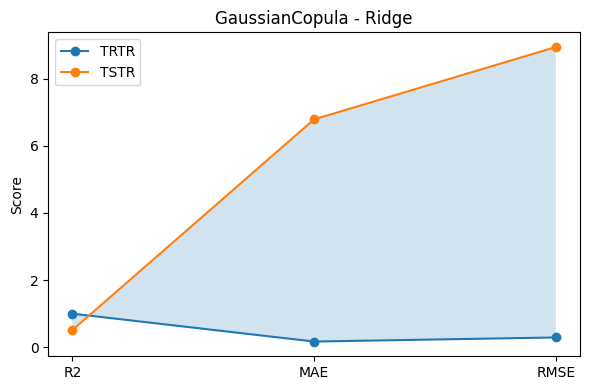

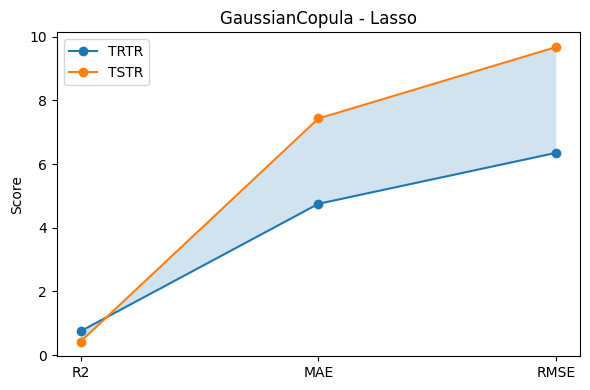

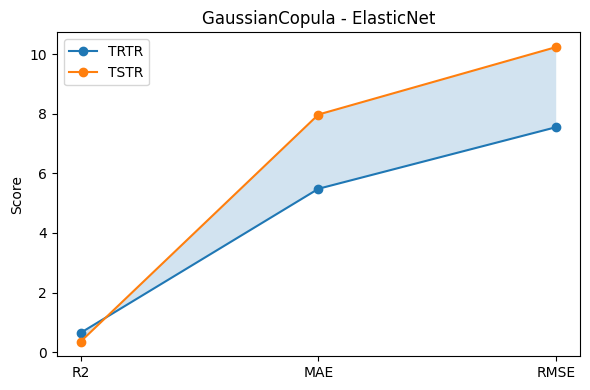

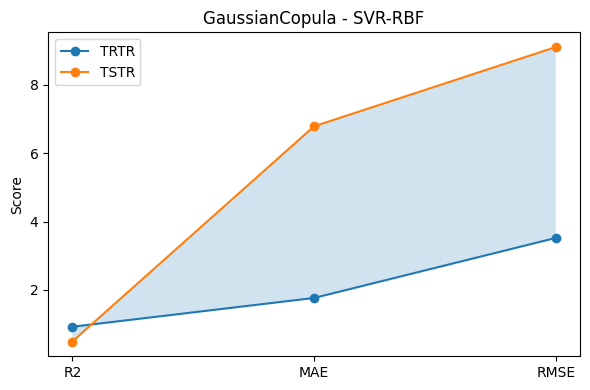

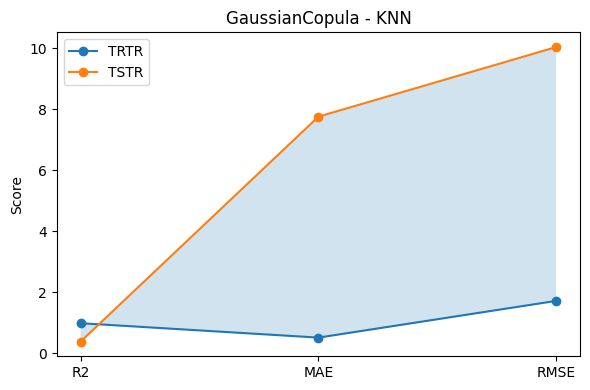

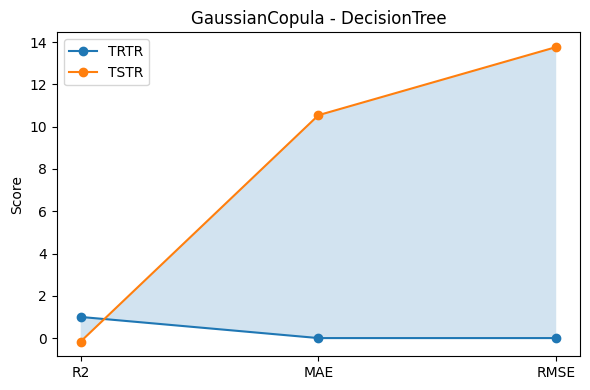

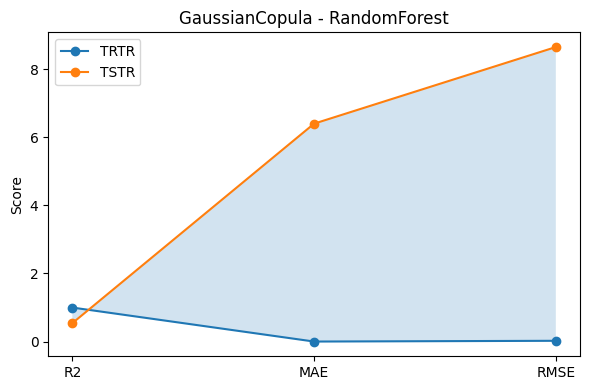

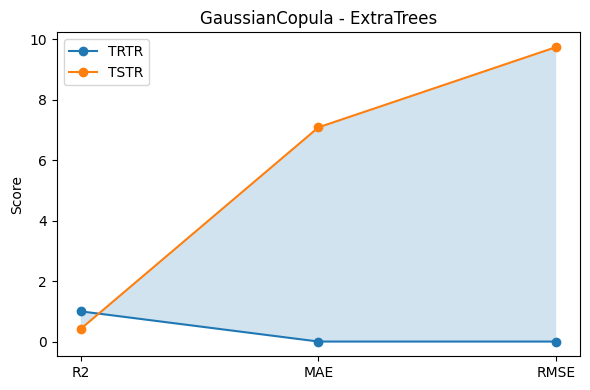

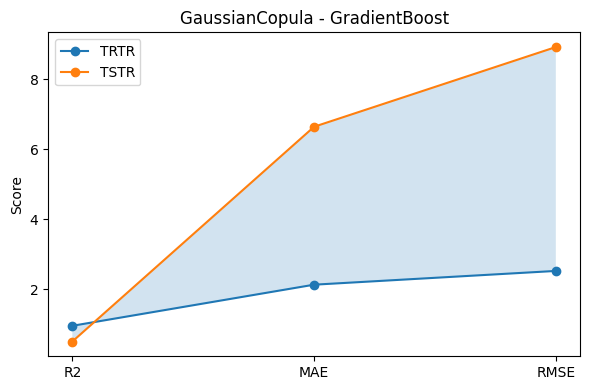

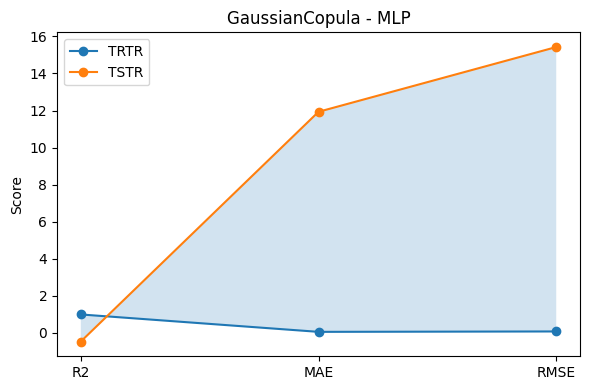

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

label_col = "price"
generators = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

def get_preprocessor(df):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in df.columns if c not in num_cols]

    return ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ])

def evaluate_models(train_df, test_df, label_col, models):
    X_train = train_df.drop(columns=[label_col])
    y_train = train_df[label_col].astype(float)

    X_test = test_df.drop(columns=[label_col])
    y_test = test_df[label_col].astype(float)

    pre = get_preprocessor(X_train)

    results = []
    for name, model in models.items():
        pipe = Pipeline([("prep", pre), ("model", clone(model))])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        results.append({
            "Model": name,
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "MAE": mean_absolute_error(y_test, pred),
            "R2": r2_score(y_test, pred)
        })

    return pd.DataFrame(results)

def plot_simple(trtr, tstr, name):
    metrics = ["R2", "MAE", "RMSE"]
    metrics = [m for m in metrics if m in trtr.columns]

    trtr = trtr.set_index("Model")
    tstr = tstr.set_index("Model")

    for model in trtr.index:
        if model not in tstr.index:
            continue

        a = trtr.loc[model][metrics].values
        b = tstr.loc[model][metrics].values
        x = np.arange(len(metrics))

        plt.figure(figsize=(6, 4))
        plt.plot(x, a, marker="o", label="TRTR")
        plt.plot(x, b, marker="o", label="TSTR")
        plt.fill_between(x, a, b, alpha=0.2)

        plt.xticks(x, metrics)
        plt.title(f"{name} - {model}")
        plt.ylabel("Score")
        plt.legend()
        plt.tight_layout()
        plt.show()

trtr_results = evaluate_models(data, data, label_col, models)

for gen in generators:
    tstr_results = evaluate_models(
        synthetic_datasets[gen][[c for c in data.columns if c in synthetic_datasets[gen].columns]],
        data,
        label_col,
        models
    )
    plot_simple(trtr_results, tstr_results, gen)


# 5 Statistical similarity tests 

,Model,Mean Error %,Std Error %
3,GaussianCopula,3.706453,3.422963
1,CopulaGAN,6.679559,5.983461
0,CTGAN,7.792363,11.130659
2,TVAE,19.159839,32.912762


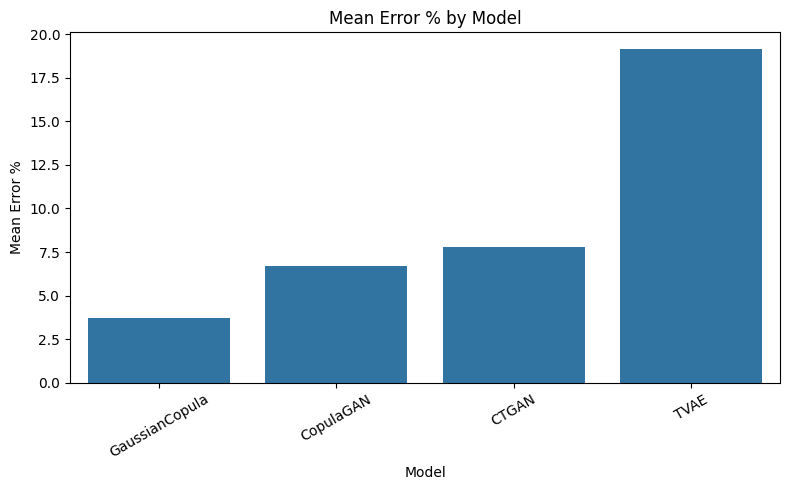

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "price"

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

results = []

for m in model_order:
    real = data[num_cols]
    synth = synthetic_datasets[m][num_cols]

    mean_err = ((synth.mean() - real.mean()).abs() / real.mean().abs()) * 100
    std_err = ((synth.std() - real.std()).abs() / real.std().abs()) * 100

    results.append({
        "Model": m,
        "Mean Error %": mean_err.mean(),
        "Std Error %": std_err.mean()
    })

summary = pd.DataFrame(results).sort_values("Mean Error %")

display(summary)

plt.figure(figsize=(8,5))
sns.barplot(data=summary, x="Model", y="Mean Error %")
plt.title("Mean Error % by Model")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

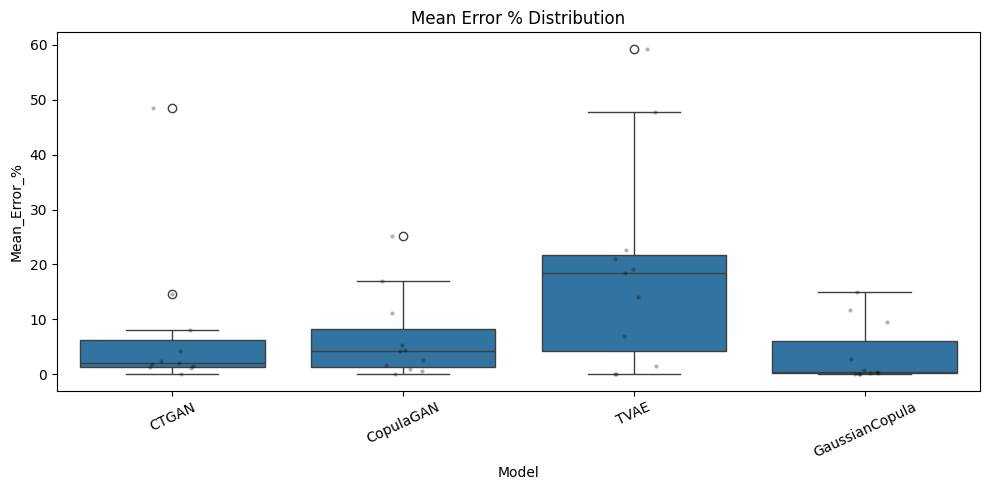

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

dist_df = pd.concat([
    feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
    for m in model_order if m in feature_error_by_model
]).dropna()

plt.figure(figsize=(10,5))
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.3, size=3)

plt.title("Mean Error % Distribution")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

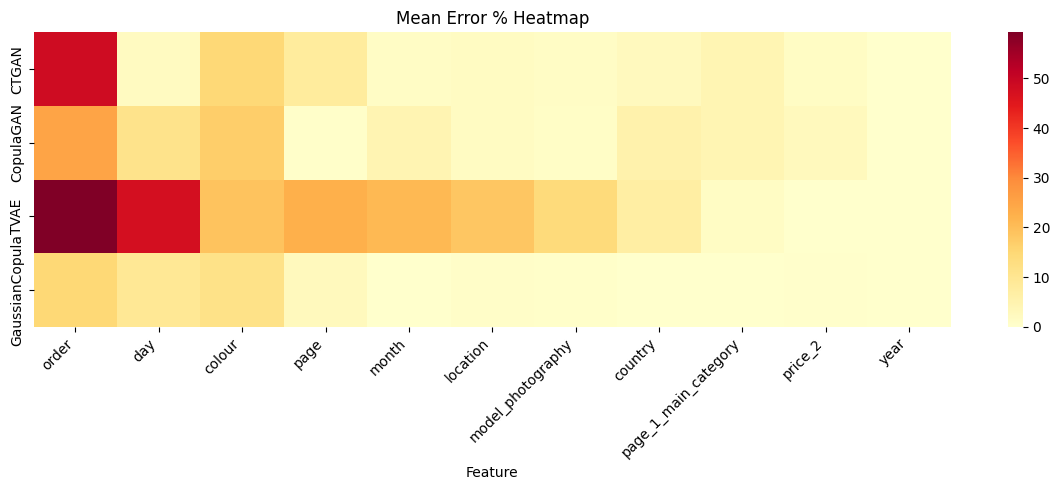

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order if m in feature_error_by_model
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

top_features = heatmap_df.mean().sort_values(ascending=False).head(20).index
heatmap_df = heatmap_df[top_features]

plt.figure(figsize=(12,5))
sns.heatmap(heatmap_df, cmap="YlOrRd")
plt.title("Mean Error % Heatmap")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

,Model,Avg Diff
1,CopulaGAN,140.818182
0,CTGAN,161.090909
3,GaussianCopula,201.090909
2,TVAE,333.000000


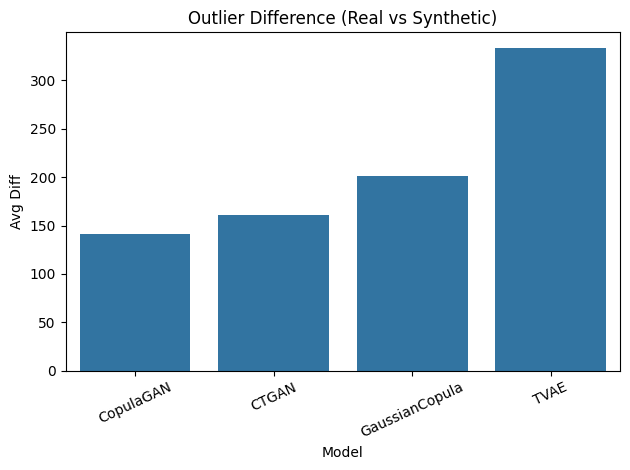

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "price"

num_cols = data.select_dtypes(include=["number"]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

def outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()

real_counts = {c: outliers(data[c]) for c in num_cols}

rows = []
for m in model_order:
    synth = synthetic_datasets[m][num_cols]
    diff = [(real_counts[c] - outliers(synth[c])) for c in num_cols]
    diff = [abs(d) for d in diff]

    rows.append({
        "Model": m,
        "Avg Diff": sum(diff)/len(diff)
    })

df = pd.DataFrame(rows).sort_values("Avg Diff")

display(df)

sns.barplot(data=df, x="Model", y="Avg Diff")
plt.title("Outlier Difference (Real vs Synthetic)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 6. Cosine Similarity with Hungraian Mapping

In [33]:
import numpy as np
import pandas as pd

target_col = "price"

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

def normalize(X):
    X = np.asarray(X, dtype=float)
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)

real = normalize(data[num_cols].values)

results = []

for name, synth_df in synthetic_datasets.items():
    synth = normalize(synth_df[num_cols].values)

    sim = real @ synth.T

    results.append({
        "Model": name,
        "Avg Cosine": sim.mean(),
        "Max Cosine": sim.max()
    })

    print(f"\n{name} sample (first 5x5):")
    print(pd.DataFrame(sim[:5, :5]))

summary = pd.DataFrame(results).sort_values("Avg Cosine", ascending=False)

display(summary)


CTGAN sample (first 5x5):
          0         1         2         3         4
0  0.999994  0.999975  0.999990  0.999993  0.999941
1  0.999982  0.999976  0.999986  0.999992  0.999958
2  0.999975  0.999991  0.999985  0.999963  0.999973
3  0.999987  0.999947  0.999974  0.999994  0.999906
4  0.999997  0.999957  0.999986  0.999982  0.999911

CopulaGAN sample (first 5x5):
          0         1         2         3         4
0  0.999957  0.999965  0.999956  0.999988  0.999975
1  0.999963  0.999973  0.999964  0.999977  0.999968
2  0.999985  0.999987  0.999984  0.999947  0.999994
3  0.999924  0.999937  0.999924  0.999996  0.999950
4  0.999936  0.999944  0.999938  0.999991  0.999962

TVAE sample (first 5x5):
          0         1         2         3         4
0  0.999965  0.999947  0.999993  0.999997  0.999956
1  0.999973  0.999943  0.999978  0.999990  0.999961
2  0.999990  0.999989  0.999974  0.999968  0.999984
3  0.999939  0.999910  0.999986  0.999993  0.999924
4  0.999940  0.999928  0.999996 

,Model,Avg Cosine,Max Cosine
2,TVAE,0.999939,1.0
0,CTGAN,0.999933,1.0
3,GaussianCopula,0.999929,1.0
1,CopulaGAN,0.999926,1.0


In [34]:
import numpy as np

target_col = "price"

num_cols = data.select_dtypes(include=["number"]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

def normalize(X):
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)

real = normalize(data[num_cols].values)

for name, synth_df in synthetic_datasets.items():
    synth = normalize(synth_df[num_cols].values)

    sim = real @ synth.T
    best_idx = sim.argmax(axis=1)
    best_sim = sim.max(axis=1)

    top = np.argsort(best_sim)[-10:][::-1]

    print(f"\n{name} Top Matches:")
    for i in top:
        print(f"R{i+1} -> S{best_idx[i]+1} | sim={best_sim[i]:.4f}")


CTGAN Top Matches:
R335 -> S3820 | sim=1.0000
R3403 -> S1538 | sim=1.0000
R1753 -> S4057 | sim=1.0000
R2430 -> S3280 | sim=1.0000
R3837 -> S2391 | sim=1.0000
R2081 -> S4617 | sim=1.0000
R517 -> S3751 | sim=1.0000
R3597 -> S4617 | sim=1.0000
R4204 -> S4440 | sim=1.0000
R4350 -> S3879 | sim=1.0000

CopulaGAN Top Matches:
R2135 -> S283 | sim=1.0000
R713 -> S283 | sim=1.0000
R910 -> S3573 | sim=1.0000
R3231 -> S2875 | sim=1.0000
R4253 -> S4797 | sim=1.0000
R556 -> S2745 | sim=1.0000
R585 -> S4083 | sim=1.0000
R1984 -> S1362 | sim=1.0000
R3280 -> S1085 | sim=1.0000
R3709 -> S4083 | sim=1.0000

TVAE Top Matches:
R36 -> S2117 | sim=1.0000
R1447 -> S1877 | sim=1.0000
R4324 -> S1620 | sim=1.0000
R626 -> S1826 | sim=1.0000
R713 -> S229 | sim=1.0000
R2135 -> S229 | sim=1.0000
R3908 -> S4629 | sim=1.0000
R4604 -> S3793 | sim=1.0000
R2840 -> S4369 | sim=1.0000
R3954 -> S464 | sim=1.0000

GaussianCopula Top Matches:
R170 -> S4491 | sim=1.0000
R737 -> S173 | sim=1.0000
R729 -> S3337 | sim=1.0000
R39

In [35]:
import numpy as np
from scipy.optimize import linear_sum_assignment

target_col = "price"

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

def normalize(X):
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)

real = normalize(data[num_cols].values)

for name, synth_df in synthetic_datasets.items():
    synth = normalize(synth_df[num_cols].values)

    sim = real @ synth.T
    cost = 1 - sim

    r, c = linear_sum_assignment(cost)
    sims = sim[r, c]

    print(f"\n{name} Avg Similarity: {sims.mean():.4f}")

    top = np.argsort(sims)[-10:][::-1]
    for i in top:
        print(f"R{r[i]+1} <-> S{c[i]+1} | sim={sims[i]:.4f}")


CTGAN Avg Similarity: 1.0000
R1753 <-> S4057 | sim=1.0000
R2430 <-> S3280 | sim=1.0000
R2081 <-> S4617 | sim=1.0000
R4204 <-> S4440 | sim=1.0000
R3701 <-> S193 | sim=1.0000
R877 <-> S1783 | sim=1.0000
R3629 <-> S3519 | sim=1.0000
R3052 <-> S3061 | sim=1.0000
R3271 <-> S3158 | sim=1.0000
R1908 <-> S3820 | sim=1.0000

CopulaGAN Avg Similarity: 1.0000
R713 <-> S283 | sim=1.0000
R585 <-> S4083 | sim=1.0000
R3297 <-> S4194 | sim=1.0000
R1116 <-> S1083 | sim=1.0000
R1948 <-> S4633 | sim=1.0000
R4949 <-> S3573 | sim=1.0000
R3001 <-> S958 | sim=1.0000
R1074 <-> S3350 | sim=1.0000
R1799 <-> S3732 | sim=1.0000
R4025 <-> S2173 | sim=1.0000

TVAE Avg Similarity: 1.0000
R2136 <-> S914 | sim=1.0000
R4842 <-> S2077 | sim=1.0000
R3045 <-> S3314 | sim=1.0000
R4458 <-> S3729 | sim=1.0000
R829 <-> S430 | sim=1.0000
R160 <-> S1375 | sim=1.0000
R660 <-> S3215 | sim=1.0000
R4191 <-> S3091 | sim=1.0000
R2075 <-> S244 | sim=1.0000
R1289 <-> S130 | sim=1.0000

GaussianCopula Avg Similarity: 1.0000
R170 <-> S4

In [38]:
import pandas as pd
import numpy as np

target_col = "price"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

output_file = "matching_results_shopping.xlsx"

summary = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for name in model_order:
        if name not in synthetic_datasets:
            continue

        real = data[num_cols].values
        synth = synthetic_datasets[name][num_cols].values

        real = real / (np.linalg.norm(real, axis=1, keepdims=True) + 1e-12)
        synth = synth / (np.linalg.norm(synth, axis=1, keepdims=True) + 1e-12)

        sim = real @ synth.T
        best_idx = sim.argmax(axis=1)
        best_sim = sim.max(axis=1)

        df = pd.DataFrame({
            "Real": [f"R{i+1}" for i in range(len(best_idx))],
            "Synthetic": [f"S{j+1}" for j in best_idx],
            "Cosine": best_sim
        })

        df.to_excel(writer, sheet_name=name, index=False)

        summary.append({
            "Model": name,
            "Avg Cosine": best_sim.mean(),
            "Max Cosine": best_sim.max()
        })

    summary_df = pd.DataFrame(summary).sort_values("Avg Cosine", ascending=False)
    summary_df.to_excel(writer, sheet_name="Summary", index=False)

print("Saved:", output_file)
display(summary_df)

Saved: matching_results_shopping.xlsx


,Model,Avg Cosine,Max Cosine
1,CopulaGAN,0.999999,1.0
0,CTGAN,0.999998,1.0
3,GaussianCopula,0.999997,1.0
2,TVAE,0.999977,1.0


# 7. Mahalanobis distance with Hungrain Mapping  

In [37]:
import numpy as np

target_col = "price"

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

X = data[num_cols].dropna().values

mu = X.mean(axis=0)
cov = np.cov(X, rowvar=False)
inv_cov = np.linalg.pinv(cov)

print("Fitted Mahalanobis params")
print("Features:", len(num_cols))

for name, synth_df in synthetic_datasets.items():
    Y = synth_df[num_cols].dropna().values
    diff = Y - mu
    d = np.sqrt(np.sum(diff @ inv_cov * diff, axis=1))

    print(f"\n{name}")
    print("Avg distance:", d.mean())
    print("Min distance:", d.min())
    print("Max distance:", d.max())

Fitted Mahalanobis params
Features: 11

CTGAN
Avg distance: 3.15408278535718
Min distance: 1.4815110954015949
Max distance: 8.719279856211797

CopulaGAN
Avg distance: 3.2128956629650047
Min distance: 1.5070388897342242
Max distance: 11.368313013328393

TVAE
Avg distance: 2.834614262178271
Min distance: 1.7247049662073188
Max distance: 4.017698480889007

GaussianCopula
Avg distance: 3.155406839447169
Min distance: 1.544649816401217
Max distance: 7.1664986821650025


In [39]:
import pandas as pd
import numpy as np

target_col = "price"

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

X = data[num_cols].dropna().values
mu = X.mean(axis=0)
inv_cov = np.linalg.pinv(np.cov(X, rowvar=False))

rows = []

for name in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]:
    if name not in synthetic_datasets:
        continue

    Y = synthetic_datasets[name][num_cols].dropna().values
    diff = Y - mu
    d = np.sqrt(np.sum(diff @ inv_cov * diff, axis=1))

    rows.append({
        "Model": name,
        "Mean": d.mean(),
        "Median": np.median(d),
        "Std": d.std(),
        "Min": d.min(),
        "Max": d.max()
    })

summary = pd.DataFrame(rows).sort_values("Mean")

print("Mahalanobis distance (lower is better):")
display(summary)

Mahalanobis distance (lower is better):


,Model,Mean,Median,Std,Min,Max
2,TVAE,2.834614,2.825335,0.405838,1.724705,4.017698
0,CTGAN,3.154083,3.117814,0.663524,1.481511,8.719280
3,GaussianCopula,3.155407,3.126009,0.617944,1.544650,7.166499
1,CopulaGAN,3.212896,3.112781,0.754150,1.507039,11.368313


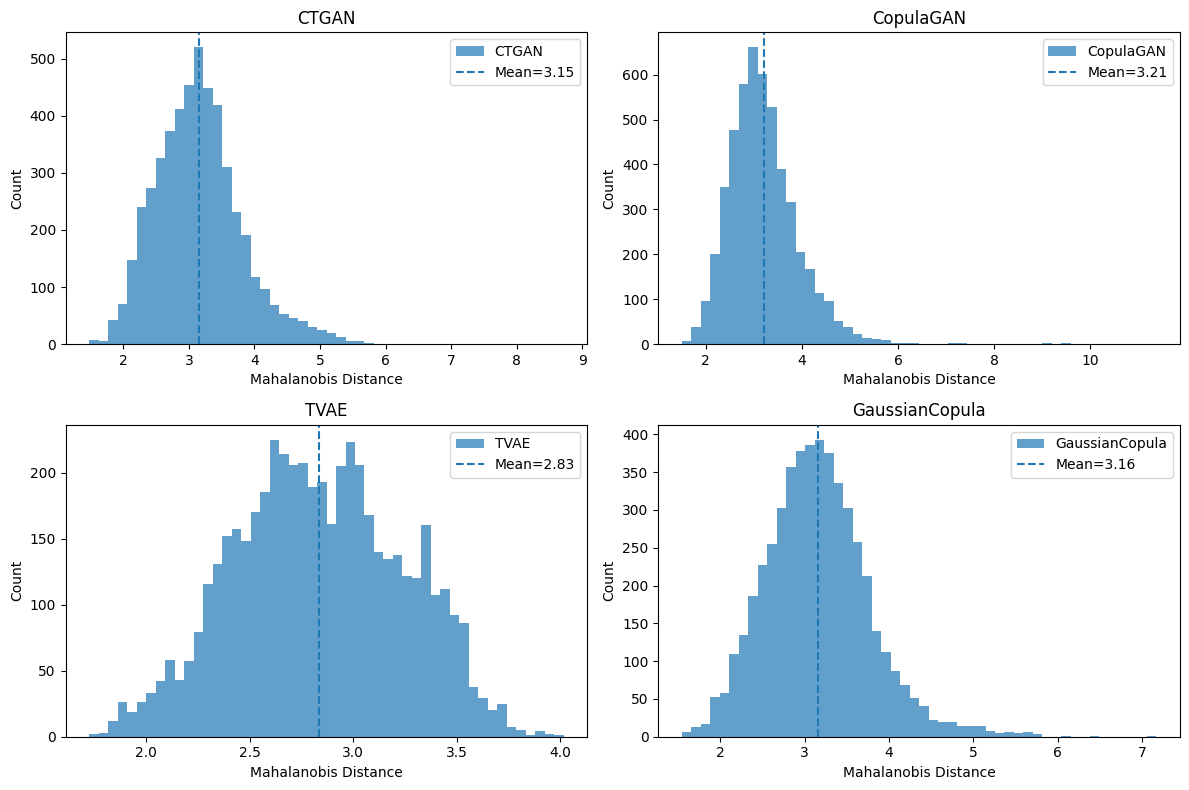

In [44]:
import numpy as np
import matplotlib.pyplot as plt

target_col = "price"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

X = data[num_cols].dropna().values
mu = X.mean(axis=0)
inv_cov = np.linalg.pinv(np.cov(X, rowvar=False))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, name in zip(axes, model_order):
    if name not in synthetic_datasets:
        ax.axis("off")
        continue

    Y = synthetic_datasets[name][num_cols].dropna().values
    diff = Y - mu
    d = np.sqrt(np.sum(diff @ inv_cov * diff, axis=1))

    ax.hist(d, bins=50, alpha=0.7, label=name)
    ax.axvline(d.mean(), linestyle="--", label=f"Mean={d.mean():.2f}")

    ax.set_title(name)
    ax.set_xlabel("Mahalanobis Distance")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

In [45]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

target_col = "price"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

real = data[num_cols].values

cov = np.cov(real, rowvar=False)
inv_cov = np.linalg.pinv(cov)

rows = []

for name in model_order:
    if name not in synthetic_datasets:
        continue

    synth = synthetic_datasets[name][num_cols].values

    D = cdist(real, synth, metric="mahalanobis", VI=inv_cov)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10)

    r, c = linear_sum_assignment(D)
    d = D[r, c]

    rows.append({
        "Model": name,
        "Mean": d.mean(),
        "Median": np.median(d),
        "Std": d.std(),
        "Max": d.max()
    })

summary = pd.DataFrame(rows).sort_values("Mean")

print("Hungarian Mahalanobis (lower is better):")
display(summary)

Hungarian Mahalanobis (lower is better):


,Model,Mean,Median,Std,Max
0,CTGAN,1.567794,1.384053,0.917086,13.181501
1,CopulaGAN,1.581511,1.419677,0.899975,6.660601
3,GaussianCopula,1.587593,1.508970,0.685882,9.993878
2,TVAE,2.384212,2.208124,1.478274,14.217416


In [46]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

target_col = "price"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

real = data[num_cols].values
inv_cov = np.linalg.pinv(np.cov(real, rowvar=False))

rows = []

for name in model_order:
    if name not in synthetic_datasets:
        continue

    synth = synthetic_datasets[name][num_cols].values

    D = cdist(real, synth, metric="mahalanobis", VI=inv_cov)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10)

    # greedy match
    used_r = set()
    used_s = set()
    pairs = []

    flat_idx = np.argsort(D, axis=None)

    for idx in flat_idx:
        i = idx // D.shape[1]
        j = idx % D.shape[1]
        if i not in used_r and j not in used_s:
            used_r.add(i)
            used_s.add(j)
            pairs.append(D[i, j])
        if len(pairs) == min(D.shape):
            break

    pairs = np.array(pairs)

    rows.append({
        "Model": name,
        "Greedy Mean": pairs.mean(),
        "Greedy Total": pairs.sum()
    })

summary = pd.DataFrame(rows).sort_values("Greedy Mean")

print("Greedy Mahalanobis (lower is better):")
display(summary)

Greedy Mahalanobis (lower is better):


,Model,Greedy Mean,Greedy Total
0,CTGAN,1.712434,8562.171827
3,GaussianCopula,1.722005,8610.022691
1,CopulaGAN,1.741369,8706.847142
2,TVAE,2.525588,12627.940906


In [47]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

target_col = "price"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

real = data[num_cols].values
inv_cov = np.linalg.pinv(np.cov(real, rowvar=False))

mahalanobis_results = {}
rows = []

for name in model_order:
    if name not in synthetic_datasets:
        continue

    synth = synthetic_datasets[name][num_cols].values

    D = cdist(real, synth, metric="mahalanobis", VI=inv_cov)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10)

    r, c = linear_sum_assignment(D)
    d = D[r, c]

    mahalanobis_results[name] = {
        "row_ind": r,
        "col_ind": c,
        "distances": d,
        "avg_distance": d.mean()
    }

    rows.append({
        "Model": name,
        "Mean": d.mean(),
        "Median": np.median(d),
        "Std": d.std()
    })

summary = pd.DataFrame(rows).sort_values("Mean")

print("Mahalanobis Hungarian Matching (lower is better):")
display(summary)

Mahalanobis Hungarian Matching (lower is better):


,Model,Mean,Median,Std
0,CTGAN,1.567794,1.384053,0.917086
1,CopulaGAN,1.581511,1.419677,0.899975
3,GaussianCopula,1.587593,1.508970,0.685882
2,TVAE,2.384212,2.208124,1.478274


In [48]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

target_col = "price"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

real = data[num_cols].values
inv_cov = np.linalg.pinv(np.cov(real, rowvar=False))

mahalanobis_results = {}

for name in model_order:
    if name not in synthetic_datasets:
        continue

    synth = synthetic_datasets[name][num_cols].values

    D = cdist(real, synth, metric="mahalanobis", VI=inv_cov)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10)

    r, c = linear_sum_assignment(D)
    d = D[r, c]

    mahalanobis_results[name] = d

    print(f"{name}: avg distance = {d.mean():.4f}")

CTGAN: avg distance = 1.5678
CopulaGAN: avg distance = 1.5815
TVAE: avg distance = 2.3842
GaussianCopula: avg distance = 1.5876


In [49]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

target_col = "price"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

real = data[num_cols].values
inv_cov = np.linalg.pinv(np.cov(real, rowvar=False))

for name in model_order:
    if name not in synthetic_datasets:
        continue

    synth = synthetic_datasets[name][num_cols].values

    D = cdist(real, synth, metric="mahalanobis", VI=inv_cov)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10)

    r, c = linear_sum_assignment(D)
    d = D[r, c]

    mapping = dict(zip(r, zip(c, d)))

    print(f"\n{name} - First 20 matches:")
    for i in range(20):
        if i in mapping:
            j, dist = mapping[i]
            print(f"R{i+1} -> S{j+1} | d={dist:.4f}")
        else:
            print(f"R{i+1} -> No match")


CTGAN - First 20 matches:
R1 -> S1547 | d=0.9002
R2 -> S2416 | d=1.2814
R3 -> S4427 | d=1.4815
R4 -> S1916 | d=0.7081
R5 -> S3838 | d=1.7109
R6 -> S601 | d=1.1101
R7 -> S1385 | d=1.4070
R8 -> S3525 | d=1.4728
R9 -> S1431 | d=0.4542
R10 -> S4779 | d=3.9328
R11 -> S3563 | d=1.1115
R12 -> S4739 | d=1.3078
R13 -> S3961 | d=1.3233
R14 -> S4420 | d=0.3386
R15 -> S3259 | d=0.6618
R16 -> S4346 | d=1.9535
R17 -> S4265 | d=1.3964
R18 -> S895 | d=1.7161
R19 -> S3110 | d=1.2380
R20 -> S2768 | d=1.3924

CopulaGAN - First 20 matches:
R1 -> S4347 | d=1.9345
R2 -> S4496 | d=1.3656
R3 -> S4141 | d=1.2572
R4 -> S2832 | d=1.0919
R5 -> S486 | d=2.0898
R6 -> S1771 | d=0.5665
R7 -> S1842 | d=0.8707
R8 -> S468 | d=1.5201
R9 -> S1599 | d=0.1395
R10 -> S1361 | d=2.7140
R11 -> S4094 | d=1.8937
R12 -> S3484 | d=1.0628
R13 -> S4322 | d=1.7736
R14 -> S3735 | d=1.0171
R15 -> S274 | d=0.7264
R16 -> S3945 | d=1.2995
R17 -> S2265 | d=1.1641
R18 -> S1665 | d=0.9691
R19 -> S795 | d=1.8756
R20 -> S139 | d=1.2887

TVAE -

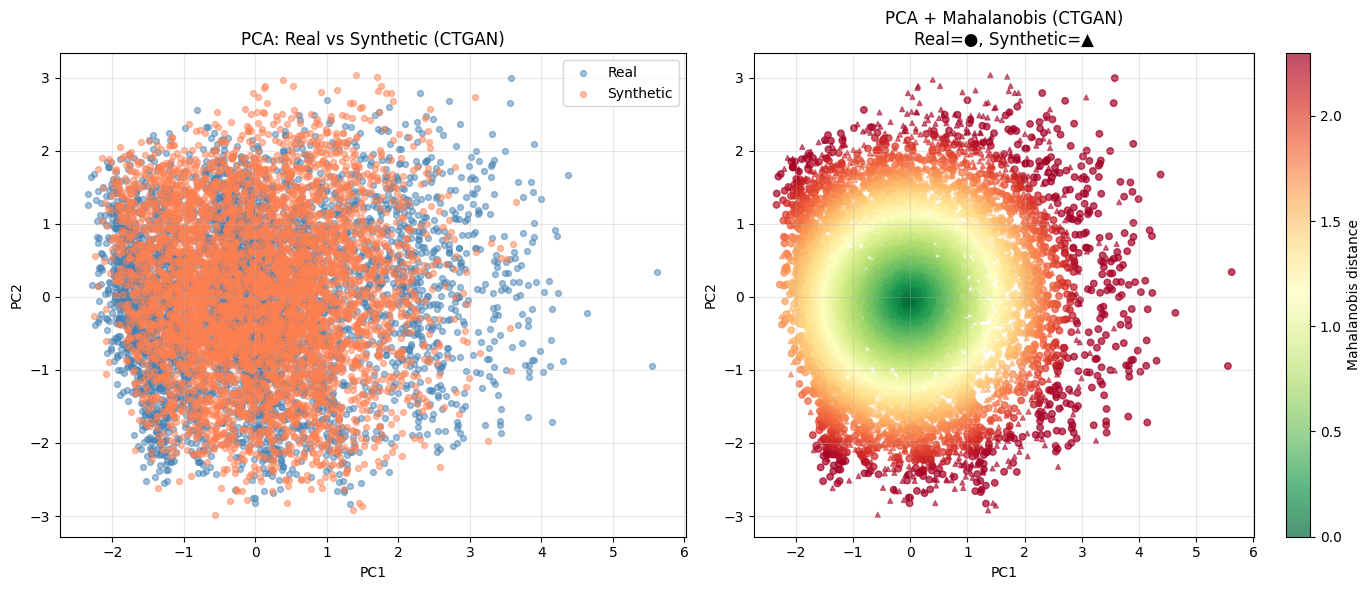

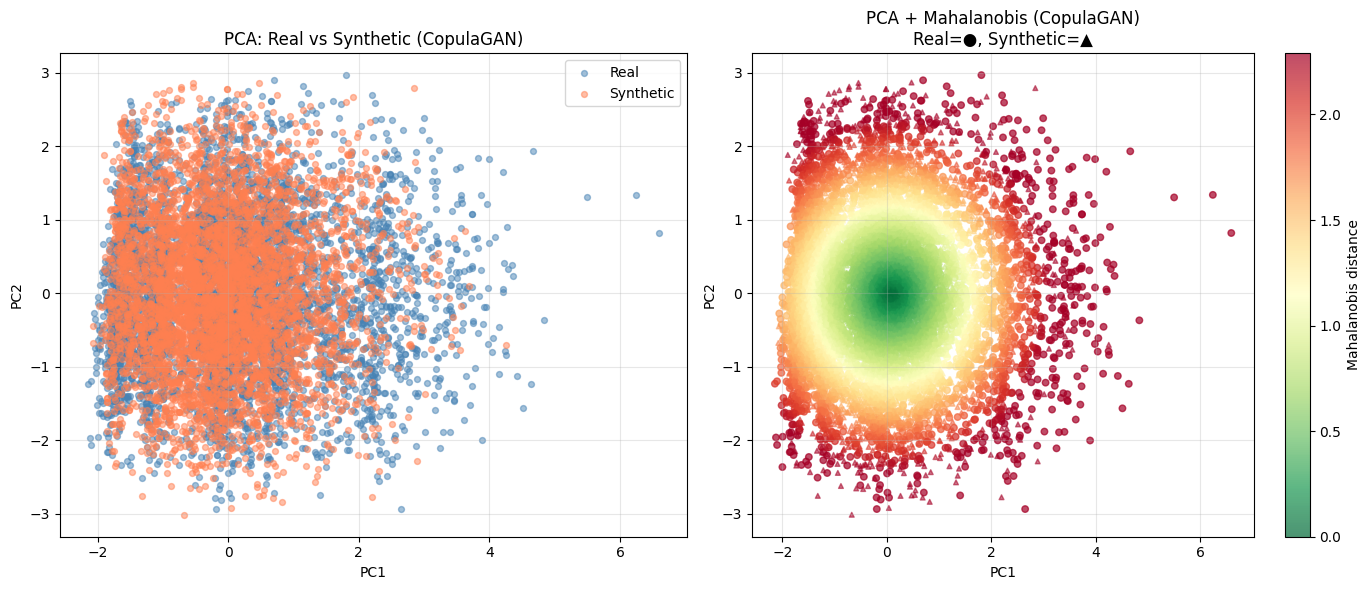

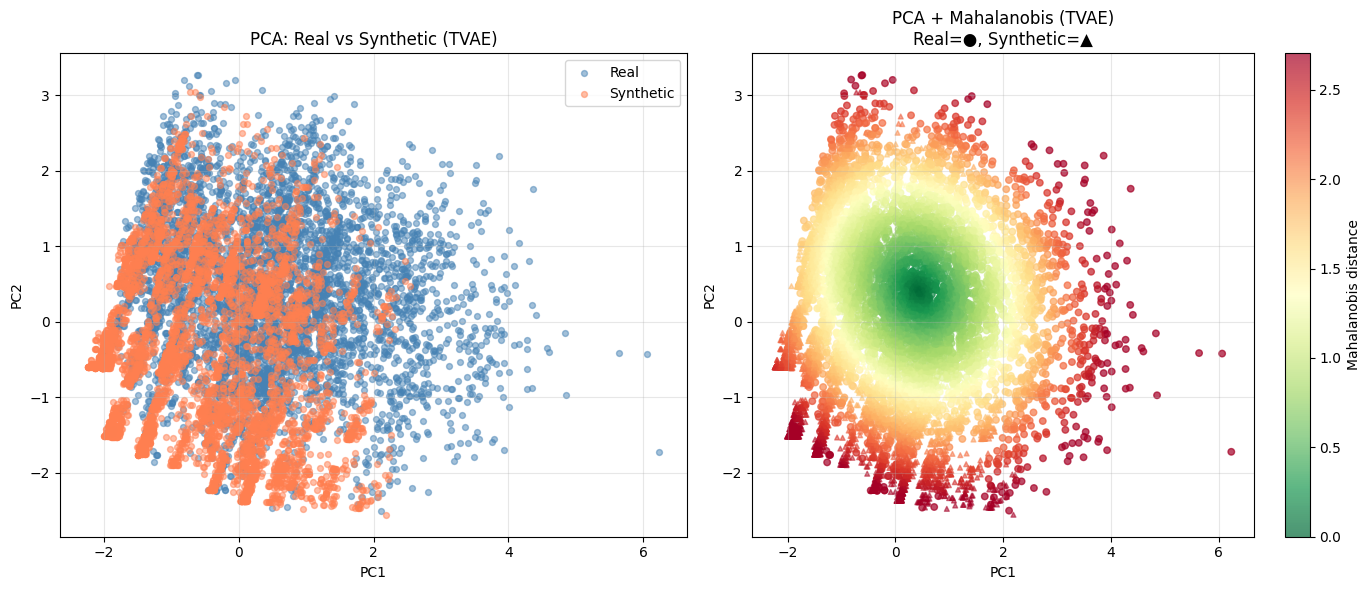

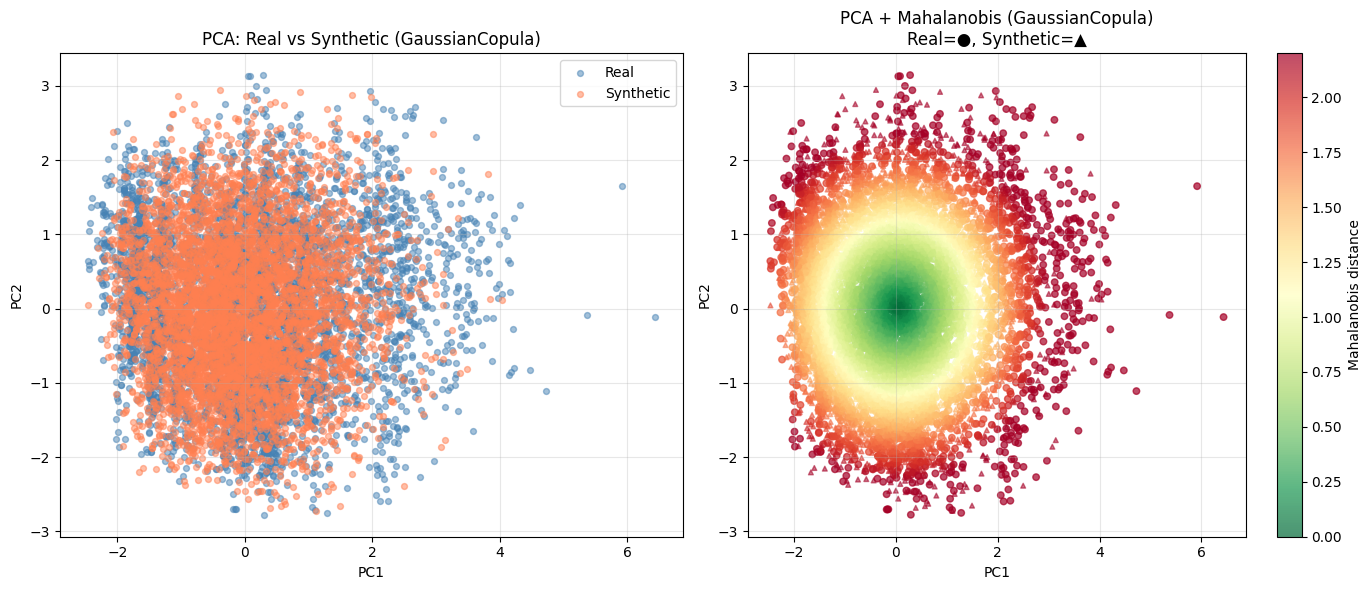

Metro PCA + Mahalanobis summary:


,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
3,GaussianCopula,1.276536,1.099056,-0.177480
1,CopulaGAN,1.258451,1.123467,-0.134984
0,CTGAN,1.255470,1.197885,-0.057585
2,TVAE,1.275297,1.663541,0.388244


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

target_col = "price"

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c not in ["ID", "Diabetes_binary", target_col]]

X_r = real_df[feature_cols].to_numpy(dtype=np.float64)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synthetic_datasets:
        print(f"{model_name} not found in synthetic_datasets, skipping.")
        continue

    synth_df = synthetic_datasets[model_name][real_df.columns].copy()
    X_s = synth_df[feature_cols].to_numpy(dtype=np.float64)
    X_s_s = scaler.transform(X_s)

    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = np.linalg.pinv(cov_z + reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
print("Metro PCA + Mahalanobis summary:")
display(summary_df)

In [53]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

target_col = "price"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

experiment_name = "Eshop_Price_Regression_Hungarian_Mahalanobis"

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

real = data[num_cols].values
inv_cov = np.linalg.pinv(np.cov(real, rowvar=False))

hungarian_results = {}

for name in model_order:
    if name not in synthetic_datasets:
        continue

    synth = synthetic_datasets[name][num_cols].values

    D = cdist(real, synth, metric="mahalanobis", VI=inv_cov)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10)

    r, c = linear_sum_assignment(D)
    d = D[r, c]

    hungarian_results[name] = {"row_ind": r, "col_ind": c, "distances": d}

output_file = f"{experiment_name}.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    summary = []

    for name in model_order:
        if name not in hungarian_results:
            continue

        r = hungarian_results[name]["row_ind"]
        c = hungarian_results[name]["col_ind"]
        d = hungarian_results[name]["distances"]

        df = pd.DataFrame({
            "Real": [f"R{i+1}" for i in r],
            "Synthetic": [f"S{j+1}" for j in c],
            "Mahalanobis_Distance": d
        })

        sheet_name = f"{experiment_name}_{name}"[:31]
        df.to_excel(writer, sheet_name=sheet_name, index=False)

        summary.append({
            "Model": name,
            "Mean_Distance": d.mean(),
            "Median_Distance": np.median(d),
            "Std_Distance": d.std()
        })

    pd.DataFrame(summary).sort_values("Mean_Distance").to_excel(
        writer, sheet_name="Summary", index=False
    )

print("Saved:", output_file)

Saved: Eshop_Price_Regression_Hungarian_Mahalanobis.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [54]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample_regression(model, X, y):
    y_pred = model.predict(X)
    return (y - y_pred) ** 2

def privacy_metrics_mia_regression(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    model.fit(X_train_s, y_train)

    loss_train = model_loss_per_sample_regression(model, X_train_s, y_train)
    loss_test = model_loss_per_sample_regression(model, X_test_s, y_test)

    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])

    fpr, tpr, _ = roc_curve(labels, scores)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {"AUC": auc, "Advantage": advantage, "TPR@FPR=0.01": tpr_001}

target_col = "price"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in num_cols if c != target_col]

real_df = data.copy()
X_train = real_df[feature_cols].values
y_train = real_df[target_col].values

results = []

for name in model_order:
    if name not in synthetic_datasets:
        continue

    synth_df = synthetic_datasets[name][real_df.columns].copy()
    X_test = synth_df[feature_cols].values
    y_test = synth_df[target_col].values

    model = Ridge(alpha=1.0)
    metrics = privacy_metrics_mia_regression(model, X_train, y_train, X_test, y_test)

    metrics["Model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values("AUC", ascending=False)

display(results_df)

,AUC,Advantage,TPR@FPR=0.01,Model
0,0.809520,0.4922,0.0316,CTGAN
1,0.804891,0.4926,0.0318,CopulaGAN
3,0.744694,0.3804,0.0146,GaussianCopula
2,0.587866,0.2128,0.0252,TVAE


In [55]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

target_col = "price"

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = X_train_s.mean(axis=0)
    cov = np.cov(X_train_s, rowvar=False) + 1e-6 * np.eye(X_train_s.shape[1])
    cov_inv = np.linalg.pinv(cov)

    md_train = np.sqrt(np.sum((X_train_s - mu) @ cov_inv * (X_train_s - mu), axis=1))
    md_test = np.sqrt(np.sum((X_test_s - mu) @ cov_inv * (X_test_s - mu), axis=1))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores)
    auc = roc_auc_score(labels, scores)
    adv = np.max(tpr - fpr)

    idx = max(0, np.searchsorted(fpr, 0.01) - 1)
    tpr_001 = tpr[idx] if idx < len(tpr) else np.nan

    return {
        "AUC": auc,
        "Advantage": adv,
        "TPR@FPR=0.01": tpr_001,
        "Train_MD_Mean": md_train.mean(),
        "Test_MD_Mean": md_test.mean()
    }

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in num_cols if c != target_col]

X_train = data[feature_cols].values

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

results = []
for name in model_order:
    if name not in synthetic_datasets:
        continue

    X_test = synthetic_datasets[name][feature_cols].values
    res = privacy_metrics_mia_mahalanobis(X_train, X_test)
    res["Model"] = name
    results.append(res)

df = pd.DataFrame(results).sort_values("AUC", ascending=False)

display(df)

,AUC,Advantage,TPR@FPR=0.01,Train_MD_Mean,Test_MD_Mean,Model
1,0.564880,0.1022,0.0226,3.059555,3.212894,CopulaGAN
3,0.557825,0.1102,0.0250,3.059555,3.155405,GaussianCopula
0,0.550939,0.0898,0.0216,3.059555,3.154081,CTGAN
2,0.417609,0.0548,0.0234,3.059555,2.834613,TVAE
